In [1]:
import pandas as pd
import matplotlib.pyplot as plt  # ← import correto

In [2]:
df_NE = pd.read_csv("/media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data/data_raw/simulation_frac_100run1obsprob1.00/results_N_escapers_run1.csv")

## NE_x_t

### Numero de escapers NC = 0.25NE

Processando SRE = 2 (prob = 1.00)...
  ✓ SRE = 2: média final = 775.49 ± 35.99 (100 runs)
Processando SRE = 4 (prob = 1.00)...
  ✓ SRE = 4: média final = 775.81 ± 30.77 (100 runs)
Processando SRE = 6 (prob = 1.00)...
  Arquivo não encontrado: run 1, SRE 6
  Arquivo não encontrado: run 2, SRE 6
  Arquivo não encontrado: run 3, SRE 6
  Arquivo não encontrado: run 4, SRE 6
  Arquivo não encontrado: run 5, SRE 6
  Arquivo não encontrado: run 6, SRE 6
  Arquivo não encontrado: run 7, SRE 6
  Arquivo não encontrado: run 8, SRE 6
  Arquivo não encontrado: run 9, SRE 6
  Arquivo não encontrado: run 10, SRE 6
  Arquivo não encontrado: run 11, SRE 6
  Arquivo não encontrado: run 12, SRE 6
  Arquivo não encontrado: run 13, SRE 6
  Arquivo não encontrado: run 14, SRE 6
  Arquivo não encontrado: run 15, SRE 6
  Arquivo não encontrado: run 16, SRE 6
  Arquivo não encontrado: run 17, SRE 6
  Arquivo não encontrado: run 18, SRE 6
  Arquivo não encontrado: run 19, SRE 6
  Arquivo não encontrado: run 20

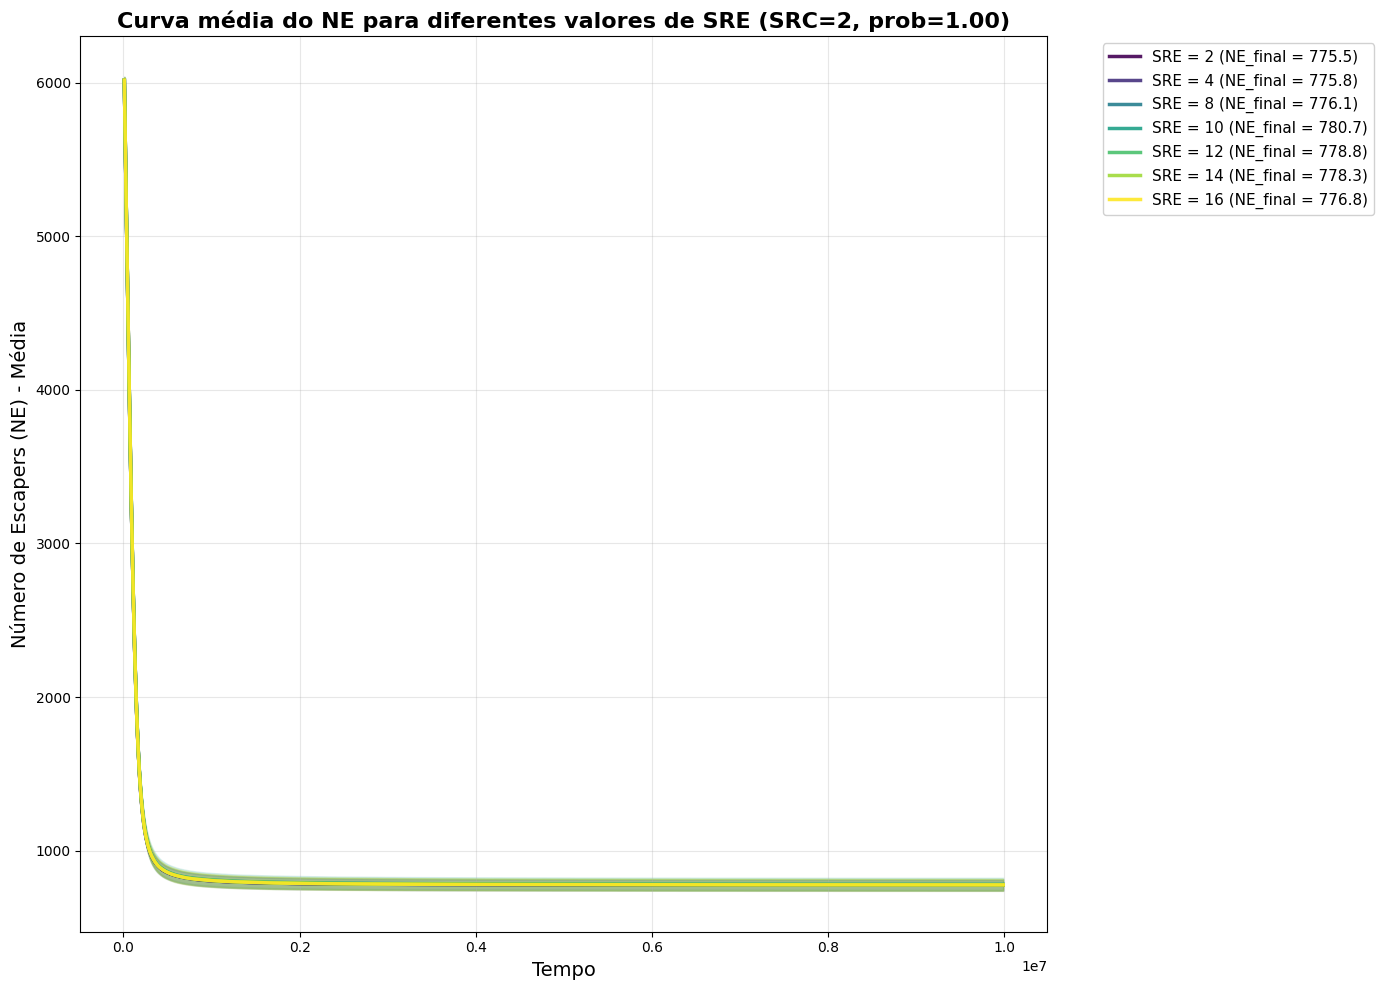


RESUMO DOS RESULTADOS
SRE        | Média Final (NE)   | Desvio Padrão   | Runs    
----------------------------------------------------------------------
2          |           775.49 |         35.99 |  100
4          |           775.81 |         30.77 |  100
8          |           776.12 |         37.04 |  100
10         |           780.67 |         42.76 |  100
12         |           778.83 |         36.54 |  100
14         |           778.33 |         37.42 |  100
16         |           776.76 |         39.36 |  100


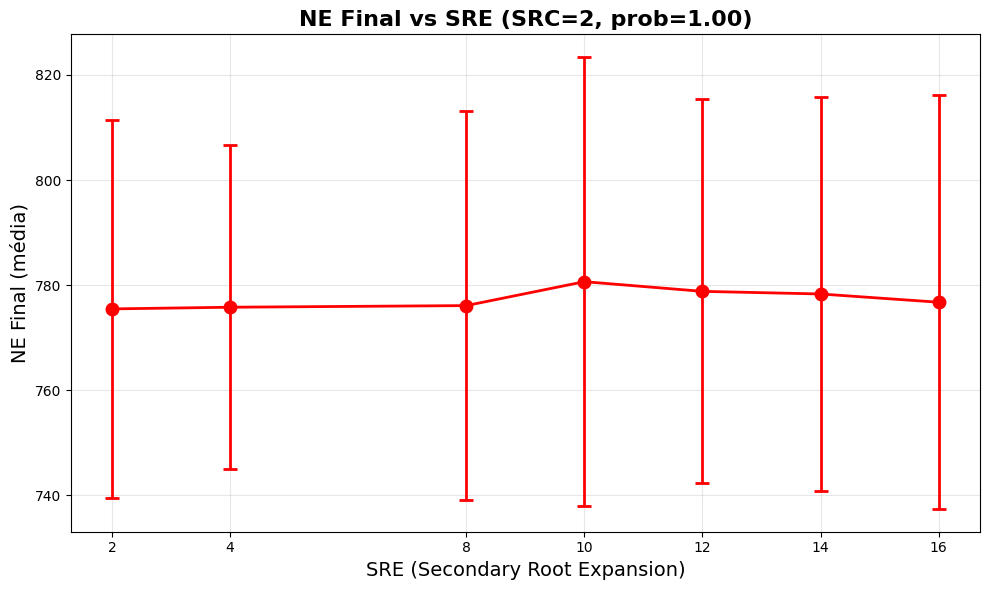

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Caminho base
base_path = "/media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data/data_raw/"
frac= 25
# Probabilidade fixa
prob = 1.00

# Valores de SRE (de 2 a 16, passo 2)
sre_values = range(2, 18, 2)  # 2, 4, 6, 8, 10, 12, 14, 16

# Número de runs
num_runs = 100

# Criar figura
plt.figure(figsize=(14, 10))

# Cores para cada curva (diferentes SRE)
cores = plt.cm.viridis(np.linspace(0, 1, len(sre_values)))

# Dicionário para armazenar resultados
resultados = {}

# Para cada valor de SRE
for idx, sre in enumerate(sre_values):
    todos_dados_NE = []
    
    print(f"Processando SRE = {sre} (prob = {prob:.2f})...")
    
    # Ler todos os runs para este SRE
    for run in range(1, num_runs + 1):
        try:
            # Novo formato do diretório
            caminho = f"{base_path}simulation_frac_{frac}_run_{run}_obsprob_{prob:.2f}_SRC_2_SRE_{sre}/results_N_escapers_run{run}.csv"

            #print(caminho)
            df = pd.read_csv(caminho)
            
            # Começar a partir da segunda linha
            df_cortado = df.iloc[1:].reset_index(drop=True)
            
            # Identificar a coluna de dados (exceto 'time')
            col_NE = [col for col in df_cortado.columns if col != 'time'][0]
            
            # Guardar os valores
            todos_dados_NE.append(df_cortado[col_NE].values)
            
        except FileNotFoundError:
            print(f"  Arquivo não encontrado: run {run}, SRE {sre}")
            continue
        except Exception as e:
            print(f"  Erro no run {run}, SRE {sre}: {e}")
            continue
    
    if todos_dados_NE:
        # Converter para array numpy
        todos_dados_NE = np.array(todos_dados_NE)
        
        # Calcular média e desvio padrão
        media = np.mean(todos_dados_NE, axis=0)
        desvio_padrao = np.std(todos_dados_NE, axis=0)
        
        # Tempo (assumindo que é o mesmo para todos)
        tempo = df_cortado['time'].values
        
        # Último valor da média
        ultimo_valor = media[-1]
        
        # Armazenar resultado
        resultados[sre] = {
            'media_final': ultimo_valor,
            'std_final': desvio_padrao[-1],
            'num_runs': len(todos_dados_NE)
        }
        
        # Plotar curva média com legenda incluindo o último valor
        plt.plot(tempo, media, 
                 label=f'SRE = {sre} (NE_final = {ultimo_valor:.1f})', 
                 linewidth=2.5, 
                 color=cores[idx],
                 alpha=0.9)
        
        # Plotar banda de desvio padrão
        plt.fill_between(tempo, 
                        media - desvio_padrao, 
                        media + desvio_padrao, 
                        alpha=0.15, 
                        color=cores[idx])
        
        print(f"  ✓ SRE = {sre}: média final = {ultimo_valor:.2f} ± {desvio_padrao[-1]:.2f} ({resultados[sre]['num_runs']} runs)")
    else:
        print(f"  ✗ SRE = {sre}: nenhum dado encontrado")

# Personalizar o gráfico
plt.xlabel('Tempo', fontsize=14)
plt.ylabel('Número de Escapers (NE) - Média', fontsize=14)
plt.title(f'Curva média do NE para diferentes valores de SRE (SRC=2, prob={prob:.2f})', 
          fontsize=16, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar tabela de resultados
print("\n" + "="*70)
print("RESUMO DOS RESULTADOS")
print("="*70)
print(f"{'SRE':<10} | {'Média Final (NE)':<18} | {'Desvio Padrão':<15} | {'Runs':<8}")
print("-"*70)
for sre in sorted(resultados.keys()):
    stats = resultados[sre]
    print(f"{sre:<10} | {stats['media_final']:>16.2f} | {stats['std_final']:>13.2f} | {stats['num_runs']:>4}")
print("="*70)

# Gráfico adicional: NE final vs SRE
plt.figure(figsize=(10, 6))
sre_list = sorted(resultados.keys())
media_final_list = [resultados[sre]['media_final'] for sre in sre_list]
std_list = [resultados[sre]['std_final'] for sre in sre_list]

plt.errorbar(sre_list, media_final_list, yerr=std_list, 
             fmt='o-', capsize=5, capthick=2, 
             markersize=8, linewidth=2, color='red', 
             elinewidth=2, markeredgewidth=2)
plt.xlabel('SRE (Secondary Root Expansion)', fontsize=14)
plt.ylabel('NE Final (média)', fontsize=14)
plt.title(f'NE Final vs SRE (SRC=2, prob={prob:.2f})', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(sre_list)
plt.tight_layout()
plt.show()


### Numero de escapers NC = 0.50NE

Processando SRE = 2 (prob = 1.00)...
  ✓ SRE = 2: média final = 308.61 ± 24.30 (100 runs)
Processando SRE = 4 (prob = 1.00)...
  ✓ SRE = 4: média final = 307.12 ± 22.30 (100 runs)
Processando SRE = 6 (prob = 1.00)...
  Arquivo não encontrado: run 1, SRE 6
  Arquivo não encontrado: run 2, SRE 6
  Arquivo não encontrado: run 3, SRE 6
  Arquivo não encontrado: run 4, SRE 6
  Arquivo não encontrado: run 5, SRE 6
  Arquivo não encontrado: run 6, SRE 6
  Arquivo não encontrado: run 7, SRE 6
  Arquivo não encontrado: run 8, SRE 6
  Arquivo não encontrado: run 9, SRE 6
  Arquivo não encontrado: run 10, SRE 6
  Arquivo não encontrado: run 11, SRE 6
  Arquivo não encontrado: run 12, SRE 6
  Arquivo não encontrado: run 13, SRE 6
  Arquivo não encontrado: run 14, SRE 6
  Arquivo não encontrado: run 15, SRE 6
  Arquivo não encontrado: run 16, SRE 6
  Arquivo não encontrado: run 17, SRE 6
  Arquivo não encontrado: run 18, SRE 6
  Arquivo não encontrado: run 19, SRE 6
  Arquivo não encontrado: run 20

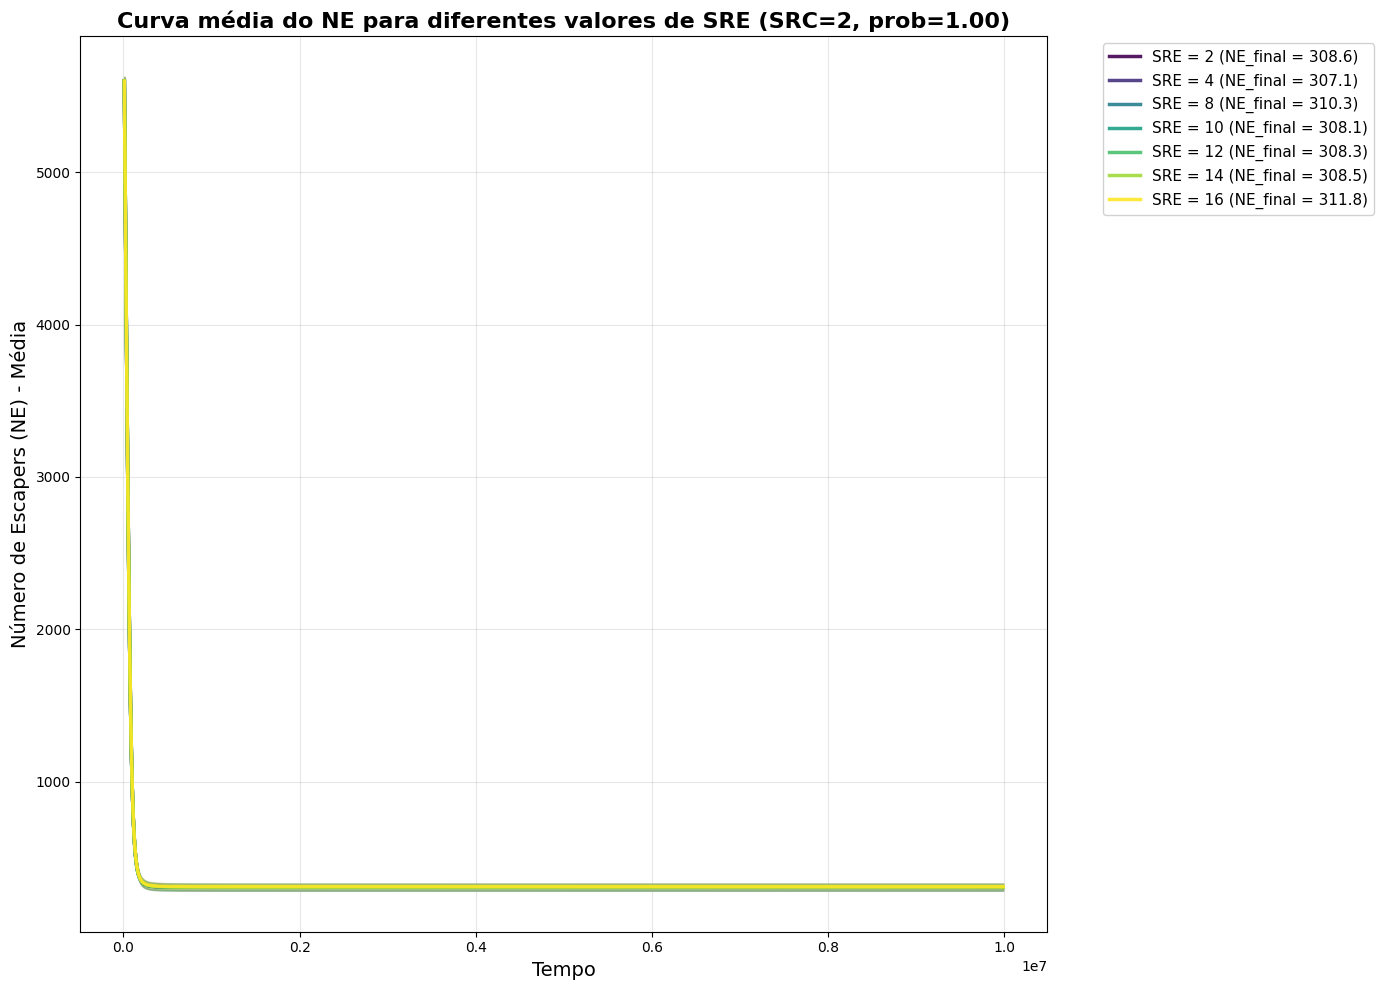


RESUMO DOS RESULTADOS
SRE        | Média Final (NE)   | Desvio Padrão   | Runs    
----------------------------------------------------------------------
2          |           308.61 |         24.30 |  100
4          |           307.12 |         22.30 |  100
8          |           310.34 |         22.19 |  100
10         |           308.10 |         20.75 |  100
12         |           308.26 |         21.04 |  100
14         |           308.46 |         25.30 |  100
16         |           311.81 |         19.48 |  100


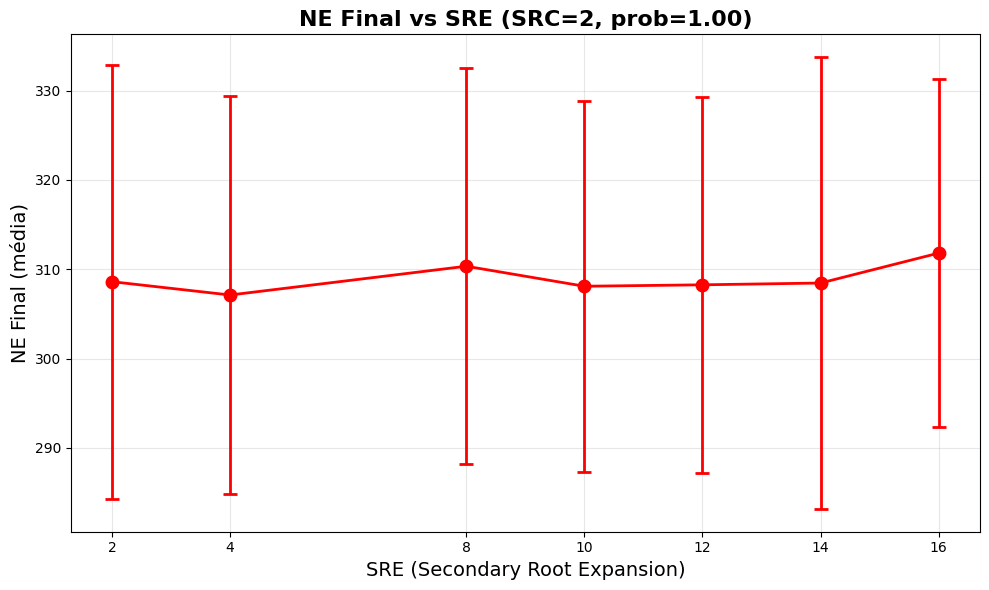

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Caminho base
base_path = "/media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data/data_raw/"
frac= 50
# Probabilidade fixa
prob = 1.00

# Valores de SRE (de 2 a 16, passo 2)
sre_values = range(2, 18, 2)  # 2, 4, 6, 8, 10, 12, 14, 16

# Número de runs
num_runs = 100

# Criar figura
plt.figure(figsize=(14, 10))

# Cores para cada curva (diferentes SRE)
cores = plt.cm.viridis(np.linspace(0, 1, len(sre_values)))

# Dicionário para armazenar resultados
resultados = {}

# Para cada valor de SRE
for idx, sre in enumerate(sre_values):
    todos_dados_NE = []
    
    print(f"Processando SRE = {sre} (prob = {prob:.2f})...")
    
    # Ler todos os runs para este SRE
    for run in range(1, num_runs + 1):
        try:
            # Novo formato do diretório
            caminho = f"{base_path}simulation_frac_{frac}_run_{run}_obsprob_{prob:.2f}_SRC_2_SRE_{sre}/results_N_escapers_run{run}.csv"

            #print(caminho)
            df = pd.read_csv(caminho)
            
            # Começar a partir da segunda linha
            df_cortado = df.iloc[1:].reset_index(drop=True)
            
            # Identificar a coluna de dados (exceto 'time')
            col_NE = [col for col in df_cortado.columns if col != 'time'][0]
            
            # Guardar os valores
            todos_dados_NE.append(df_cortado[col_NE].values)
            
        except FileNotFoundError:
            print(f"  Arquivo não encontrado: run {run}, SRE {sre}")
            continue
        except Exception as e:
            print(f"  Erro no run {run}, SRE {sre}: {e}")
            continue
    
    if todos_dados_NE:
        # Converter para array numpy
        todos_dados_NE = np.array(todos_dados_NE)
        
        # Calcular média e desvio padrão
        media = np.mean(todos_dados_NE, axis=0)
        desvio_padrao = np.std(todos_dados_NE, axis=0)
        
        # Tempo (assumindo que é o mesmo para todos)
        tempo = df_cortado['time'].values
        
        # Último valor da média
        ultimo_valor = media[-1]
        
        # Armazenar resultado
        resultados[sre] = {
            'media_final': ultimo_valor,
            'std_final': desvio_padrao[-1],
            'num_runs': len(todos_dados_NE)
        }
        
        # Plotar curva média com legenda incluindo o último valor
        plt.plot(tempo, media, 
                 label=f'SRE = {sre} (NE_final = {ultimo_valor:.1f})', 
                 linewidth=2.5, 
                 color=cores[idx],
                 alpha=0.9)
        
        # Plotar banda de desvio padrão
        plt.fill_between(tempo, 
                        media - desvio_padrao, 
                        media + desvio_padrao, 
                        alpha=0.15, 
                        color=cores[idx])
        
        print(f"  ✓ SRE = {sre}: média final = {ultimo_valor:.2f} ± {desvio_padrao[-1]:.2f} ({resultados[sre]['num_runs']} runs)")
    else:
        print(f"  ✗ SRE = {sre}: nenhum dado encontrado")

# Personalizar o gráfico
plt.xlabel('Tempo', fontsize=14)
plt.ylabel('Número de Escapers (NE) - Média', fontsize=14)
plt.title(f'Curva média do NE para diferentes valores de SRE (SRC=2, prob={prob:.2f})', 
          fontsize=16, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar tabela de resultados
print("\n" + "="*70)
print("RESUMO DOS RESULTADOS")
print("="*70)
print(f"{'SRE':<10} | {'Média Final (NE)':<18} | {'Desvio Padrão':<15} | {'Runs':<8}")
print("-"*70)
for sre in sorted(resultados.keys()):
    stats = resultados[sre]
    print(f"{sre:<10} | {stats['media_final']:>16.2f} | {stats['std_final']:>13.2f} | {stats['num_runs']:>4}")
print("="*70)

# Gráfico adicional: NE final vs SRE
plt.figure(figsize=(10, 6))
sre_list = sorted(resultados.keys())
media_final_list = [resultados[sre]['media_final'] for sre in sre_list]
std_list = [resultados[sre]['std_final'] for sre in sre_list]

plt.errorbar(sre_list, media_final_list, yerr=std_list, 
             fmt='o-', capsize=5, capthick=2, 
             markersize=8, linewidth=2, color='red', 
             elinewidth=2, markeredgewidth=2)
plt.xlabel('SRE (Secondary Root Expansion)', fontsize=14)
plt.ylabel('NE Final (média)', fontsize=14)
plt.title(f'NE Final vs SRE (SRC=2, prob={prob:.2f})', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(sre_list)
plt.tight_layout()
plt.show()


### Numero de escapers NC = 1.00NE

Processando SRE = 2 (prob = 1.00)...
  ✓ SRE = 2: média final = 58.22 ± 8.27 (100 runs)
Processando SRE = 4 (prob = 1.00)...
  ✓ SRE = 4: média final = 59.30 ± 9.67 (100 runs)
Processando SRE = 6 (prob = 1.00)...
  Arquivo não encontrado: run 1, SRE 6
  Arquivo não encontrado: run 2, SRE 6
  Arquivo não encontrado: run 3, SRE 6
  Arquivo não encontrado: run 4, SRE 6
  Arquivo não encontrado: run 5, SRE 6
  Arquivo não encontrado: run 6, SRE 6
  Arquivo não encontrado: run 7, SRE 6
  Arquivo não encontrado: run 8, SRE 6
  Arquivo não encontrado: run 9, SRE 6
  Arquivo não encontrado: run 10, SRE 6
  Arquivo não encontrado: run 11, SRE 6
  Arquivo não encontrado: run 12, SRE 6
  Arquivo não encontrado: run 13, SRE 6
  Arquivo não encontrado: run 14, SRE 6
  Arquivo não encontrado: run 15, SRE 6
  Arquivo não encontrado: run 16, SRE 6
  Arquivo não encontrado: run 17, SRE 6
  Arquivo não encontrado: run 18, SRE 6
  Arquivo não encontrado: run 19, SRE 6
  Arquivo não encontrado: run 20, SR

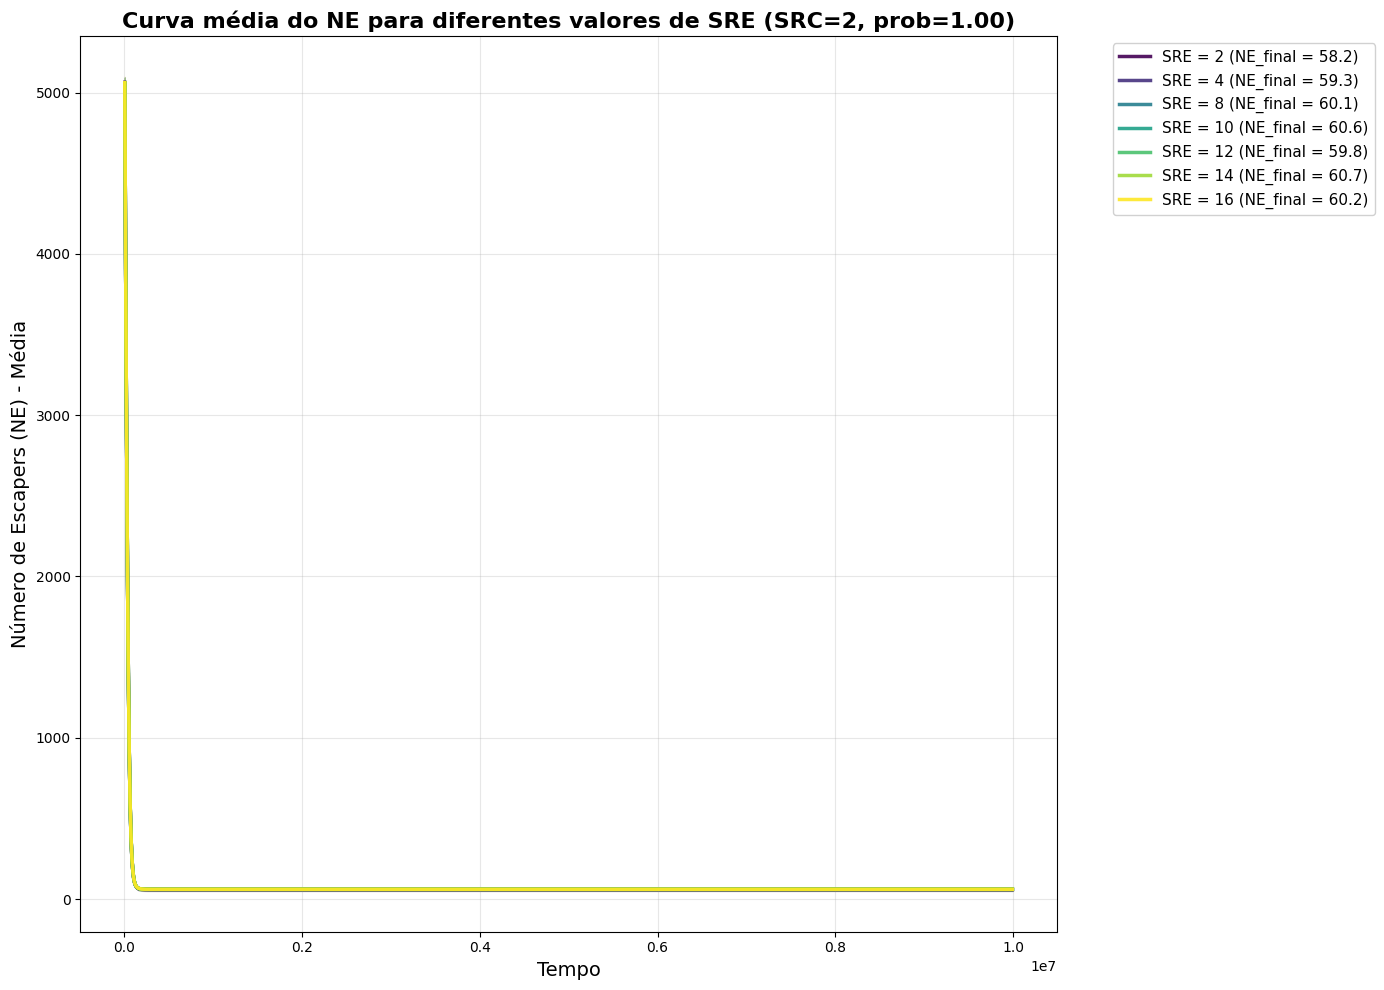


RESUMO DOS RESULTADOS
SRE        | Média Final (NE)   | Desvio Padrão   | Runs    
----------------------------------------------------------------------
2          |            58.22 |          8.27 |  100
4          |            59.30 |          9.67 |  100
8          |            60.07 |          8.56 |  100
10         |            60.63 |          9.15 |  100
12         |            59.77 |          8.63 |  100
14         |            60.70 |          8.60 |  100
16         |            60.17 |         10.06 |  100


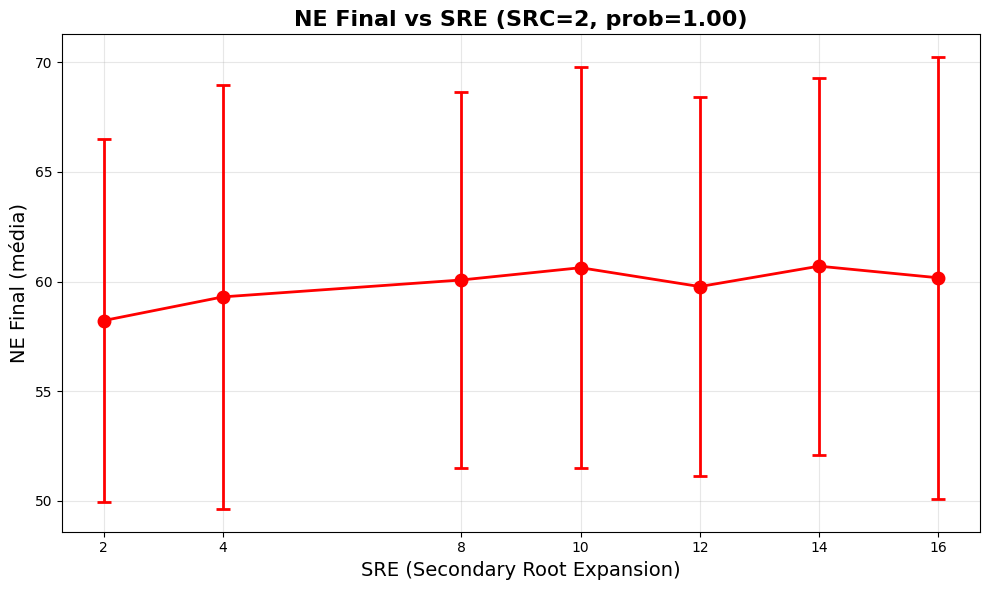

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Caminho base
base_path = "/media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data/data_raw/"
frac= 100
# Probabilidade fixa
prob = 1.00

# Valores de SRE (de 2 a 16, passo 2)
sre_values = range(2, 18, 2)  # 2, 4, 6, 8, 10, 12, 14, 16

# Número de runs
num_runs = 100

# Criar figura
plt.figure(figsize=(14, 10))

# Cores para cada curva (diferentes SRE)
cores = plt.cm.viridis(np.linspace(0, 1, len(sre_values)))

# Dicionário para armazenar resultados
resultados = {}

# Para cada valor de SRE
for idx, sre in enumerate(sre_values):
    todos_dados_NE = []
    
    print(f"Processando SRE = {sre} (prob = {prob:.2f})...")
    
    # Ler todos os runs para este SRE
    for run in range(1, num_runs + 1):
        try:
            # Novo formato do diretório
            caminho = f"{base_path}simulation_frac_{frac}_run_{run}_obsprob_{prob:.2f}_SRC_2_SRE_{sre}/results_N_escapers_run{run}.csv"

            #print(caminho)
            df = pd.read_csv(caminho)
            
            # Começar a partir da segunda linha
            df_cortado = df.iloc[1:].reset_index(drop=True)
            
            # Identificar a coluna de dados (exceto 'time')
            col_NE = [col for col in df_cortado.columns if col != 'time'][0]
            
            # Guardar os valores
            todos_dados_NE.append(df_cortado[col_NE].values)
            
        except FileNotFoundError:
            print(f"  Arquivo não encontrado: run {run}, SRE {sre}")
            continue
        except Exception as e:
            print(f"  Erro no run {run}, SRE {sre}: {e}")
            continue
    
    if todos_dados_NE:
        # Converter para array numpy
        todos_dados_NE = np.array(todos_dados_NE)
        
        # Calcular média e desvio padrão
        media = np.mean(todos_dados_NE, axis=0)
        desvio_padrao = np.std(todos_dados_NE, axis=0)
        
        # Tempo (assumindo que é o mesmo para todos)
        tempo = df_cortado['time'].values
        
        # Último valor da média
        ultimo_valor = media[-1]
        
        # Armazenar resultado
        resultados[sre] = {
            'media_final': ultimo_valor,
            'std_final': desvio_padrao[-1],
            'num_runs': len(todos_dados_NE)
        }
        
        # Plotar curva média com legenda incluindo o último valor
        plt.plot(tempo, media, 
                 label=f'SRE = {sre} (NE_final = {ultimo_valor:.1f})', 
                 linewidth=2.5, 
                 color=cores[idx],
                 alpha=0.9)
        
        # Plotar banda de desvio padrão
        plt.fill_between(tempo, 
                        media - desvio_padrao, 
                        media + desvio_padrao, 
                        alpha=0.15, 
                        color=cores[idx])
        
        print(f"  ✓ SRE = {sre}: média final = {ultimo_valor:.2f} ± {desvio_padrao[-1]:.2f} ({resultados[sre]['num_runs']} runs)")
    else:
        print(f"  ✗ SRE = {sre}: nenhum dado encontrado")

# Personalizar o gráfico
plt.xlabel('Tempo', fontsize=14)
plt.ylabel('Número de Escapers (NE) - Média', fontsize=14)
plt.title(f'Curva média do NE para diferentes valores de SRE (SRC=2, prob={prob:.2f})', 
          fontsize=16, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar tabela de resultados
print("\n" + "="*70)
print("RESUMO DOS RESULTADOS")
print("="*70)
print(f"{'SRE':<10} | {'Média Final (NE)':<18} | {'Desvio Padrão':<15} | {'Runs':<8}")
print("-"*70)
for sre in sorted(resultados.keys()):
    stats = resultados[sre]
    print(f"{sre:<10} | {stats['media_final']:>16.2f} | {stats['std_final']:>13.2f} | {stats['num_runs']:>4}")
print("="*70)

# Gráfico adicional: NE final vs SRE
plt.figure(figsize=(10, 6))
sre_list = sorted(resultados.keys())
media_final_list = [resultados[sre]['media_final'] for sre in sre_list]
std_list = [resultados[sre]['std_final'] for sre in sre_list]

plt.errorbar(sre_list, media_final_list, yerr=std_list, 
             fmt='o-', capsize=5, capthick=2, 
             markersize=8, linewidth=2, color='red', 
             elinewidth=2, markeredgewidth=2)
plt.xlabel('SRE (Secondary Root Expansion)', fontsize=14)
plt.ylabel('NE Final (média)', fontsize=14)
plt.title(f'NE Final vs SRE (SRC=2, prob={prob:.2f})', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(sre_list)
plt.tight_layout()
plt.show()


### N_O NC = 0.25NE

Processando SRE = 2 (prob = 1.00)...
  Tempo máximo comum: 9990000.00
  ✓ SRE = 2: 100 runs, média final = 21140.00 ± 263.97
Processando SRE = 4 (prob = 1.00)...
  Tempo máximo comum: 9990000.00
  ✓ SRE = 4: 100 runs, média final = 21130.77 ± 224.63
Processando SRE = 6 (prob = 1.00)...
  Arquivo não encontrado: run 1
  Arquivo não encontrado: run 2
  Arquivo não encontrado: run 3
  ✗ SRE = 6: nenhum dado encontrado
Processando SRE = 8 (prob = 1.00)...
  Tempo máximo comum: 9990000.00
  ✓ SRE = 8: 100 runs, média final = 21151.51 ± 258.27
Processando SRE = 10 (prob = 1.00)...
  Tempo máximo comum: 9990000.00
  ✓ SRE = 10: 100 runs, média final = 21148.82 ± 282.49
Processando SRE = 12 (prob = 1.00)...
  Tempo máximo comum: 9990000.00
  ✓ SRE = 12: 100 runs, média final = 21119.59 ± 234.98
Processando SRE = 14 (prob = 1.00)...
  Tempo máximo comum: 9990000.00
  ✓ SRE = 14: 100 runs, média final = 21146.49 ± 231.82
Processando SRE = 16 (prob = 1.00)...
  Tempo máximo comum: 9990000.00
  ✓ 

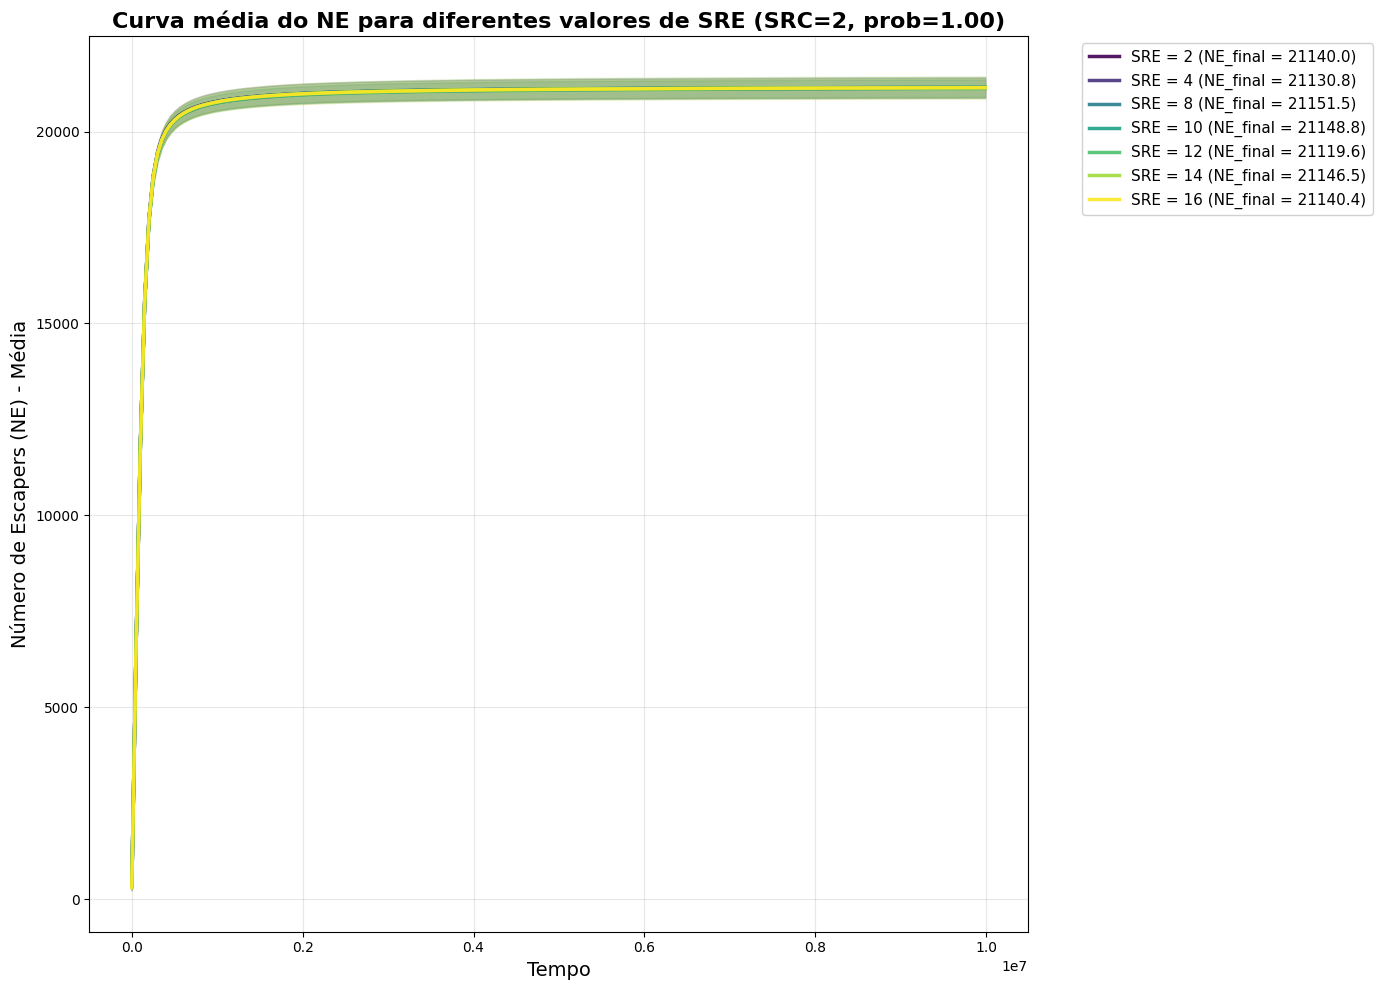


RESUMO DOS RESULTADOS
SRE        | Média Final (NE)   | Desvio Padrão   | Runs     | Tempo Max 
--------------------------------------------------------------------------------
2          |         21140.00 |        263.97 |  100 | 9990000.00
4          |         21130.77 |        224.63 |  100 | 9990000.00
8          |         21151.51 |        258.27 |  100 | 9990000.00
10         |         21148.82 |        282.49 |  100 | 9990000.00
12         |         21119.59 |        234.98 |  100 | 9990000.00
14         |         21146.49 |        231.82 |  100 | 9990000.00
16         |         21140.42 |        290.03 |  100 | 9990000.00


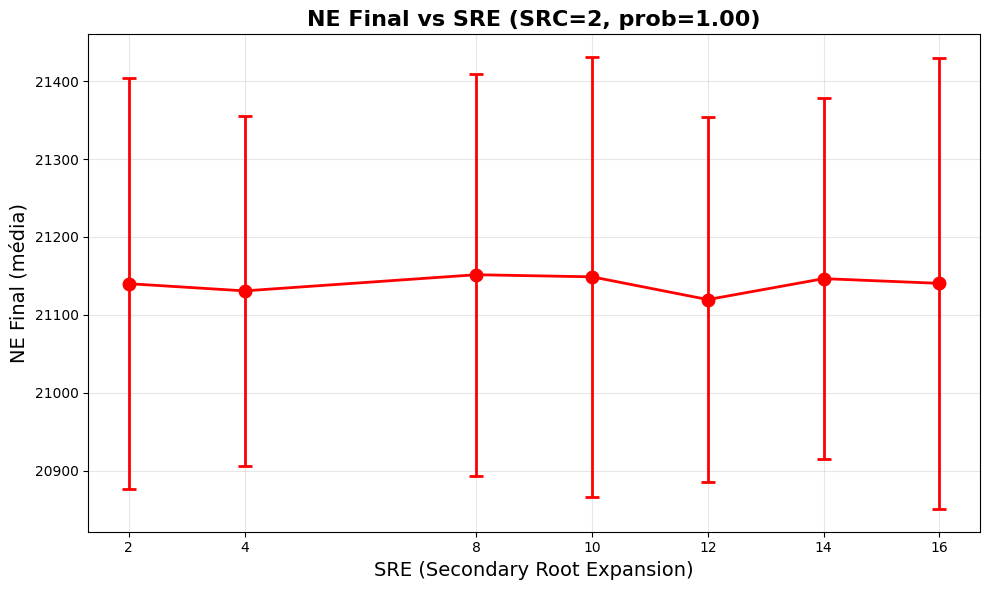

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

# Caminho base
base_path = "/media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data/data_raw/"


frac= 25
# Probabilidade fixa
prob = 1.00


# Valores de SRE (de 2 a 16, passo 2)
sre_values = range(2, 18, 2)  # 2, 4, 6, 8, 10, 12, 14, 16

# Número de runs
num_runs = 100

# Criar figura
plt.figure(figsize=(14, 10))

# Cores para cada curva (diferentes SRE)
cores = plt.cm.viridis(np.linspace(0, 1, len(sre_values)))

# Dicionário para armazenar resultados
resultados = {}

# Para cada valor de SRE
for idx, sre in enumerate(sre_values):
    todos_dados_NE = []
    todos_tempos = []
    
    print(f"Processando SRE = {sre} (prob = {prob:.2f})...")
    
    # Ler todos os runs para este SRE
    for run in range(1, num_runs + 1):
        try:
            # Nome do arquivo
            caminho = f"{base_path}simulation_frac_{frac}_run_{run}_obsprob_{prob:.2f}_SRC_2_SRE_{sre}/results_N_obs{run}.csv"
            
            df = pd.read_csv(caminho)
            
            # Começar a partir da segunda linha
            df_cortado = df.iloc[1:].reset_index(drop=True)
            
            # Identificar a coluna de dados (exceto 'time')
            col_NE = [col for col in df_cortado.columns if col != 'time'][0]
            
            # Guardar os valores
            tempos = df_cortado['time'].values
            valores_NE = df_cortado[col_NE].values
            
            todos_tempos.append(tempos)
            todos_dados_NE.append(valores_NE)
            
        except FileNotFoundError:
            if run <= 3:
                print(f"  Arquivo não encontrado: run {run}")
            continue
        except Exception as e:
            if run <= 3:
                print(f"  Erro no run {run}: {e}")
            continue
    
    if todos_dados_NE:
        # Encontrar o tempo máximo comum (menor último tempo entre todos os runs)
        tempos_maximos = [tempos[-1] for tempos in todos_tempos]
        tempo_maximo_comum = min(tempos_maximos)
        
        print(f"  Tempo máximo comum: {tempo_maximo_comum:.2f}")
        
        # Interpolar todos os runs para o mesmo grid de tempo
        # Criar grid de tempo comum
        tempo_grid = np.linspace(0, tempo_maximo_comum, 200)
        
        # Interpolar cada run
        dados_interpolados = []
        
        for i, (tempos, valores) in enumerate(zip(todos_tempos, todos_dados_NE)):
            # Criar função de interpolação
            f_interp = interp1d(tempos, valores, kind='linear', fill_value='extrapolate')
            
            # Interpolar para o grid comum
            valores_interp = f_interp(tempo_grid)
            dados_interpolados.append(valores_interp)
        
        # Converter para array numpy
        dados_interpolados = np.array(dados_interpolados)
        
        # Calcular média e desvio padrão
        media = np.mean(dados_interpolados, axis=0)
        desvio_padrao = np.std(dados_interpolados, axis=0)
        
        # Último valor da média
        ultimo_valor = media[-1]
        
        # Armazenar resultado
        resultados[sre] = {
            'media_final': ultimo_valor,
            'std_final': desvio_padrao[-1],
            'num_runs': len(todos_dados_NE),
            'tempo_maximo': tempo_maximo_comum
        }
        
        # Plotar curva média com legenda incluindo o último valor
        plt.plot(tempo_grid, media, 
                 label=f'SRE = {sre} (NE_final = {ultimo_valor:.1f})', 
                 linewidth=2.5, 
                 color=cores[idx],
                 alpha=0.9)
        
        # Plotar banda de desvio padrão
        plt.fill_between(tempo_grid, 
                        media - desvio_padrao, 
                        media + desvio_padrao, 
                        alpha=0.15, 
                        color=cores[idx])
        
        print(f"  ✓ SRE = {sre}: {len(todos_dados_NE)} runs, média final = {ultimo_valor:.2f} ± {desvio_padrao[-1]:.2f}")
    else:
        print(f"  ✗ SRE = {sre}: nenhum dado encontrado")

# Personalizar o gráfico
plt.xlabel('Tempo', fontsize=14)
plt.ylabel('Número de Escapers (NE) - Média', fontsize=14)
plt.title(f'Curva média do NE para diferentes valores de SRE (SRC=2, prob={prob:.2f})', 
          fontsize=16, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar tabela de resultados
print("\n" + "="*80)
print("RESUMO DOS RESULTADOS")
print("="*80)
print(f"{'SRE':<10} | {'Média Final (NE)':<18} | {'Desvio Padrão':<15} | {'Runs':<8} | {'Tempo Max':<10}")
print("-"*80)
for sre in sorted(resultados.keys()):
    stats = resultados[sre]
    print(f"{sre:<10} | {stats['media_final']:>16.2f} | {stats['std_final']:>13.2f} | {stats['num_runs']:>4} | {stats['tempo_maximo']:>8.2f}")
print("="*80)

# Gráfico adicional: NE final vs SRE
plt.figure(figsize=(10, 6))
sre_list = sorted(resultados.keys())
media_final_list = [resultados[sre]['media_final'] for sre in sre_list]
std_list = [resultados[sre]['std_final'] for sre in sre_list]

plt.errorbar(sre_list, media_final_list, yerr=std_list, 
             fmt='o-', capsize=5, capthick=2, 
             markersize=8, linewidth=2, color='red', 
             elinewidth=2, markeredgewidth=2)
plt.xlabel('SRE (Secondary Root Expansion)', fontsize=14)
plt.ylabel('NE Final (média)', fontsize=14)
plt.title(f'NE Final vs SRE (SRC=2, prob={prob:.2f})', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(sre_list)
plt.tight_layout()
plt.show()

### N_O NC = 0.50NE

Processando SRE = 2 (prob = 1.00)...
  Tempo máximo comum: 9990000.00
  ✓ SRE = 2: 100 runs, média final = 14170.31 ± 199.79
Processando SRE = 4 (prob = 1.00)...
  Tempo máximo comum: 9990000.00
  ✓ SRE = 4: 100 runs, média final = 14178.20 ± 163.68
Processando SRE = 6 (prob = 1.00)...
  Arquivo não encontrado: run 1
  Arquivo não encontrado: run 2
  Arquivo não encontrado: run 3
  ✗ SRE = 6: nenhum dado encontrado
Processando SRE = 8 (prob = 1.00)...
  Tempo máximo comum: 9990000.00
  ✓ SRE = 8: 100 runs, média final = 14174.27 ± 179.51
Processando SRE = 10 (prob = 1.00)...
  Tempo máximo comum: 9990000.00
  ✓ SRE = 10: 100 runs, média final = 14169.72 ± 194.47
Processando SRE = 12 (prob = 1.00)...
  Tempo máximo comum: 9990000.00
  ✓ SRE = 12: 100 runs, média final = 14166.46 ± 183.24
Processando SRE = 14 (prob = 1.00)...
  Tempo máximo comum: 9990000.00
  ✓ SRE = 14: 100 runs, média final = 14186.49 ± 211.86
Processando SRE = 16 (prob = 1.00)...
  Tempo máximo comum: 9990000.00
  ✓ 

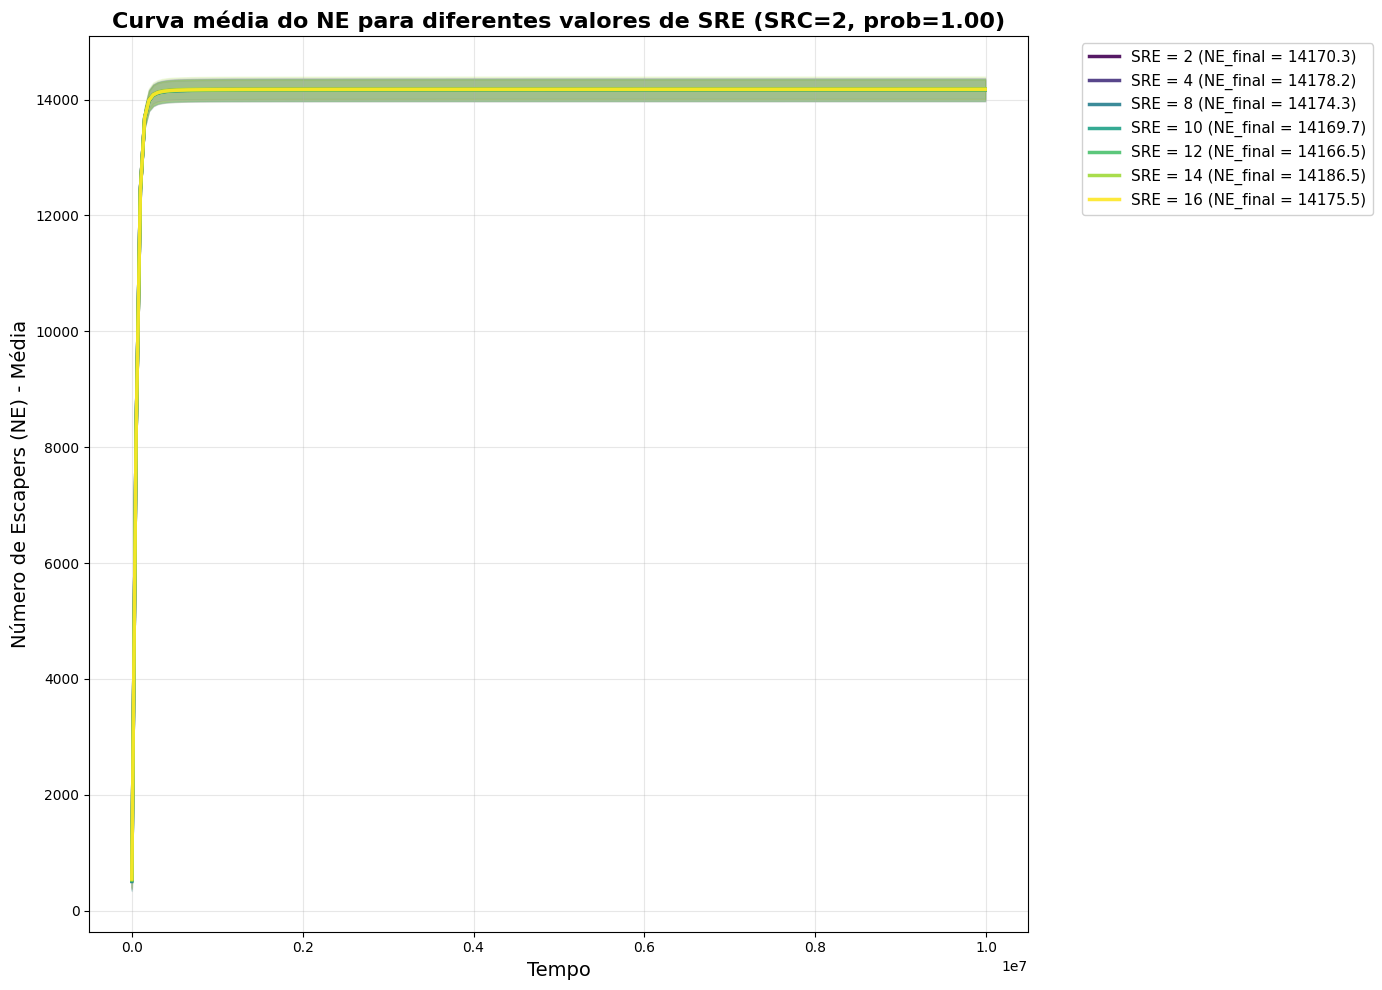


RESUMO DOS RESULTADOS
SRE        | Média Final (NE)   | Desvio Padrão   | Runs     | Tempo Max 
--------------------------------------------------------------------------------
2          |         14170.31 |        199.79 |  100 | 9990000.00
4          |         14178.20 |        163.68 |  100 | 9990000.00
8          |         14174.27 |        179.51 |  100 | 9990000.00
10         |         14169.72 |        194.47 |  100 | 9990000.00
12         |         14166.46 |        183.24 |  100 | 9990000.00
14         |         14186.49 |        211.86 |  100 | 9990000.00
16         |         14175.48 |        174.93 |  100 | 9990000.00


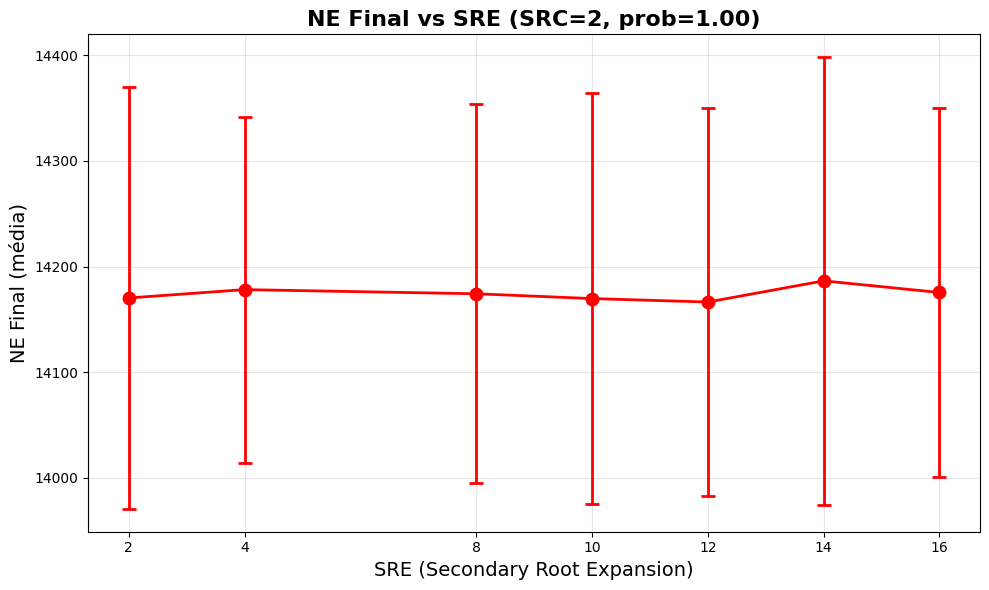

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

# Caminho base
base_path = "/media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data/data_raw/"


frac= 50
# Probabilidade fixa
prob = 1.00


# Valores de SRE (de 2 a 16, passo 2)
sre_values = range(2, 18, 2)  # 2, 4, 6, 8, 10, 12, 14, 16

# Número de runs
num_runs = 100

# Criar figura
plt.figure(figsize=(14, 10))

# Cores para cada curva (diferentes SRE)
cores = plt.cm.viridis(np.linspace(0, 1, len(sre_values)))

# Dicionário para armazenar resultados
resultados = {}

# Para cada valor de SRE
for idx, sre in enumerate(sre_values):
    todos_dados_NE = []
    todos_tempos = []
    
    print(f"Processando SRE = {sre} (prob = {prob:.2f})...")
    
    # Ler todos os runs para este SRE
    for run in range(1, num_runs + 1):
        try:
            # Nome do arquivo
            caminho = f"{base_path}simulation_frac_{frac}_run_{run}_obsprob_{prob:.2f}_SRC_2_SRE_{sre}/results_N_obs{run}.csv"
            
            df = pd.read_csv(caminho)
            
            # Começar a partir da segunda linha
            df_cortado = df.iloc[1:].reset_index(drop=True)
            
            # Identificar a coluna de dados (exceto 'time')
            col_NE = [col for col in df_cortado.columns if col != 'time'][0]
            
            # Guardar os valores
            tempos = df_cortado['time'].values
            valores_NE = df_cortado[col_NE].values
            
            todos_tempos.append(tempos)
            todos_dados_NE.append(valores_NE)
            
        except FileNotFoundError:
            if run <= 3:
                print(f"  Arquivo não encontrado: run {run}")
            continue
        except Exception as e:
            if run <= 3:
                print(f"  Erro no run {run}: {e}")
            continue
    
    if todos_dados_NE:
        # Encontrar o tempo máximo comum (menor último tempo entre todos os runs)
        tempos_maximos = [tempos[-1] for tempos in todos_tempos]
        tempo_maximo_comum = min(tempos_maximos)
        
        print(f"  Tempo máximo comum: {tempo_maximo_comum:.2f}")
        
        # Interpolar todos os runs para o mesmo grid de tempo
        # Criar grid de tempo comum
        tempo_grid = np.linspace(0, tempo_maximo_comum, 200)
        
        # Interpolar cada run
        dados_interpolados = []
        
        for i, (tempos, valores) in enumerate(zip(todos_tempos, todos_dados_NE)):
            # Criar função de interpolação
            f_interp = interp1d(tempos, valores, kind='linear', fill_value='extrapolate')
            
            # Interpolar para o grid comum
            valores_interp = f_interp(tempo_grid)
            dados_interpolados.append(valores_interp)
        
        # Converter para array numpy
        dados_interpolados = np.array(dados_interpolados)
        
        # Calcular média e desvio padrão
        media = np.mean(dados_interpolados, axis=0)
        desvio_padrao = np.std(dados_interpolados, axis=0)
        
        # Último valor da média
        ultimo_valor = media[-1]
        
        # Armazenar resultado
        resultados[sre] = {
            'media_final': ultimo_valor,
            'std_final': desvio_padrao[-1],
            'num_runs': len(todos_dados_NE),
            'tempo_maximo': tempo_maximo_comum
        }
        
        # Plotar curva média com legenda incluindo o último valor
        plt.plot(tempo_grid, media, 
                 label=f'SRE = {sre} (NE_final = {ultimo_valor:.1f})', 
                 linewidth=2.5, 
                 color=cores[idx],
                 alpha=0.9)
        
        # Plotar banda de desvio padrão
        plt.fill_between(tempo_grid, 
                        media - desvio_padrao, 
                        media + desvio_padrao, 
                        alpha=0.15, 
                        color=cores[idx])
        
        print(f"  ✓ SRE = {sre}: {len(todos_dados_NE)} runs, média final = {ultimo_valor:.2f} ± {desvio_padrao[-1]:.2f}")
    else:
        print(f"  ✗ SRE = {sre}: nenhum dado encontrado")

# Personalizar o gráfico
plt.xlabel('Tempo', fontsize=14)
plt.ylabel('Número de Escapers (NE) - Média', fontsize=14)
plt.title(f'Curva média do NE para diferentes valores de SRE (SRC=2, prob={prob:.2f})', 
          fontsize=16, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar tabela de resultados
print("\n" + "="*80)
print("RESUMO DOS RESULTADOS")
print("="*80)
print(f"{'SRE':<10} | {'Média Final (NE)':<18} | {'Desvio Padrão':<15} | {'Runs':<8} | {'Tempo Max':<10}")
print("-"*80)
for sre in sorted(resultados.keys()):
    stats = resultados[sre]
    print(f"{sre:<10} | {stats['media_final']:>16.2f} | {stats['std_final']:>13.2f} | {stats['num_runs']:>4} | {stats['tempo_maximo']:>8.2f}")
print("="*80)

# Gráfico adicional: NE final vs SRE
plt.figure(figsize=(10, 6))
sre_list = sorted(resultados.keys())
media_final_list = [resultados[sre]['media_final'] for sre in sre_list]
std_list = [resultados[sre]['std_final'] for sre in sre_list]

plt.errorbar(sre_list, media_final_list, yerr=std_list, 
             fmt='o-', capsize=5, capthick=2, 
             markersize=8, linewidth=2, color='red', 
             elinewidth=2, markeredgewidth=2)
plt.xlabel('SRE (Secondary Root Expansion)', fontsize=14)
plt.ylabel('NE Final (média)', fontsize=14)
plt.title(f'NE Final vs SRE (SRC=2, prob={prob:.2f})', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(sre_list)
plt.tight_layout()
plt.show()

### N_O NC = 1.0NE

Processando SRE = 2 (prob = 1.00)...
  Tempo máximo comum: 9990000.00
  ✓ SRE = 2: 100 runs, média final = 7855.77 ± 108.91
Processando SRE = 4 (prob = 1.00)...
  Tempo máximo comum: 9990000.00
  ✓ SRE = 4: 100 runs, média final = 7841.86 ± 116.99
Processando SRE = 6 (prob = 1.00)...
  Arquivo não encontrado: run 1
  Arquivo não encontrado: run 2
  Arquivo não encontrado: run 3
  ✗ SRE = 6: nenhum dado encontrado
Processando SRE = 8 (prob = 1.00)...
  Tempo máximo comum: 9990000.00
  ✓ SRE = 8: 100 runs, média final = 7825.99 ± 119.62
Processando SRE = 10 (prob = 1.00)...
  Tempo máximo comum: 9990000.00
  ✓ SRE = 10: 100 runs, média final = 7855.82 ± 115.78
Processando SRE = 12 (prob = 1.00)...
  Tempo máximo comum: 9990000.00
  ✓ SRE = 12: 100 runs, média final = 7863.52 ± 123.54
Processando SRE = 14 (prob = 1.00)...
  Tempo máximo comum: 9990000.00
  ✓ SRE = 14: 100 runs, média final = 7864.38 ± 120.64
Processando SRE = 16 (prob = 1.00)...
  Tempo máximo comum: 9990000.00
  ✓ SRE = 

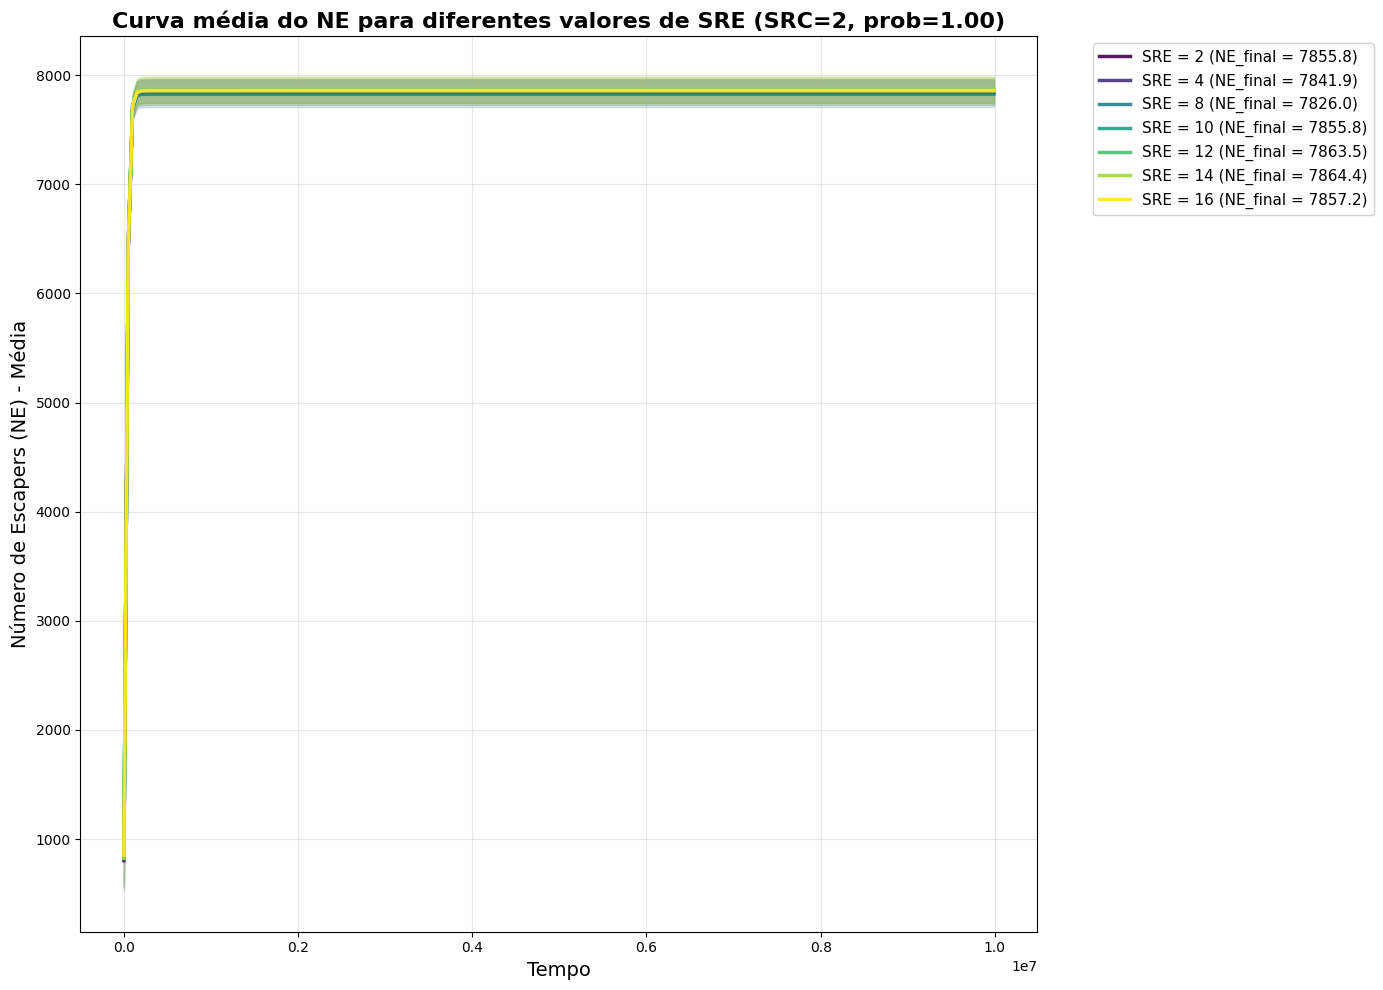


RESUMO DOS RESULTADOS
SRE        | Média Final (NE)   | Desvio Padrão   | Runs     | Tempo Max 
--------------------------------------------------------------------------------
2          |          7855.77 |        108.91 |  100 | 9990000.00
4          |          7841.86 |        116.99 |  100 | 9990000.00
8          |          7825.99 |        119.62 |  100 | 9990000.00
10         |          7855.82 |        115.78 |  100 | 9990000.00
12         |          7863.52 |        123.54 |  100 | 9990000.00
14         |          7864.38 |        120.64 |  100 | 9990000.00
16         |          7857.23 |        119.04 |  100 | 9990000.00


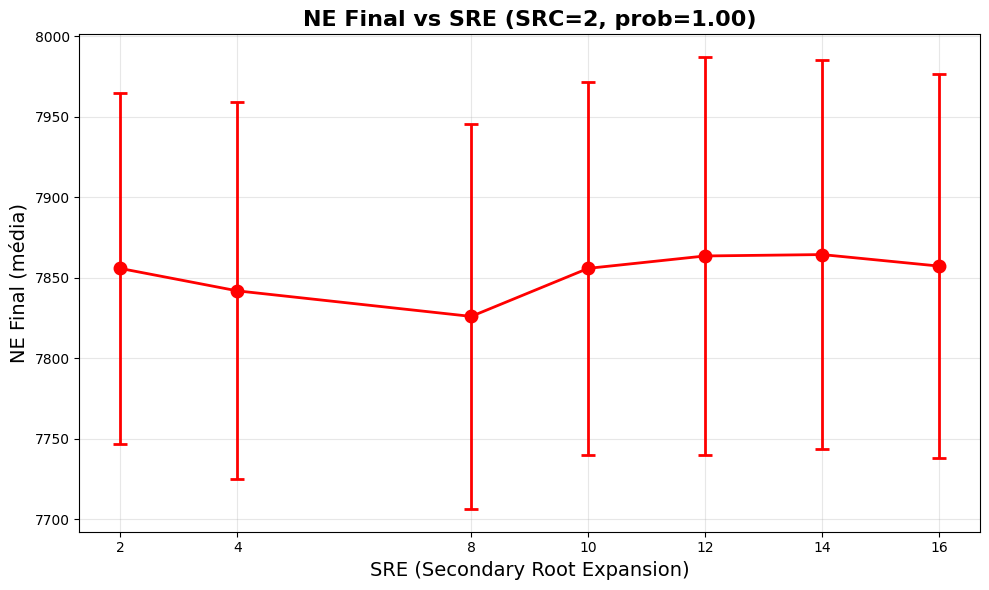

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

# Caminho base
base_path = "/media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data/data_raw/"


frac= 100
# Probabilidade fixa
prob = 1.00


# Valores de SRE (de 2 a 16, passo 2)
sre_values = range(2, 18, 2)  # 2, 4, 6, 8, 10, 12, 14, 16

# Número de runs
num_runs = 100

# Criar figura
plt.figure(figsize=(14, 10))

# Cores para cada curva (diferentes SRE)
cores = plt.cm.viridis(np.linspace(0, 1, len(sre_values)))

# Dicionário para armazenar resultados
resultados = {}

# Para cada valor de SRE
for idx, sre in enumerate(sre_values):
    todos_dados_NE = []
    todos_tempos = []
    
    print(f"Processando SRE = {sre} (prob = {prob:.2f})...")
    
    # Ler todos os runs para este SRE
    for run in range(1, num_runs + 1):
        try:
            # Nome do arquivo
            caminho = f"{base_path}simulation_frac_{frac}_run_{run}_obsprob_{prob:.2f}_SRC_2_SRE_{sre}/results_N_obs{run}.csv"
            
            df = pd.read_csv(caminho)
            
            # Começar a partir da segunda linha
            df_cortado = df.iloc[1:].reset_index(drop=True)
            
            # Identificar a coluna de dados (exceto 'time')
            col_NE = [col for col in df_cortado.columns if col != 'time'][0]
            
            # Guardar os valores
            tempos = df_cortado['time'].values
            valores_NE = df_cortado[col_NE].values
            
            todos_tempos.append(tempos)
            todos_dados_NE.append(valores_NE)
            
        except FileNotFoundError:
            if run <= 3:
                print(f"  Arquivo não encontrado: run {run}")
            continue
        except Exception as e:
            if run <= 3:
                print(f"  Erro no run {run}: {e}")
            continue
    
    if todos_dados_NE:
        # Encontrar o tempo máximo comum (menor último tempo entre todos os runs)
        tempos_maximos = [tempos[-1] for tempos in todos_tempos]
        tempo_maximo_comum = min(tempos_maximos)
        
        print(f"  Tempo máximo comum: {tempo_maximo_comum:.2f}")
        
        # Interpolar todos os runs para o mesmo grid de tempo
        # Criar grid de tempo comum
        tempo_grid = np.linspace(0, tempo_maximo_comum, 200)
        
        # Interpolar cada run
        dados_interpolados = []
        
        for i, (tempos, valores) in enumerate(zip(todos_tempos, todos_dados_NE)):
            # Criar função de interpolação
            f_interp = interp1d(tempos, valores, kind='linear', fill_value='extrapolate')
            
            # Interpolar para o grid comum
            valores_interp = f_interp(tempo_grid)
            dados_interpolados.append(valores_interp)
        
        # Converter para array numpy
        dados_interpolados = np.array(dados_interpolados)
        
        # Calcular média e desvio padrão
        media = np.mean(dados_interpolados, axis=0)
        desvio_padrao = np.std(dados_interpolados, axis=0)
        
        # Último valor da média
        ultimo_valor = media[-1]
        
        # Armazenar resultado
        resultados[sre] = {
            'media_final': ultimo_valor,
            'std_final': desvio_padrao[-1],
            'num_runs': len(todos_dados_NE),
            'tempo_maximo': tempo_maximo_comum
        }
        
        # Plotar curva média com legenda incluindo o último valor
        plt.plot(tempo_grid, media, 
                 label=f'SRE = {sre} (NE_final = {ultimo_valor:.1f})', 
                 linewidth=2.5, 
                 color=cores[idx],
                 alpha=0.9)
        
        # Plotar banda de desvio padrão
        plt.fill_between(tempo_grid, 
                        media - desvio_padrao, 
                        media + desvio_padrao, 
                        alpha=0.15, 
                        color=cores[idx])
        
        print(f"  ✓ SRE = {sre}: {len(todos_dados_NE)} runs, média final = {ultimo_valor:.2f} ± {desvio_padrao[-1]:.2f}")
    else:
        print(f"  ✗ SRE = {sre}: nenhum dado encontrado")

# Personalizar o gráfico
plt.xlabel('Tempo', fontsize=14)
plt.ylabel('Número de Escapers (NE) - Média', fontsize=14)
plt.title(f'Curva média do NE para diferentes valores de SRE (SRC=2, prob={prob:.2f})', 
          fontsize=16, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar tabela de resultados
print("\n" + "="*80)
print("RESUMO DOS RESULTADOS")
print("="*80)
print(f"{'SRE':<10} | {'Média Final (NE)':<18} | {'Desvio Padrão':<15} | {'Runs':<8} | {'Tempo Max':<10}")
print("-"*80)
for sre in sorted(resultados.keys()):
    stats = resultados[sre]
    print(f"{sre:<10} | {stats['media_final']:>16.2f} | {stats['std_final']:>13.2f} | {stats['num_runs']:>4} | {stats['tempo_maximo']:>8.2f}")
print("="*80)

# Gráfico adicional: NE final vs SRE
plt.figure(figsize=(10, 6))
sre_list = sorted(resultados.keys())
media_final_list = [resultados[sre]['media_final'] for sre in sre_list]
std_list = [resultados[sre]['std_final'] for sre in sre_list]

plt.errorbar(sre_list, media_final_list, yerr=std_list, 
             fmt='o-', capsize=5, capthick=2, 
             markersize=8, linewidth=2, color='red', 
             elinewidth=2, markeredgewidth=2)
plt.xlabel('SRE (Secondary Root Expansion)', fontsize=14)
plt.ylabel('NE Final (média)', fontsize=14)
plt.title(f'NE Final vs SRE (SRC=2, prob={prob:.2f})', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(sre_list)
plt.tight_layout()
plt.show()

### MSD

Carregando arquivo: /media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data/data_raw/simulation_frac_25_run_10_obsprob_1.00_SRC_2_SRE_16/results_chasers_run10.csv

Dados carregados:
Shape: (329238, 4)
Colunas: ['time', 'x', 'y', 'id']

Primeiras linhas:
   time    x    y  id
0     0   61  100   0
1     0  148  120   1
2     0   66  159   2
3     0   10   60   3
4     0  196  184   4

Calculando MSD...
Número de partículas (chasers): 1638


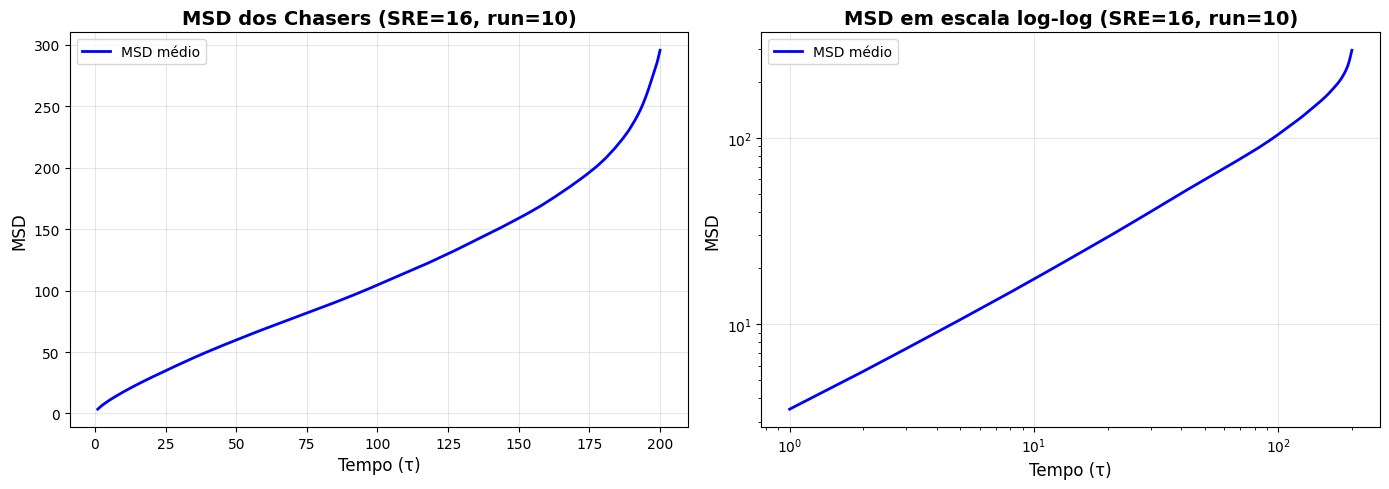


RESULTADOS PARA SRE=16, RUN=10
Número de partículas processadas: 1638
Tempo máximo: 200
MSD final: 295.53 ± 457.37
Expoente α (passos 0 a 9): 0.700


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuração do caso de teste
run = 10
sre = 16
prob = 1.00

# Caminho do arquivo
file_path = f"/media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data/data_raw/simulation_frac_25_run_{run}_obsprob_{prob:.2f}_SRC_2_SRE_{sre}/results_chasers_run{run}.csv"

print(f"Carregando arquivo: {file_path}")

# Carregar dados
df = pd.read_csv(file_path)
print(f"\nDados carregados:")
print(f"Shape: {df.shape}")
print(f"Colunas: {df.columns.tolist()}")
print(f"\nPrimeiras linhas:")
print(df.head())

# Função para unwrap das trajetórias
def unwrap_trajectory(df_particle, L):
    """Desfaz condições de contorno periódicas para uma trajetória"""
    df_particle = df_particle.sort_values("time").copy()
    
    x_unwrapped = [df_particle["x"].iloc[0]]
    y_unwrapped = [df_particle["y"].iloc[0]]
    
    for i in range(1, len(df_particle)):
        dx = df_particle["x"].iloc[i] - df_particle["x"].iloc[i - 1]
        dy = df_particle["y"].iloc[i] - df_particle["y"].iloc[i - 1]
        
        if dx > L / 2:
            dx -= L
        elif dx < -L / 2:
            dx += L
        
        if dy > L / 2:
            dy -= L
        elif dy < -L / 2:
            dy += L
        
        x_unwrapped.append(x_unwrapped[-1] + dx)
        y_unwrapped.append(y_unwrapped[-1] + dy)
    
    df_particle["x_unwrapped"] = x_unwrapped
    df_particle["y_unwrapped"] = y_unwrapped
    
    return df_particle

# Função para calcular MSD time-averaged manualmente
def compute_msd_time_averaged(positions, max_tau):
    """Calcula MSD time-averaged para uma trajetória"""
    n_steps = len(positions)
    max_tau = min(max_tau, n_steps - 1)
    
    msd = np.zeros(max_tau)
    
    for tau in range(1, max_tau + 1):
        displacements = positions[tau:] - positions[:-tau]
        squared_displacements = np.sum(displacements**2, axis=1)
        msd[tau - 1] = np.mean(squared_displacements)
    
    return msd

# Parâmetros
L = 256  # tamanho do sistema
min_traj_length = 5

# Calcular MSD para cada partícula (usando 'id' como identificador)
print(f"\nCalculando MSD...")
print(f"Número de partículas (chasers): {df['id'].nunique()}")

# Determinar tempo máximo
max_time = df["time"].max()
tau_values = np.arange(1, max_time)

msd_list = []

# Agrupar por 'id' em vez de 'cell_id'
for pid, group in df.groupby("id"):
    # Unwrap da trajetória
    df_unwrapped = unwrap_trajectory(group, L)
    positions = df_unwrapped[["x_unwrapped", "y_unwrapped"]].values
    
    if len(positions) < min_traj_length:
        continue
    
    # Calcular MSD time-averaged
    max_tau = min(len(positions) - 1, len(tau_values))
    msd_pid = compute_msd_time_averaged(positions, max_tau)
    msd_list.append(msd_pid)

if msd_list:
    # Média sobre todas as partículas
    msd_array = np.vstack(msd_list)
    msd_mean = msd_array.mean(axis=0)
    msd_std = msd_array.std(axis=0)
    
    tau = tau_values[:len(msd_mean)]
    
    # Plotar resultados
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico 1: MSD linear
    ax1 = axes[0]
    ax1.plot(tau, msd_mean, 'b-', linewidth=2, label='MSD médio')
    #ax1.fill_between(tau, msd_mean - msd_std, msd_mean + msd_std, alpha=0.3, color='blue')
    ax1.set_xlabel('Tempo (τ)', fontsize=12)
    ax1.set_ylabel('MSD', fontsize=12)
    ax1.set_title(f'MSD dos Chasers (SRE={sre}, run={run})', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Gráfico 2: MSD log-log
    ax2 = axes[1]
    ax2.loglog(tau, msd_mean, 'b-', linewidth=2, label='MSD médio')
    #ax2.fill_between(tau, msd_mean - msd_std, msd_mean + msd_std, alpha=0.3, color='blue')
    
    # Linhas de referência
    tau_ref = np.logspace(np.log10(tau[1]), np.log10(tau[-1]), 10)
    # Normalizar linhas de referência para comparar
    msd_ref_diffusive = tau_ref / tau_ref[-1] * msd_mean[-1]
    msd_ref_ballistic = (tau_ref**2) / (tau_ref[-1]**2) * msd_mean[-1]
    
    #ax2.loglog(tau_ref, msd_ref_diffusive, 'r--', alpha=0.5, label='Difusivo (α=1)')
    #ax2.loglog(tau_ref, msd_ref_ballistic, 'g--', alpha=0.5, label='Balístico (α=2)')
    
    ax2.set_xlabel('Tempo (τ)', fontsize=12)
    ax2.set_ylabel('MSD', fontsize=12)
    ax2.set_title(f'MSD em escala log-log (SRE={sre}, run={run})', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Mostrar estatísticas finais
    print(f"\n{'='*60}")
    print(f"RESULTADOS PARA SRE={sre}, RUN={run}")
    print(f"{'='*60}")
    print(f"Número de partículas processadas: {len(msd_list)}")
    print(f"Tempo máximo: {tau[-1]}")
    print(f"MSD final: {msd_mean[-1]:.2f} ± {msd_std[-1]:.2f}")
    
    # Calcular expoente α (MSD ~ t^α) para tempos longos
    # Calcular expoente α (MSD ~ t^α) para um intervalo específico
    n_i = 0  # passo inicial (você pode mudar)
    n_f = 10 # passo final (você pode mudar)
    
    # Garantir que os índices estão dentro dos limites
    n_i = max(0, min(n_i, len(tau) - 1))
    n_f = min(n_f, len(tau))
    
    if n_f > n_i:
        log_tau = np.log(tau[n_i:n_f])
        log_msd = np.log(msd_mean[n_i:n_f])
        alpha = np.polyfit(log_tau, log_msd, 1)[0]
        print(f"Expoente α (passos {n_i} a {n_f-1}): {alpha:.3f}")
    print(f"{'='*60}")
else:
    print("Nenhuma trajetória válida encontrada!")

Carregando arquivo: /media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data/data_raw/simulation_frac_25_run_10_obsprob_1.00_SRC_2_SRE_8/results_chasers_run10.csv

Dados carregados:
Shape: (329238, 4)
Colunas: ['time', 'x', 'y', 'id']

Primeiras linhas:
   time    x    y  id
0     0   61  100   0
1     0  148  120   1
2     0   66  159   2
3     0   10   60   3
4     0  196  184   4

Calculando MSD com trajpy...
Número de partículas (chasers): 1638


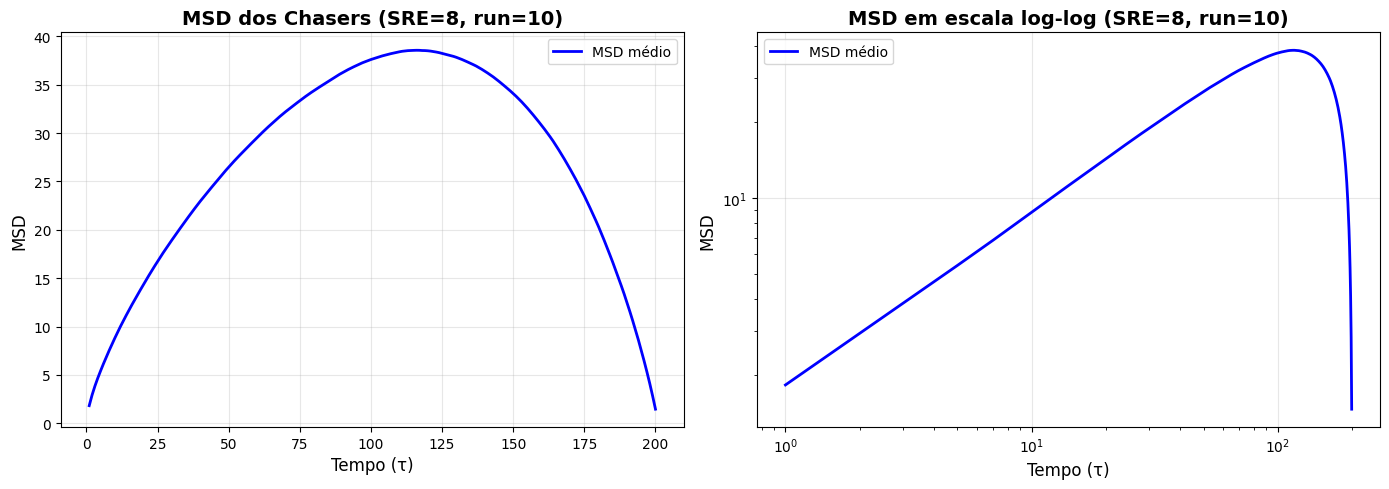


RESULTADOS PARA SRE=8, RUN=10
Número de partículas processadas: 1638
Tempo máximo: 200
MSD final: 1.47 ± 2.08
Expoente α (passos 0 a 9): 0.682


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from trajpy.trajpy import Trajectory

# Configuração do caso de teste
run = 10
sre = 8
prob = 1.00

# Caminho do arquivo
file_path = f"/media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data/data_raw/simulation_frac_25_run_{run}_obsprob_{prob:.2f}_SRC_2_SRE_{sre}/results_chasers_run{run}.csv"

print(f"Carregando arquivo: {file_path}")

# Carregar dados
df = pd.read_csv(file_path)
print(f"\nDados carregados:")
print(f"Shape: {df.shape}")
print(f"Colunas: {df.columns.tolist()}")
print(f"\nPrimeiras linhas:")
print(df.head())

# Função para unwrap das trajetórias (usando trajpy ou manual)
def unwrap_trajectory(df_particle, L):
    """Desfaz condições de contorno periódicas para uma trajetória"""
    df_particle = df_particle.sort_values("time").copy()
    
    x_unwrapped = [df_particle["x"].iloc[0]]
    y_unwrapped = [df_particle["y"].iloc[0]]
    
    for i in range(1, len(df_particle)):
        dx = df_particle["x"].iloc[i] - df_particle["x"].iloc[i - 1]
        dy = df_particle["y"].iloc[i] - df_particle["y"].iloc[i - 1]
        
        if dx > L / 2:
            dx -= L
        elif dx < -L / 2:
            dx += L
        
        if dy > L / 2:
            dy -= L
        elif dy < -L / 2:
            dy += L
        
        x_unwrapped.append(x_unwrapped[-1] + dx)
        y_unwrapped.append(y_unwrapped[-1] + dy)
    
    df_particle["x_unwrapped"] = x_unwrapped
    df_particle["y_unwrapped"] = y_unwrapped
    
    return df_particle

# Parâmetros
L = 256  # tamanho do sistema
min_traj_length = 5

# Calcular MSD para cada partícula usando trajpy
print(f"\nCalculando MSD com trajpy...")
print(f"Número de partículas (chasers): {df['id'].nunique()}")

# Determinar tempo máximo
max_time = df["time"].max()
tau_values = np.arange(1, max_time)

msd_list = []

# Agrupar por 'id'
for pid, group in df.groupby("id"):
    # Unwrap da trajetória
    df_unwrapped = unwrap_trajectory(group, L)
    positions = df_unwrapped[["x_unwrapped", "y_unwrapped"]].values
    
    if len(positions) < min_traj_length:
        continue
    
    # Usar trajpy para calcular MSD
    max_tau = min(len(positions) - 1, len(tau_values))
    msd_pid = Trajectory.msd_time_averaged_(positions, tau_values[:max_tau])
    msd_list.append(msd_pid)

if msd_list:
    # Média sobre todas as partículas
    msd_array = np.vstack(msd_list)
    msd_mean = msd_array.mean(axis=0)
    msd_std = msd_array.std(axis=0)
    
    tau = tau_values[:len(msd_mean)]
    
    # Plotar resultados
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico 1: MSD linear
    ax1 = axes[0]
    ax1.plot(tau, msd_mean, 'b-', linewidth=2, label='MSD médio')
    ax1.set_xlabel('Tempo (τ)', fontsize=12)
    ax1.set_ylabel('MSD', fontsize=12)
    ax1.set_title(f'MSD dos Chasers (SRE={sre}, run={run})', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Gráfico 2: MSD log-log
    ax2 = axes[1]
    ax2.loglog(tau, msd_mean, 'b-', linewidth=2, label='MSD médio')
    ax2.set_xlabel('Tempo (τ)', fontsize=12)
    ax2.set_ylabel('MSD', fontsize=12)
    ax2.set_title(f'MSD em escala log-log (SRE={sre}, run={run})', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Mostrar estatísticas finais
    print(f"\n{'='*60}")
    print(f"RESULTADOS PARA SRE={sre}, RUN={run}")
    print(f"{'='*60}")
    print(f"Número de partículas processadas: {len(msd_list)}")
    print(f"Tempo máximo: {tau[-1]}")
    print(f"MSD final: {msd_mean[-1]:.2f} ± {msd_std[-1]:.2f}")
    
    # Calcular expoente α (MSD ~ t^α) para um intervalo específico
    n_i = 0  # passo inicial (você pode mudar)
    n_f = 10  # passo final (você pode mudar)
    
    # Garantir que os índices estão dentro dos limites
    n_i = max(0, min(n_i, len(tau) - 1))
    n_f = min(n_f, len(tau))
    
    if n_f > n_i:
        log_tau = np.log(tau[n_i:n_f])
        log_msd = np.log(msd_mean[n_i:n_f])
        alpha = np.polyfit(log_tau, log_msd, 1)[0]
        print(f"Expoente α (passos {n_i} a {n_f-1}): {alpha:.3f}")
    print(f"{'='*60}")
else:
    print("Nenhuma trajetória válida encontrada!")

### MSD_time

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from trajpy.trajpy import Trajectory
from pathlib import Path

# Configuração
sre = 8  # SRE fixo (você pode mudar: 2,4,6,8,10,12,14,16)
prob = 1.00
num_runs = 100  # total de runs

# Caminho base
base_path = "/media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data/data_raw/"

print(f"Processando SRE = {sre} para {num_runs} runs...")
print(f"{'='*60}")

# Função para unwrap das trajetórias
def unwrap_trajectory(df_particle, L):
    """Desfaz condições de contorno periódicas para uma trajetória"""
    df_particle = df_particle.sort_values("time").copy()
    
    x_unwrapped = [df_particle["x"].iloc[0]]
    y_unwrapped = [df_particle["y"].iloc[0]]
    
    for i in range(1, len(df_particle)):
        dx = df_particle["x"].iloc[i] - df_particle["x"].iloc[i - 1]
        dy = df_particle["y"].iloc[i] - df_particle["y"].iloc[i - 1]
        
        if dx > L / 2:
            dx -= L
        elif dx < -L / 2:
            dx += L
        
        if dy > L / 2:
            dy -= L
        elif dy < -L / 2:
            dy += L
        
        x_unwrapped.append(x_unwrapped[-1] + dx)
        y_unwrapped.append(y_unwrapped[-1] + dy)
    
    df_particle["x_unwrapped"] = x_unwrapped
    df_particle["y_unwrapped"] = y_unwrapped
    
    return df_particle

# Parâmetros
L = 256
min_traj_length = 5

# Lista para armazenar MSD de todos os runs
all_runs_msd = []
all_runs_tau = None
successful_runs = 0

# Loop sobre todos os runs
for run in range(1, num_runs + 1):
    # Construir caminho do arquivo
    file_path = f"{base_path}simulation_frac_25_run_{run}_obsprob_{prob:.2f}_SRC_2_SRE_{sre}/results_chasers_run{run}.csv"
    
    try:
        # Carregar dados
        df = pd.read_csv(file_path)
        
        # Determinar tempo máximo
        max_time = df["time"].max()
        tau_values = np.arange(1, max_time)
        
        msd_list = []
        
        # Agrupar por 'id'
        for pid, group in df.groupby("id"):
            # Unwrap da trajetória
            df_unwrapped = unwrap_trajectory(group, L)
            positions = df_unwrapped[["x_unwrapped", "y_unwrapped"]].values
            
            if len(positions) < min_traj_length:
                continue
            
            # Usar trajpy para calcular MSD
            max_tau = min(len(positions) - 1, len(tau_values))
            msd_pid = Trajectory.msd_time_averaged_(positions, tau_values[:max_tau])
            msd_list.append(msd_pid)
        
        if msd_list:
            # Média sobre partículas deste run
            msd_array = np.vstack(msd_list)
            msd_run_mean = msd_array.mean(axis=0)
            
            # Alinhar os tempos (usar o menor tau como referência)
            if all_runs_tau is None:
                all_runs_tau = tau_values[:len(msd_run_mean)]
                all_runs_msd.append(msd_run_mean)
                successful_runs += 1
            elif len(msd_run_mean) == len(all_runs_tau):
                all_runs_msd.append(msd_run_mean)
                successful_runs += 1
            elif len(msd_run_mean) > len(all_runs_tau):
                # Truncar
                all_runs_msd.append(msd_run_mean[:len(all_runs_tau)])
                successful_runs += 1
            else:
                # Interpolar (mais preciso)
                from scipy.interpolate import interp1d
                f_interp = interp1d(tau_values[:len(msd_run_mean)], msd_run_mean, 
                                   kind='linear', fill_value='extrapolate')
                msd_interp = f_interp(all_runs_tau)
                all_runs_msd.append(msd_interp)
                successful_runs += 1
        
        if run % 10 == 0:
            print(f"  Processados {run}/{num_runs} runs...")
            
    except FileNotFoundError:
        print(f"  Arquivo não encontrado: run {run}")
        continue
    except Exception as e:
        print(f"  Erro no run {run}: {e}")
        continue

if all_runs_msd:
    # Calcular média e desvio padrão sobre todos os runs
    all_runs_msd = np.array(all_runs_msd)
    msd_mean_over_runs = np.mean(all_runs_msd, axis=0)
    msd_std_over_runs = np.std(all_runs_msd, axis=0)
    
    tau = all_runs_tau
    
    # Plotar resultados
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico 1: MSD linear
    ax1 = axes[0]
    ax1.plot(tau, msd_mean_over_runs, 'b-', linewidth=2, label=f'MSD médio ({successful_runs} runs)')
    ax1.fill_between(tau, 
                     msd_mean_over_runs - msd_std_over_runs, 
                     msd_mean_over_runs + msd_std_over_runs, 
                     alpha=0.3, color='blue')
    ax1.set_xlabel('Tempo (τ)', fontsize=12)
    ax1.set_ylabel('MSD', fontsize=12)
    ax1.set_title(f'MSD dos Chasers - Média sobre {successful_runs} runs\n(SRE={sre}, SRC=2, prob={prob:.2f})', 
                 fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Gráfico 2: MSD log-log
    ax2 = axes[1]
    ax2.loglog(tau, msd_mean_over_runs, 'b-', linewidth=2, label=f'MSD médio ({successful_runs} runs)')
    ax2.fill_between(tau, 
                     msd_mean_over_runs - msd_std_over_runs, 
                     msd_mean_over_runs + msd_std_over_runs, 
                     alpha=0.3, color='blue')
    
    # Linhas de referência
    tau_ref = np.logspace(np.log10(tau[1]), np.log10(tau[-1]), 10)
    msd_ref_diffusive = tau_ref / tau_ref[-1] * msd_mean_over_runs[-1]
    msd_ref_ballistic = (tau_ref**2) / (tau_ref[-1]**2) * msd_mean_over_runs[-1]
    
    ax2.loglog(tau_ref, msd_ref_diffusive, 'r--', alpha=0.5, label='Difusivo (α=1)')
    ax2.loglog(tau_ref, msd_ref_ballistic, 'g--', alpha=0.5, label='Balístico (α=2)')
    
    ax2.set_xlabel('Tempo (τ)', fontsize=12)
    ax2.set_ylabel('MSD', fontsize=12)
    ax2.set_title(f'MSD em escala log-log - Média sobre {successful_runs} runs\n(SRE={sre}, SRC=2, prob={prob:.2f})', 
                 fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Mostrar estatísticas finais
    print(f"\n{'='*60}")
    print(f"RESULTADOS PARA SRE={sre} (MÉDIA SOBRE {successful_runs} RUNS)")
    print(f"{'='*60}")
    print(f"Tempo máximo: {tau[-1]}")
    print(f"MSD final: {msd_mean_over_runs[-1]:.2f} ± {msd_std_over_runs[-1]:.2f}")
    
    # Calcular expoente α para diferentes intervalos
    intervalos = [
        (0, 10, "inicial (0-10)"),
        (10, 50, "intermediário (10-50)"),
        (50, 100, "final (50-100)")
    ]
    
    for n_i, n_f, desc in intervalos:
        n_i_idx = max(0, min(n_i, len(tau) - 1))
        n_f_idx = min(n_f, len(tau))
        
        if n_f_idx > n_i_idx:
            log_tau = np.log(tau[n_i_idx:n_f_idx])
            log_msd = np.log(msd_mean_over_runs[n_i_idx:n_f_idx])
            alpha = np.polyfit(log_tau, log_msd, 1)[0]
            print(f"Expoente α ({desc}): {alpha:.3f}")
    
    print(f"{'='*60}")
else:
    print("Nenhum dado válido encontrado!")

Processando SRE = 8 para 100 runs...
  Processados 10/100 runs...
  Processados 20/100 runs...
  Processados 30/100 runs...
  Processados 40/100 runs...


KeyboardInterrupt: 

### MSD Ensanble

Processando SRE = 8 para 100 runs...
  Processados 10/100 runs...
  Processados 20/100 runs...
  Processados 30/100 runs...
  Processados 40/100 runs...
  Processados 50/100 runs...
  Processados 60/100 runs...
  Processados 70/100 runs...
  Processados 80/100 runs...
  Processados 90/100 runs...
  Processados 100/100 runs...


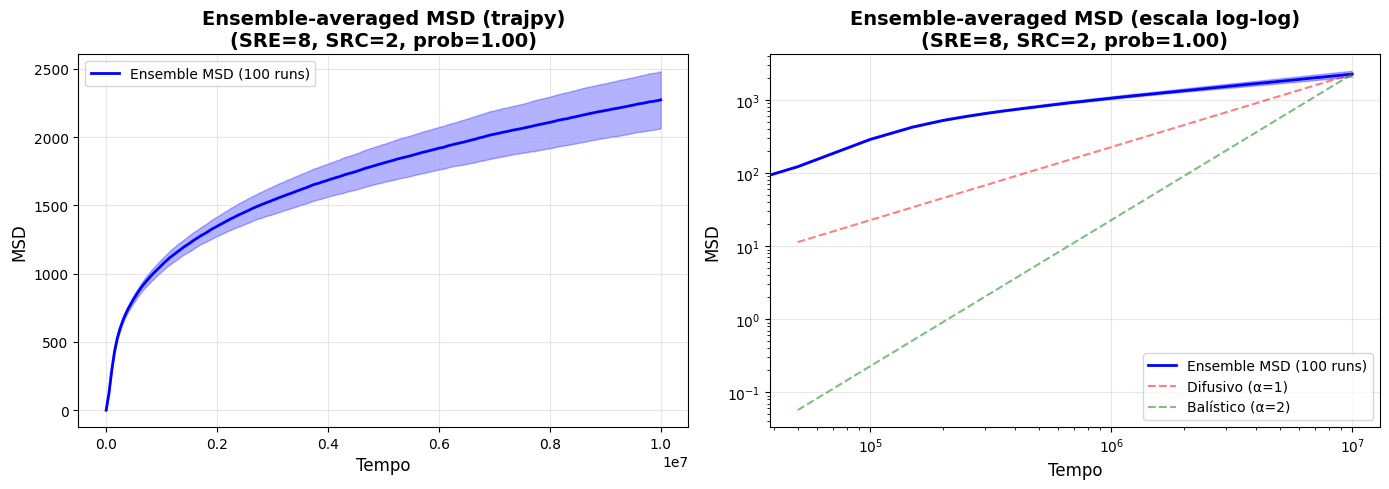


RESULTADOS ENSEMBLE-AVERAGED (trajpy) PARA SRE=8
Número de runs processados: 100
Tempo máximo: 9999999
MSD final: 2272.13 ± 209.17
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value
 ** On entry to DLASCL parameter number  5 had an illegal value
 ** On entry to DLASCL parameter number  4 had an illegal value


/tmp/ipykernel_840436/4130719759.py:184: RuntimeWarning: divide by zero encountered in log
  log_t = np.log(times[n_i:n_f])
/tmp/ipykernel_840436/4130719759.py:185: RuntimeWarning: divide by zero encountered in log
  log_msd = np.log(msd_mean[n_i:n_f])
/home/camafeu/Documentos/rossatto/github/Chase-escape_with_temporary_obstacles/venv/lib/python3.10/site-packages/numpy/lib/_polynomial_impl.py:665: RuntimeWarning: invalid value encountered in divide
  lhs /= scale


LinAlgError: SVD did not converge in Linear Least Squares

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from trajpy.trajpy import Trajectory
from scipy.interpolate import interp1d

# Configuração
sre = 8
prob = 1.00
num_runs = 100

# Caminho base
base_path = "/media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data/data_raw/"

print(f"Processando SRE = {sre} para {num_runs} runs...")
print(f"{'='*60}")

# Função para unwrap das trajetórias
def unwrap_trajectory(df_particle, L):
    """Desfaz condições de contorno periódicas para uma trajetória"""
    df_particle = df_particle.sort_values("time").copy()
    
    x_unwrapped = [df_particle["x"].iloc[0]]
    y_unwrapped = [df_particle["y"].iloc[0]]
    
    for i in range(1, len(df_particle)):
        dx = df_particle["x"].iloc[i] - df_particle["x"].iloc[i - 1]
        dy = df_particle["y"].iloc[i] - df_particle["y"].iloc[i - 1]
        
        if dx > L / 2:
            dx -= L
        elif dx < -L / 2:
            dx += L
        
        if dy > L / 2:
            dy -= L
        elif dy < -L / 2:
            dy += L
        
        x_unwrapped.append(x_unwrapped[-1] + dx)
        y_unwrapped.append(y_unwrapped[-1] + dy)
    
    df_particle["x_unwrapped"] = x_unwrapped
    df_particle["y_unwrapped"] = y_unwrapped
    
    return df_particle

# Parâmetros
L = 256

# Lista para armazenar MSD de todos os runs
all_runs_times = None
all_runs_msd = []
successful_runs = 0

# Loop sobre todos os runs
for run in range(1, num_runs + 1):
    file_path = f"{base_path}simulation_frac_25_run_{run}_obsprob_{prob:.2f}_SRC_2_SRE_{sre}/results_chasers_run{run}.csv"
    
    try:
        # Carregar dados
        df = pd.read_csv(file_path)
        
        # Fazer unwrap para cada partícula
        df_unwrapped_list = []
        for pid, group in df.groupby("id"):
            df_unwrapped = unwrap_trajectory(group, L)
            df_unwrapped_list.append(df_unwrapped)
        
        df_all = pd.concat(df_unwrapped_list, ignore_index=True)
        
        # Organizar posições por tempo para o ensemble MSD
        times = sorted(df_all["time"].unique())
        
        # Para cada tempo, pegar as posições de todas as partículas
        # O método msd_ensemble_averaged_ espera um array onde cada linha é uma trajetória
        # Mas para ensemble, precisamos de um array 3D: [n_particles, n_times, 2]
        
        # Obter todas as partículas únicas
        particle_ids = df_all["id"].unique()
        n_particles = len(particle_ids)
        n_times = len(times)
        
        # Criar array 3D: [partículas, tempos, coordenadas]
        positions_3d = np.zeros((n_particles, n_times, 2))
        
        for i, pid in enumerate(particle_ids):
            df_particle = df_all[df_all["id"] == pid].sort_values("time")
            for j, t in enumerate(times):
                pos = df_particle[df_particle["time"] == t][["x_unwrapped", "y_unwrapped"]].values
                if len(pos) > 0:
                    positions_3d[i, j] = pos[0]
                else:
                    # Se não tem posição neste tempo, usar a última conhecida
                    if j > 0:
                        positions_3d[i, j] = positions_3d[i, j-1]
        
        # Usar o método ensemble-averaged do trajpy
        # O método espera um array [n_times, n_particles, 2] ou similar
        # Vamos reorganizar para [n_particles, n_times, 2] e calcular MSD para cada partícula
        msd_ensemble = Trajectory.msd_ensemble_averaged_(positions_3d.transpose(1, 0, 2))
        
        # Alinhar com runs anteriores
        if all_runs_times is None:
            all_runs_times = np.array(times)
            all_runs_msd.append(msd_ensemble)
            successful_runs += 1
        elif len(times) == len(all_runs_times):
            all_runs_msd.append(msd_ensemble)
            successful_runs += 1
        else:
            # Interpolar se necessário
            f_interp = interp1d(times, msd_ensemble, kind='linear', fill_value='extrapolate')
            msd_interp = f_interp(all_runs_times)
            all_runs_msd.append(msd_interp)
            successful_runs += 1
        
        if run % 10 == 0:
            print(f"  Processados {run}/{num_runs} runs...")
            
    except FileNotFoundError:
        print(f"  Arquivo não encontrado: run {run}")
        continue
    except Exception as e:
        print(f"  Erro no run {run}: {e}")
        continue

if all_runs_msd:
    # Calcular média e desvio padrão sobre todos os runs
    all_runs_msd = np.array(all_runs_msd)
    msd_mean = np.mean(all_runs_msd, axis=0)
    msd_std = np.std(all_runs_msd, axis=0)
    
    times = all_runs_times
    
    # Plotar resultados
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Gráfico 1: MSD linear
    ax1 = axes[0]
    ax1.plot(times, msd_mean, 'b-', linewidth=2, label=f'Ensemble MSD ({successful_runs} runs)')
    ax1.fill_between(times, msd_mean - msd_std, msd_mean + msd_std, alpha=0.3, color='blue')
    ax1.set_xlabel('Tempo', fontsize=12)
    ax1.set_ylabel('MSD', fontsize=12)
    ax1.set_title(f'Ensemble-averaged MSD (trajpy)\n(SRE={sre}, SRC=2, prob={prob:.2f})', 
                 fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Gráfico 2: MSD log-log
    ax2 = axes[1]
    ax2.loglog(times, msd_mean, 'b-', linewidth=2, label=f'Ensemble MSD ({successful_runs} runs)')
    ax2.fill_between(times, msd_mean - msd_std, msd_mean + msd_std, alpha=0.3, color='blue')
    
    # Linhas de referência
    tau_ref = np.logspace(np.log10(times[1]), np.log10(times[-1]), 10)
    msd_ref_diffusive = tau_ref / tau_ref[-1] * msd_mean[-1]
    msd_ref_ballistic = (tau_ref**2) / (tau_ref[-1]**2) * msd_mean[-1]
    
    ax2.loglog(tau_ref, msd_ref_diffusive, 'r--', alpha=0.5, label='Difusivo (α=1)')
    ax2.loglog(tau_ref, msd_ref_ballistic, 'g--', alpha=0.5, label='Balístico (α=2)')
    
    ax2.set_xlabel('Tempo', fontsize=12)
    ax2.set_ylabel('MSD', fontsize=12)
    ax2.set_title(f'Ensemble-averaged MSD (escala log-log)\n(SRE={sre}, SRC=2, prob={prob:.2f})', 
                 fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Estatísticas finais
    print(f"\n{'='*60}")
    print(f"RESULTADOS ENSEMBLE-AVERAGED (trajpy) PARA SRE={sre}")
    print(f"{'='*60}")
    print(f"Número de runs processados: {successful_runs}")
    print(f"Tempo máximo: {times[-1]}")
    print(f"MSD final: {msd_mean[-1]:.2f} ± {msd_std[-1]:.2f}")
    
    # Expoente α
    n_i, n_f = 0, min(10, len(times))
    if n_f > n_i:
        log_t = np.log(times[n_i:n_f])
        log_msd = np.log(msd_mean[n_i:n_f])
        alpha = np.polyfit(log_t, log_msd, 1)[0]
        print(f"Expoente α (primeiros {n_f} passos): {alpha:.3f}")
    print(f"{'='*60}")
else:
    print("Nenhum dado válido encontrado!")

### Teste

Processando prob = 0.60...

VALORES REAIS EXTRAÍDOS DOS DADOS
N(0) real = 6380.9100
N(∞) real = 1.7800

Parâmetros fixos:
  A = N(0) - N(∞) = 6379.1300
  C = N(∞) = 1.7800


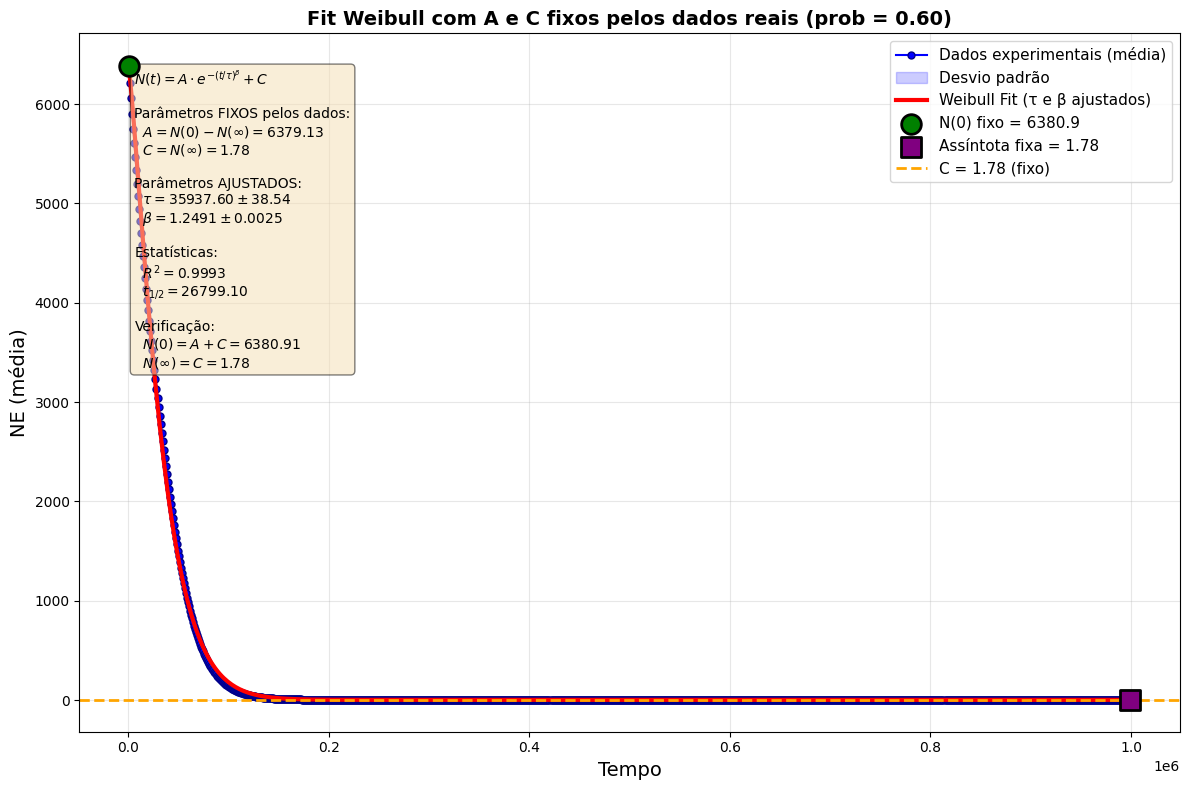


RESULTADOS DO FIT - prob = 0.60
Parâmetros FIXOS (dos dados reais):
  A = 6379.1300
  C = 1.7800

Parâmetros AJUSTADOS:
  τ = 35937.5987 ± 38.5417
  β = 1.2491 ± 0.0025

Estatísticas:
  R² = 0.9993
  Tempo de meia-vida = 26799.10

Verificação física:
  N(0) = A + C = 6380.91 (deveria ser 6380.91) ✓
  N(∞) = C = 1.78 (deveria ser 1.78) ✓

INTERPRETAÇÃO FÍSICA
β = 1.249 > 1: Decaimento ACELERADO
  → Taxa de decaimento AUMENTA com o tempo
  → Efeito cooperativo ou de obstáculos
  → Os escapers saem mais rápido no início


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# Caminho base
base_path = "/media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data/data_raw/"

# Probabilidade específica
prob = 0.60

# Número de runs
num_runs = 100

# Lista para armazenar os dados
todos_dados_NE = []

print(f"Processando prob = {prob:.2f}...")

# Ler todos os runs para esta probabilidade
for run in range(1, num_runs + 1):
    try:
        caminho = f"{base_path}simulation_frac_100run{run}obsprob{prob:.2f}/results_N_escapers_run{run}.csv"
        df = pd.read_csv(caminho)
        
        # Começar a partir da segunda linha
        df_cortado = df.iloc[1:].reset_index(drop=True)
        
        # Identificar a coluna de dados (exceto 'time')
        col_NE = [col for col in df_cortado.columns if col != 'time'][0]
        
        # Guardar os valores
        todos_dados_NE.append(df_cortado[col_NE].values)
        
    except FileNotFoundError:
        continue
    except Exception as e:
        continue

if todos_dados_NE:
    # Converter para array numpy
    todos_dados_NE = np.array(todos_dados_NE)
    
    # Calcular média e desvio padrão
    media = np.mean(todos_dados_NE, axis=0)
    desvio_padrao = np.std(todos_dados_NE, axis=0)
    
    # Tempo
    tempo = df_cortado['time'].values
    
    # VALORES REAIS (extraídos diretamente dos dados)
    N0_real = media[0]      # Valor inicial real
    Ninf_real = media[-1]    # Valor final real (assíntota)
    
    # Calcular A e C a partir dos valores reais
    C_fixo = Ninf_real    # Assíntota fixa
    A_fixo = N0_real - C_fixo  # Amplitude fixa
    
    print("\n" + "="*60)
    print("VALORES REAIS EXTRAÍDOS DOS DADOS")
    print("="*60)
    print(f"N(0) real = {N0_real:.4f}")
    print(f"N(∞) real = {Ninf_real:.4f}")
    print(f"\nParâmetros fixos:")
    print(f"  A = N(0) - N(∞) = {A_fixo:.4f}")
    print(f"  C = N(∞) = {C_fixo:.4f}")
    print("="*60)
    
    # Função de decaimento Weibull com A e C fixos
    def weibull_decay_fixed(t, tau, beta):
        """A e C são fixos pelos valores reais dos dados"""
        return A_fixo * np.exp(-(t / tau)**beta) + C_fixo
    
    # Chutes iniciais para τ e β
    tau_guess = tempo[len(tempo)//2]  # tempo característico
    beta_guess = 1.5  # forma inicial
    
    # Fazer o fit (apenas τ e β)
    try:
        popt, pcov = curve_fit(weibull_decay_fixed, tempo, media,
                               p0=[tau_guess, beta_guess],
                               bounds=([0, 0], [np.inf, np.inf]),  # τ>0, β>0
                               maxfev=5000)
        
        tau_fit, beta_fit = popt
        
        # Erros dos parâmetros
        perr = np.sqrt(np.diag(pcov))
        
        # Gerar curva ajustada
        tempo_fit = np.linspace(min(tempo), max(tempo), 500)
        media_fit = weibull_decay_fixed(tempo_fit, tau_fit, beta_fit)
        
        # Calcular R²
        residuos = media - weibull_decay_fixed(tempo, tau_fit, beta_fit)
        ss_res = np.sum(residuos**2)
        ss_tot = np.sum((media - np.mean(media))**2)
        r_squared = 1 - (ss_res / ss_tot)
        
        # Calcular tempo de meia-vida
        half_value = (N0_real + C_fixo) / 2
        half_life = tau_fit * (-np.log((half_value - C_fixo)/A_fixo))**(1/beta_fit)
        
        # Plotar
        plt.figure(figsize=(12, 8))
        
        # Dados experimentais
        plt.plot(tempo, media, 'bo-', label='Dados experimentais (média)', 
                 markersize=5, linewidth=1.5, markerfacecolor='blue', 
                 markeredgecolor='darkblue', markeredgewidth=1)
        
        # Banda de desvio padrão
        plt.fill_between(tempo, media - desvio_padrao, media + desvio_padrao, 
                         alpha=0.2, color='blue', label='Desvio padrão')
        
        # Curva do fit (apenas τ e β ajustados)
        plt.plot(tempo_fit, media_fit, 'r-', linewidth=3, label='Weibull Fit (τ e β ajustados)')
        
        # Destacar ponto inicial (fixo pelos dados)
        plt.scatter(tempo[0], N0_real, color='green', s=200, zorder=5, 
                   edgecolors='black', linewidths=2, 
                   label=f'N(0) fixo = {N0_real:.1f}')
        
        # Destacar ponto final (assíntota fixa pelos dados)
        plt.scatter(tempo[-1], C_fixo, color='purple', s=200, zorder=5, 
                   edgecolors='black', linewidths=2, marker='s',
                   label=f'Assíntota fixa = {C_fixo:.2f}')
        
        # Linha da assíntota
        plt.axhline(y=C_fixo, color='orange', linestyle='--', linewidth=2,
                   label=f'C = {C_fixo:.2f} (fixo)')
        
        plt.xlabel('Tempo', fontsize=14)
        plt.ylabel('NE (média)', fontsize=14)
        plt.title(f'Fit Weibull com A e C fixos pelos dados reais (prob = {prob:.2f})', 
                  fontsize=14, fontweight='bold')
        plt.legend(fontsize=11, loc='best')
        plt.grid(True, alpha=0.3)
        
        # Texto com parâmetros
        textstr = f'$N(t) = A \\cdot e^{{-(t/\\tau)^{{\\beta}}}} + C$\n\n' \
                  f'Parâmetros FIXOS pelos dados:\n' \
                  f'  $A = N(0)-N(\\infty) = {A_fixo:.2f}$\n' \
                  f'  $C = N(\\infty) = {C_fixo:.2f}$\n\n' \
                  f'Parâmetros AJUSTADOS:\n' \
                  f'  $\\tau = {tau_fit:.2f} \\pm {perr[0]:.2f}$\n' \
                  f'  $\\beta = {beta_fit:.4f} \\pm {perr[1]:.4f}$\n\n' \
                  f'Estatísticas:\n' \
                  f'  $R^2 = {r_squared:.4f}$\n' \
                  f'  $t_{{1/2}} = {half_life:.2f}$\n\n' \
                  f'Verificação:\n' \
                  f'  $N(0) = A + C = {A_fixo + C_fixo:.2f}$\n' \
                  f'  $N(\\infty) = C = {C_fixo:.2f}$'
        
        plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, 
                 fontsize=10, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        plt.tight_layout()
        plt.show()
        
        # Resultados
        print("\n" + "="*70)
        print(f"RESULTADOS DO FIT - prob = {prob:.2f}")
        print("="*70)
        print(f"Parâmetros FIXOS (dos dados reais):")
        print(f"  A = {A_fixo:.4f}")
        print(f"  C = {C_fixo:.4f}")
        print(f"\nParâmetros AJUSTADOS:")
        print(f"  τ = {tau_fit:.4f} ± {perr[0]:.4f}")
        print(f"  β = {beta_fit:.4f} ± {perr[1]:.4f}")
        print(f"\nEstatísticas:")
        print(f"  R² = {r_squared:.4f}")
        print(f"  Tempo de meia-vida = {half_life:.2f}")
        print(f"\nVerificação física:")
        print(f"  N(0) = A + C = {A_fixo + C_fixo:.2f} (deveria ser {N0_real:.2f}) ✓")
        print(f"  N(∞) = C = {C_fixo:.2f} (deveria ser {Ninf_real:.2f}) ✓")
        print("="*70)
        
        # Interpretação do β
        print("\n" + "="*70)
        print("INTERPRETAÇÃO FÍSICA")
        print("="*70)
        if beta_fit < 1:
            print(f"β = {beta_fit:.3f} < 1: Decaimento LENTO no início")
            print("  → Taxa de decaimento diminui com o tempo")
            print("  → Sistema com memória longa")
        elif beta_fit == 1:
            print(f"β = {beta_fit:.3f} = 1: Decaimento EXPONENCIAL")
            print("  → Taxa de decaimento constante")
            print("  → Processo sem memória (Markoviano)")
        else:
            print(f"β = {beta_fit:.3f} > 1: Decaimento ACELERADO")
            print("  → Taxa de decaimento AUMENTA com o tempo")
            print("  → Efeito cooperativo ou de obstáculos")
            print("  → Os escapers saem mais rápido no início")
        print("="*70)
        
    except Exception as e:
        print(f"Erro no fit: {e}")

Processando prob = 0.10...

VALORES REAIS EXTRAÍDOS DOS DADOS
N(0) real = 6382.6800
N(∞) real = 0.0000

Parâmetros fixos:
  A = N(0) - N(∞) = 6382.6800
  C = N(∞) = 0.0000


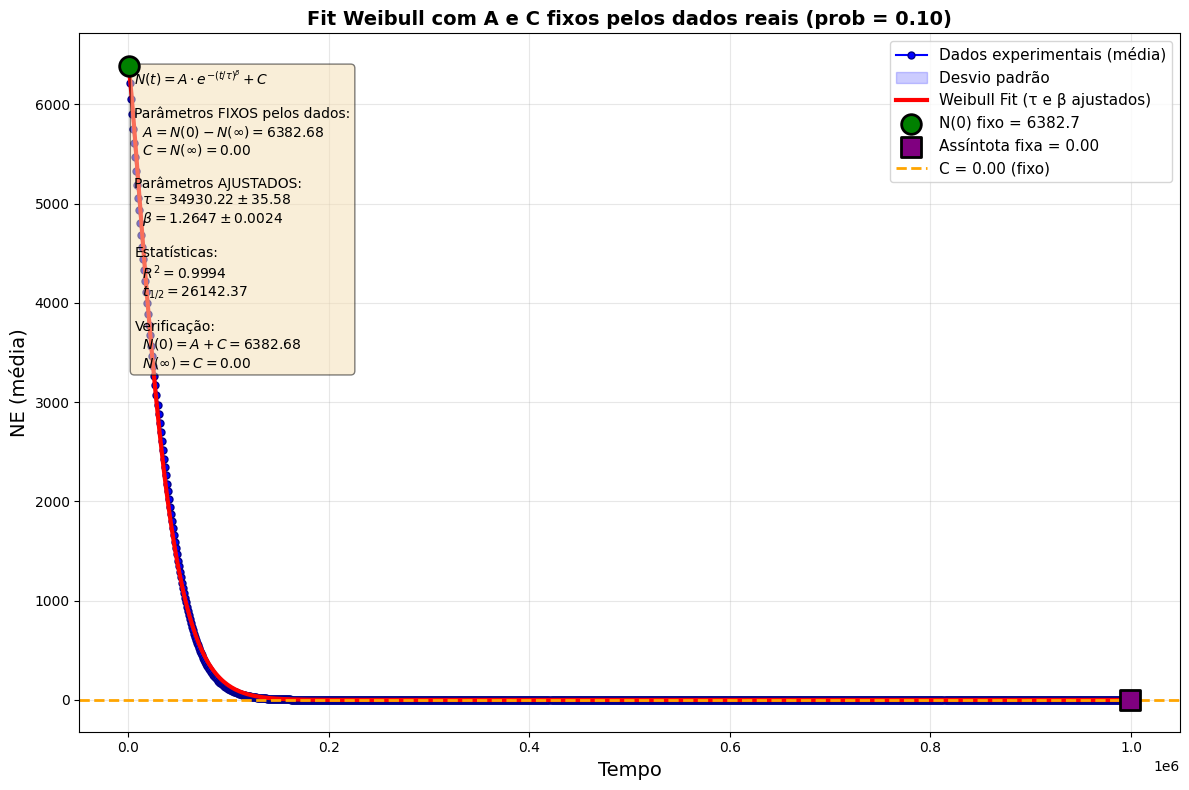


RESULTADOS DO FIT - prob = 0.10
Parâmetros FIXOS (dos dados reais):
  A = 6382.6800
  C = 0.0000

Parâmetros AJUSTADOS:
  τ = 34930.2181 ± 35.5777
  β = 1.2647 ± 0.0024

Estatísticas:
  R² = 0.9994
  Tempo de meia-vida = 26142.37

Verificação física:
  N(0) = A + C = 6382.68 (deveria ser 6382.68) ✓
  N(∞) = C = 0.00 (deveria ser 0.00) ✓

INTERPRETAÇÃO FÍSICA
β = 1.265 > 1: Decaimento ACELERADO
  → Taxa de decaimento AUMENTA com o tempo
  → Efeito cooperativo ou de obstáculos
  → Os escapers saem mais rápido no início


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# Caminho base
base_path = "/media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data/data_raw/"

# Probabilidade específica
prob = 0.10

# Número de runs
num_runs = 100

# Lista para armazenar os dados
todos_dados_NE = []

print(f"Processando prob = {prob:.2f}...")

# Ler todos os runs para esta probabilidade
for run in range(1, num_runs + 1):
    try:
        caminho = f"{base_path}simulation_frac_100run{run}obsprob{prob:.2f}/results_N_escapers_run{run}.csv"
        df = pd.read_csv(caminho)
        
        # Começar a partir da segunda linha
        df_cortado = df.iloc[1:].reset_index(drop=True)
        
        # Identificar a coluna de dados (exceto 'time')
        col_NE = [col for col in df_cortado.columns if col != 'time'][0]
        
        # Guardar os valores
        todos_dados_NE.append(df_cortado[col_NE].values)
        
    except FileNotFoundError:
        continue
    except Exception as e:
        continue

if todos_dados_NE:
    # Converter para array numpy
    todos_dados_NE = np.array(todos_dados_NE)
    
    # Calcular média e desvio padrão
    media = np.mean(todos_dados_NE, axis=0)
    desvio_padrao = np.std(todos_dados_NE, axis=0)
    
    # Tempo
    tempo = df_cortado['time'].values
    
    # VALORES REAIS (extraídos diretamente dos dados)
    N0_real = media[0]      # Valor inicial real
    Ninf_real = media[-1]    # Valor final real (assíntota)
    
    # Calcular A e C a partir dos valores reais
    C_fixo = Ninf_real    # Assíntota fixa
    A_fixo = N0_real - C_fixo  # Amplitude fixa
    
    print("\n" + "="*60)
    print("VALORES REAIS EXTRAÍDOS DOS DADOS")
    print("="*60)
    print(f"N(0) real = {N0_real:.4f}")
    print(f"N(∞) real = {Ninf_real:.4f}")
    print(f"\nParâmetros fixos:")
    print(f"  A = N(0) - N(∞) = {A_fixo:.4f}")
    print(f"  C = N(∞) = {C_fixo:.4f}")
    print("="*60)
    
    # Função de decaimento Weibull com A e C fixos
    def weibull_decay_fixed(t, tau, beta):
        """A e C são fixos pelos valores reais dos dados"""
        return A_fixo * np.exp(-(t / tau)**beta) + C_fixo
    
    # Chutes iniciais para τ e β
    tau_guess = tempo[len(tempo)//2]  # tempo característico
    beta_guess = 1.5  # forma inicial
    
    # Fazer o fit (apenas τ e β)
    try:
        popt, pcov = curve_fit(weibull_decay_fixed, tempo, media,
                               p0=[tau_guess, beta_guess],
                               bounds=([0, 0], [np.inf, np.inf]),  # τ>0, β>0
                               maxfev=5000)
        
        tau_fit, beta_fit = popt
        
        # Erros dos parâmetros
        perr = np.sqrt(np.diag(pcov))
        
        # Gerar curva ajustada
        tempo_fit = np.linspace(min(tempo), max(tempo), 500)
        media_fit = weibull_decay_fixed(tempo_fit, tau_fit, beta_fit)
        
        # Calcular R²
        residuos = media - weibull_decay_fixed(tempo, tau_fit, beta_fit)
        ss_res = np.sum(residuos**2)
        ss_tot = np.sum((media - np.mean(media))**2)
        r_squared = 1 - (ss_res / ss_tot)
        
        # Calcular tempo de meia-vida
        half_value = (N0_real + C_fixo) / 2
        half_life = tau_fit * (-np.log((half_value - C_fixo)/A_fixo))**(1/beta_fit)
        
        # Plotar
        plt.figure(figsize=(12, 8))
        
        # Dados experimentais
        plt.plot(tempo, media, 'bo-', label='Dados experimentais (média)', 
                 markersize=5, linewidth=1.5, markerfacecolor='blue', 
                 markeredgecolor='darkblue', markeredgewidth=1)
        
        # Banda de desvio padrão
        plt.fill_between(tempo, media - desvio_padrao, media + desvio_padrao, 
                         alpha=0.2, color='blue', label='Desvio padrão')
        
        # Curva do fit (apenas τ e β ajustados)
        plt.plot(tempo_fit, media_fit, 'r-', linewidth=3, label='Weibull Fit (τ e β ajustados)')
        
        # Destacar ponto inicial (fixo pelos dados)
        plt.scatter(tempo[0], N0_real, color='green', s=200, zorder=5, 
                   edgecolors='black', linewidths=2, 
                   label=f'N(0) fixo = {N0_real:.1f}')
        
        # Destacar ponto final (assíntota fixa pelos dados)
        plt.scatter(tempo[-1], C_fixo, color='purple', s=200, zorder=5, 
                   edgecolors='black', linewidths=2, marker='s',
                   label=f'Assíntota fixa = {C_fixo:.2f}')
        
        # Linha da assíntota
        plt.axhline(y=C_fixo, color='orange', linestyle='--', linewidth=2,
                   label=f'C = {C_fixo:.2f} (fixo)')
        
        plt.xlabel('Tempo', fontsize=14)
        plt.ylabel('NE (média)', fontsize=14)
        plt.title(f'Fit Weibull com A e C fixos pelos dados reais (prob = {prob:.2f})', 
                  fontsize=14, fontweight='bold')
        plt.legend(fontsize=11, loc='best')
        plt.grid(True, alpha=0.3)
        
        # Texto com parâmetros
        textstr = f'$N(t) = A \\cdot e^{{-(t/\\tau)^{{\\beta}}}} + C$\n\n' \
                  f'Parâmetros FIXOS pelos dados:\n' \
                  f'  $A = N(0)-N(\\infty) = {A_fixo:.2f}$\n' \
                  f'  $C = N(\\infty) = {C_fixo:.2f}$\n\n' \
                  f'Parâmetros AJUSTADOS:\n' \
                  f'  $\\tau = {tau_fit:.2f} \\pm {perr[0]:.2f}$\n' \
                  f'  $\\beta = {beta_fit:.4f} \\pm {perr[1]:.4f}$\n\n' \
                  f'Estatísticas:\n' \
                  f'  $R^2 = {r_squared:.4f}$\n' \
                  f'  $t_{{1/2}} = {half_life:.2f}$\n\n' \
                  f'Verificação:\n' \
                  f'  $N(0) = A + C = {A_fixo + C_fixo:.2f}$\n' \
                  f'  $N(\\infty) = C = {C_fixo:.2f}$'
        
        plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, 
                 fontsize=10, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        plt.tight_layout()
        plt.show()
        
        # Resultados
        print("\n" + "="*70)
        print(f"RESULTADOS DO FIT - prob = {prob:.2f}")
        print("="*70)
        print(f"Parâmetros FIXOS (dos dados reais):")
        print(f"  A = {A_fixo:.4f}")
        print(f"  C = {C_fixo:.4f}")
        print(f"\nParâmetros AJUSTADOS:")
        print(f"  τ = {tau_fit:.4f} ± {perr[0]:.4f}")
        print(f"  β = {beta_fit:.4f} ± {perr[1]:.4f}")
        print(f"\nEstatísticas:")
        print(f"  R² = {r_squared:.4f}")
        print(f"  Tempo de meia-vida = {half_life:.2f}")
        print(f"\nVerificação física:")
        print(f"  N(0) = A + C = {A_fixo + C_fixo:.2f} (deveria ser {N0_real:.2f}) ✓")
        print(f"  N(∞) = C = {C_fixo:.2f} (deveria ser {Ninf_real:.2f}) ✓")
        print("="*70)
        
        # Interpretação do β
        print("\n" + "="*70)
        print("INTERPRETAÇÃO FÍSICA")
        print("="*70)
        if beta_fit < 1:
            print(f"β = {beta_fit:.3f} < 1: Decaimento LENTO no início")
            print("  → Taxa de decaimento diminui com o tempo")
            print("  → Sistema com memória longa")
        elif beta_fit == 1:
            print(f"β = {beta_fit:.3f} = 1: Decaimento EXPONENCIAL")
            print("  → Taxa de decaimento constante")
            print("  → Processo sem memória (Markoviano)")
        else:
            print(f"β = {beta_fit:.3f} > 1: Decaimento ACELERADO")
            print("  → Taxa de decaimento AUMENTA com o tempo")
            print("  → Efeito cooperativo ou de obstáculos")
            print("  → Os escapers saem mais rápido no início")
        print("="*70)
        
    except Exception as e:
        print(f"Erro no fit: {e}")

/tmp/ipykernel_3860870/1178653897.py:36: RuntimeWarning: invalid value encountered in divide
  D_instantaneo = df['msd_mean'].values / (2 * d * df['time'].values)
/home/camafeu/Documentos/rossatto/github/Chase-escape_with_temporary_obstacles/venv/lib/python3.10/site-packages/trajpy/auxiliar_functions.py:99: RuntimeWarning: divide by zero encountered in scalar divide
  A = 1. / np.power(4. * np.pi * D * t, 0.5)
/home/camafeu/Documentos/rossatto/github/Chase-escape_with_temporary_obstacles/venv/lib/python3.10/site-packages/trajpy/auxiliar_functions.py:100: RuntimeWarning: divide by zero encountered in scalar divide
  probability = A * np.exp(-np.power(r, 2) / (4. * D * t))
/home/camafeu/Documentos/rossatto/github/Chase-escape_with_temporary_obstacles/venv/lib/python3.10/site-packages/trajpy/auxiliar_functions.py:100: RuntimeWarning: invalid value encountered in scalar multiply
  probability = A * np.exp(-np.power(r, 2) / (4. * D * t))
/tmp/ipykernel_3860870/1178653897.py:36: RuntimeWarni

SRE=2: D_constante = 0.0001
SRE=4: D_constante = 0.0001
SRE=8: D_constante = 0.0001
SRE=10: D_constante = 0.0001
SRE=12: D_constante = 0.0001
SRE=14: D_constante = 0.0001
SRE=16: D_constante = 0.0001


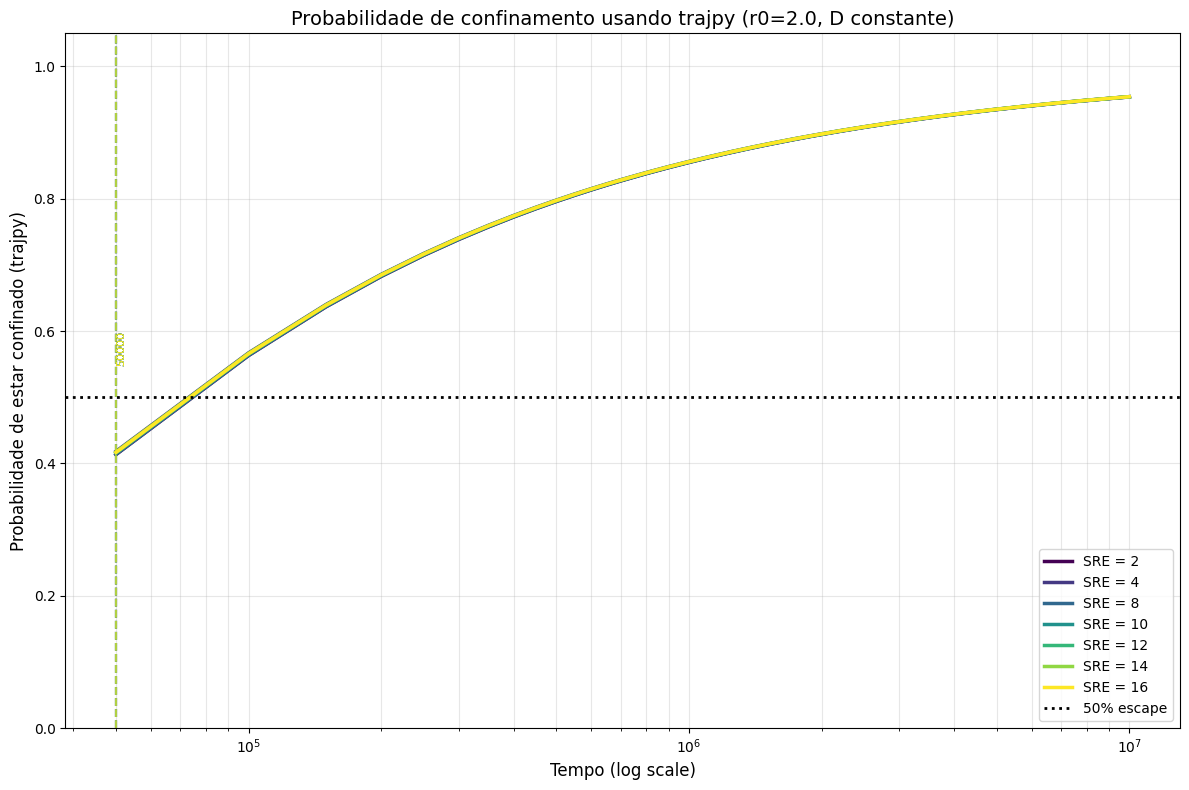

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from trajpy.trajpy import Trajectory

output_path = "/media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data_processed/MSD_25"
sre_list = [2, 4, 8, 10, 12, 14, 16]

# Parâmetros
r0 = 2.0      # Raio de confinamento
d = 2          # Dimensionalidade
N_integral = 100  # Número de pontos para integração numérica

# Cores
colors = plt.cm.viridis(np.linspace(0, 1, len(sre_list)))

# Plotar probabilidade de confinamento para cada SRE
fig, ax = plt.subplots(figsize=(12, 8))

for idx, sre in enumerate(sre_list):
    csv_file = Path(output_path) / f"SRE_{sre}" / f"msd_ensemble_SRE_{sre}.csv"
    
    if csv_file.exists():
        df = pd.read_csv(csv_file)
        
        # ============================================
        # ESTIMAR D CONSTANTE DO REGIME FINAL
        # ============================================
        # Usar últimos 20% dos pontos onde MSD ~ t (difusão normal)
        n_points = len(df)
        start_idx = int(0.8 * n_points)
        
        # Calcular D médio no regime final
        # D = MSD/(2*d*t)
        D_instantaneo = df['msd_mean'].values / (2 * d * df['time'].values)
        D_instantaneo[0] = D_instantaneo[1]  # Evitar divisão por zero
        
        # Média do regime final (ignorar possíveis outliers)
        D_constante = np.mean(D_instantaneo[start_idx:])
        
        print(f"SRE={sre}: D_constante = {D_constante:.4f}")
        
        # ============================================
        # CALCULAR PROBABILIDADE PARA CADA TEMPO USANDO TRAJPY
        # ============================================
        probabilidades = []
        tempos = df['time'].values
        
        for t in tempos:
            # Método do trajpy (retorna 1 - P(confinado)?)
            # Pelo seu código original: retorna 1 - probability
            prob = Trajectory.confinement_probability_(r0, D_constante, t, N_integral)
            probabilidades.append(prob)
        
        probabilidades = np.array(probabilidades)
        
        # Plotar
        ax.semilogx(tempos, probabilidades, 
                   color=colors[idx], linewidth=2.5,
                   label=f'SRE = {sre}')
        
        # Destacar tempo onde P=0.5 (50% de escape)
        mask_meia_vida = probabilidades <= 0.5
        if np.any(mask_meia_vida):
            t_meia_vida = tempos[mask_meia_vida][0]
            ax.axvline(x=t_meia_vida, color=colors[idx], linestyle='--', alpha=0.5)
            ax.text(t_meia_vida, 0.55, f'{t_meia_vida:.0f}', 
                   rotation=90, fontsize=8, color=colors[idx])

# Linha de referência em 50%
ax.axhline(y=0.5, color='black', linestyle=':', linewidth=2, label='50% escape')

ax.set_xlabel('Tempo (log scale)', fontsize=12)
ax.set_ylabel('Probabilidade de estar confinado (trajpy)', fontsize=12)
ax.set_title(f'Probabilidade de confinamento usando trajpy (r0={r0}, D constante)', fontsize=14)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3, which='both')
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(Path(output_path) / 'probabilidade_confinamento_trajpy.png', dpi=300)
plt.show()

## raio de giro

Arquivo: /media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data/data_raw/simulation_frac_25_run_1_obsprob_1.00_SRC_2_SRE_2/results_chasers_run1.csv
Total de partículas: 1638
Total de pontos: 329238
Tempo máximo: 9999999

Processando 100 partículas...
----------------------------------------
  Processadas 10/100 partículas...
  Processadas 20/100 partículas...
  Processadas 30/100 partículas...
  Processadas 40/100 partículas...
  Processadas 50/100 partículas...
  Processadas 60/100 partículas...
  Processadas 70/100 partículas...
  Processadas 80/100 partículas...
  Processadas 90/100 partículas...
  Processadas 100/100 partículas...
----------------------------------------
Processamento concluído! 100 partículas processadas.

RESULTADOS - SRE=2, Run=1
Partículas processadas: 100

Raio de Giro (Rg):
  Média:     1.7621
  Desvio:    0.7996
  Mínimo:    0.6325
  Máximo:    3.8281
  Mediana:   1.5647

Componentes do tensor:
  Rg_xx:     1.8349 ± 1.9024
  Rg_yy:     

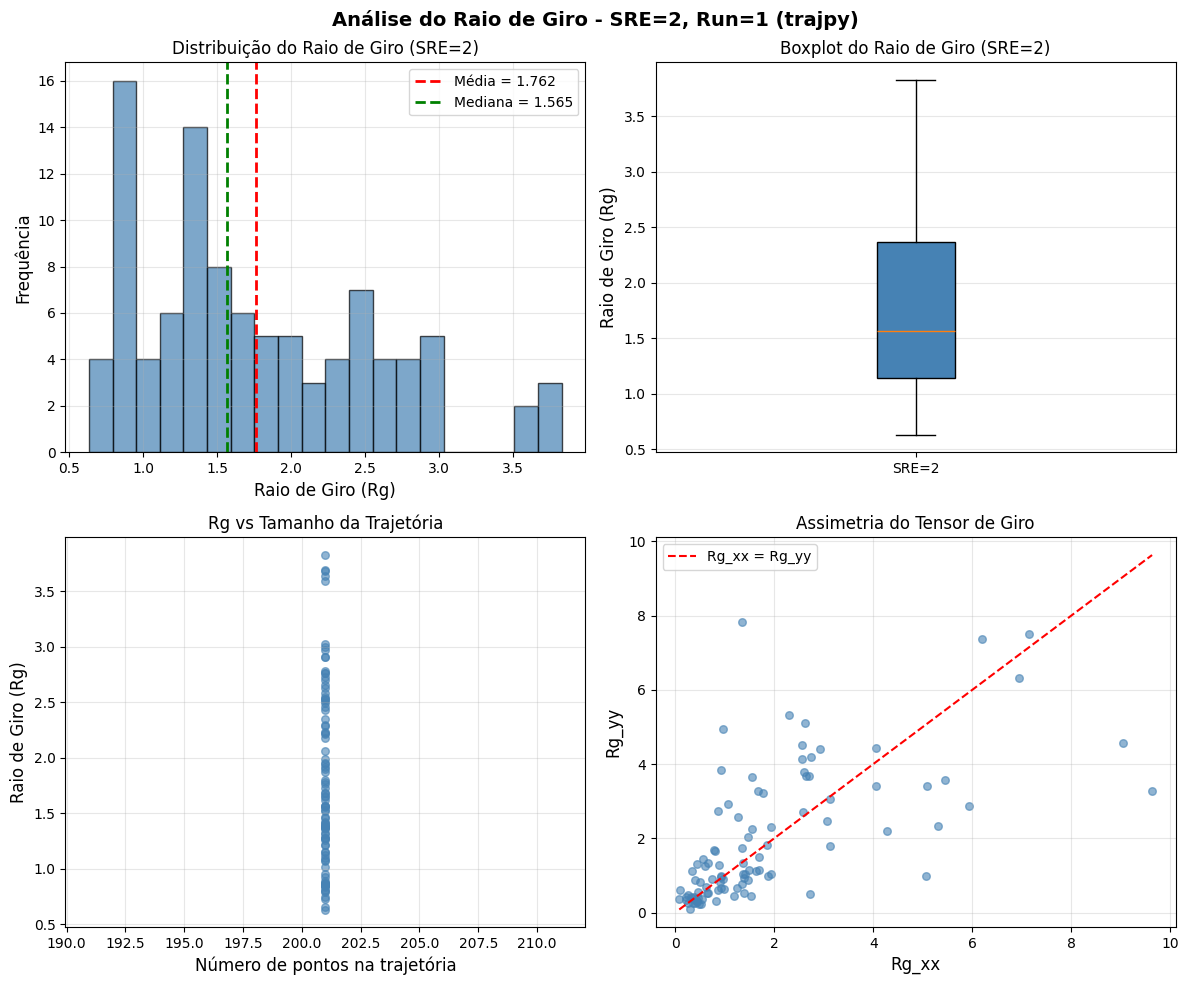


Resultados salvos em: gyration_radius_results_SRE_2_run_1.csv
Gráfico salvo em: gyration_radius_SRE_2_run_1.png

TOP 5 PARTÍCULAS - MAIOR RAIO DE GIRO
 particle_id       Rg    Rg_xx    Rg_yy  n_points
          56 3.828096 7.151084 7.503234       201
          95 3.691066 9.043285 4.580684       201
          49 3.684590 6.200913 7.375294       201
          80 3.643229 6.942138 6.330980       201
          24 3.593080 9.634468 3.275758       201

TOP 5 PARTÍCULAS - MENOR RAIO DE GIRO
 particle_id       Rg    Rg_xx    Rg_yy  n_points
          61 0.632534 0.301012 0.099087       201
          39 0.657378 0.081243 0.350902       201
          28 0.724418 0.263947 0.260834       201
          35 0.746474 0.215180 0.342044       201
          89 0.794682 0.363786 0.267734       201


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import trajpy.trajpy as tj
import warnings
warnings.filterwarnings('ignore')  # Suprime os warnings

# ============================================
# CONFIGURAÇÕES
# ============================================
base_path = "/media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data/data_raw/"
frac = 25
prob = 1.00
sre = 2          # SRE que quer analisar
run = 1          # Run que quer analisar
L = 256          # Tamanho da caixa

# Limite de partículas (None = todas)
max_particles = 100

# ============================================
# FUNÇÃO PARA UNWRAP DAS TRAJETÓRIAS
# ============================================
def unwrap_trajectory(df_particle, L):
    """Desfaz condições de contorno periódicas para uma trajetória"""
    df_particle = df_particle.sort_values("time").copy()
    
    x_unwrapped = [df_particle["x"].iloc[0]]
    y_unwrapped = [df_particle["y"].iloc[0]]
    
    for i in range(1, len(df_particle)):
        dx = df_particle["x"].iloc[i] - df_particle["x"].iloc[i - 1]
        dy = df_particle["y"].iloc[i] - df_particle["y"].iloc[i - 1]
        
        if dx > L / 2:
            dx -= L
        elif dx < -L / 2:
            dx += L
        
        if dy > L / 2:
            dy -= L
        elif dy < -L / 2:
            dy += L
        
        x_unwrapped.append(x_unwrapped[-1] + dx)
        y_unwrapped.append(y_unwrapped[-1] + dy)
    
    df_particle["x_unwrapped"] = x_unwrapped
    df_particle["y_unwrapped"] = y_unwrapped
    
    return df_particle

# ============================================
# FUNÇÃO PARA CALCULAR RAIO DE GIRO COM TRAJPY
# ============================================
def calculate_gyration_radius_trajpy(df_particle, L):
    """Calcula o raio de giro usando trajpy"""
    # Fazer unwrap
    df_unwrapped = unwrap_trajectory(df_particle, L)
    
    # Preparar dados no formato do trajpy (t, x, y, z)
    df_traj = df_unwrapped[["time", "x_unwrapped", "y_unwrapped"]].copy()
    df_traj["z"] = 0
    df_traj.columns = ["t", "x", "y", "z"]
    
    # Salvar arquivo temporário
    temp_file = "/tmp/temp_traj.csv"
    df_traj.to_csv(temp_file, index=False)
    
    # Carregar no trajpy e calcular features
    traj = tj.Trajectory(temp_file, skip_header=1, delimiter=',')
    traj.compute_features()
    
    # Extrair raio de giro (tensor 3x3)
    Rg_tensor = traj.gyration_radius
    
    # Calcular raio de giro escalar (traço do tensor)
    Rg = np.sqrt(Rg_tensor[0, 0] + Rg_tensor[1, 1])
    
    return Rg, Rg_tensor

# ============================================
# CARREGAR DADOS
# ============================================
file_path = f"{base_path}simulation_frac_{frac}_run_{run}_obsprob_{prob:.2f}_SRC_2_SRE_{sre}/results_chasers_run{run}.csv"
df = pd.read_csv(file_path)

print(f"Arquivo: {file_path}")
print(f"Total de partículas: {df['id'].nunique()}")
print(f"Total de pontos: {len(df)}")
print(f"Tempo máximo: {df['time'].max()}")
print()

# ============================================
# CALCULAR RAIO DE GIRO PARA CADA PARTÍCULA
# ============================================
resultados = []
particle_ids = df['id'].unique()

# Limitar número de partículas
if max_particles:
    particle_ids = particle_ids[:max_particles]

print(f"Processando {len(particle_ids)} partículas...")
print("-" * 40)

for idx, pid in enumerate(particle_ids):
    # Filtrar partícula
    df_particle = df[df['id'] == pid].copy()
    
    # Calcular raio de giro
    try:
        Rg, Rg_tensor = calculate_gyration_radius_trajpy(df_particle, L)
        
        resultados.append({
            'particle_id': pid,
            'Rg': Rg,
            'Rg_xx': Rg_tensor[0, 0],
            'Rg_yy': Rg_tensor[1, 1],
            'Rg_xy': Rg_tensor[0, 1],
            'n_points': len(df_particle)
        })
        
        if (idx + 1) % 10 == 0:
            print(f"  Processadas {idx + 1}/{len(particle_ids)} partículas...")
            
    except Exception as e:
        print(f"  Erro na partícula {pid}: {e}")
        continue

print("-" * 40)
print(f"Processamento concluído! {len(resultados)} partículas processadas.")
print()

# ============================================
# RESULTADOS AGREGADOS
# ============================================
df_results = pd.DataFrame(resultados)

print("=" * 60)
print(f"RESULTADOS - SRE={sre}, Run={run}")
print("=" * 60)
print(f"Partículas processadas: {len(df_results)}")
print()
print(f"Raio de Giro (Rg):")
print(f"  Média:     {df_results['Rg'].mean():.4f}")
print(f"  Desvio:    {df_results['Rg'].std():.4f}")
print(f"  Mínimo:    {df_results['Rg'].min():.4f}")
print(f"  Máximo:    {df_results['Rg'].max():.4f}")
print(f"  Mediana:   {df_results['Rg'].median():.4f}")
print()
print(f"Componentes do tensor:")
print(f"  Rg_xx:     {df_results['Rg_xx'].mean():.4f} ± {df_results['Rg_xx'].std():.4f}")
print(f"  Rg_yy:     {df_results['Rg_yy'].mean():.4f} ± {df_results['Rg_yy'].std():.4f}")
print(f"  Rg_xy:     {df_results['Rg_xy'].mean():.4f} ± {df_results['Rg_xy'].std():.4f}")
print("=" * 60)

# ============================================
# GRÁFICOS
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Gráfico 1: Histograma do Raio de Giro
ax1 = axes[0, 0]
ax1.hist(df_results['Rg'], bins=20, edgecolor='black', color='steelblue', alpha=0.7)
ax1.axvline(df_results['Rg'].mean(), color='red', linestyle='--', linewidth=2,
           label=f'Média = {df_results["Rg"].mean():.3f}')
ax1.axvline(df_results['Rg'].median(), color='green', linestyle='--', linewidth=2,
           label=f'Mediana = {df_results["Rg"].median():.3f}')
ax1.set_xlabel('Raio de Giro (Rg)', fontsize=12)
ax1.set_ylabel('Frequência', fontsize=12)
ax1.set_title(f'Distribuição do Raio de Giro (SRE={sre})', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Boxplot do Raio de Giro
ax2 = axes[0, 1]
bp = ax2.boxplot(df_results['Rg'], vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
ax2.set_ylabel('Raio de Giro (Rg)', fontsize=12)
ax2.set_title(f'Boxplot do Raio de Giro (SRE={sre})', fontsize=12)
ax2.set_xticklabels([f'SRE={sre}'])
ax2.grid(True, alpha=0.3, axis='y')

# Gráfico 3: Rg vs Número de pontos
ax3 = axes[1, 0]
ax3.scatter(df_results['n_points'], df_results['Rg'], alpha=0.6, c='steelblue', s=30)
ax3.set_xlabel('Número de pontos na trajetória', fontsize=12)
ax3.set_ylabel('Raio de Giro (Rg)', fontsize=12)
ax3.set_title('Rg vs Tamanho da Trajetória', fontsize=12)
ax3.grid(True, alpha=0.3)

# Gráfico 4: Componentes do tensor (Rg_xx vs Rg_yy)
ax4 = axes[1, 1]
ax4.scatter(df_results['Rg_xx'], df_results['Rg_yy'], alpha=0.6, c='steelblue', s=30)
ax4.plot([df_results['Rg_xx'].min(), df_results['Rg_xx'].max()], 
         [df_results['Rg_xx'].min(), df_results['Rg_xx'].max()], 
         'r--', label='Rg_xx = Rg_yy')
ax4.set_xlabel('Rg_xx', fontsize=12)
ax4.set_ylabel('Rg_yy', fontsize=12)
ax4.set_title('Assimetria do Tensor de Giro', fontsize=12)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle(f'Análise do Raio de Giro - SRE={sre}, Run={run} (trajpy)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'gyration_radius_SRE_{sre}_run_{run}.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# SALVAR RESULTADOS
# ============================================
output_file = f'gyration_radius_results_SRE_{sre}_run_{run}.csv'
df_results.to_csv(output_file, index=False)
print(f"\nResultados salvos em: {output_file}")
print(f"Gráfico salvo em: gyration_radius_SRE_{sre}_run_{run}.png")

# ============================================
# TOP 5 PARTÍCULAS
# ============================================
print("\n" + "=" * 60)
print("TOP 5 PARTÍCULAS - MAIOR RAIO DE GIRO")
print("=" * 60)
top5 = df_results.nlargest(5, 'Rg')[['particle_id', 'Rg', 'Rg_xx', 'Rg_yy', 'n_points']]
print(top5.to_string(index=False))

print("\n" + "=" * 60)
print("TOP 5 PARTÍCULAS - MENOR RAIO DE GIRO")
print("=" * 60)
bottom5 = df_results.nsmallest(5, 'Rg')[['particle_id', 'Rg', 'Rg_xx', 'Rg_yy', 'n_points']]
print(bottom5.to_string(index=False))

## Plot do RG

### NC = 0.25NE

#### SR = 2

SRE=2, Fração=25%
Total de partículas: 163,800
Média do Rg: 4.4896
Mediana do Rg: 3.0523



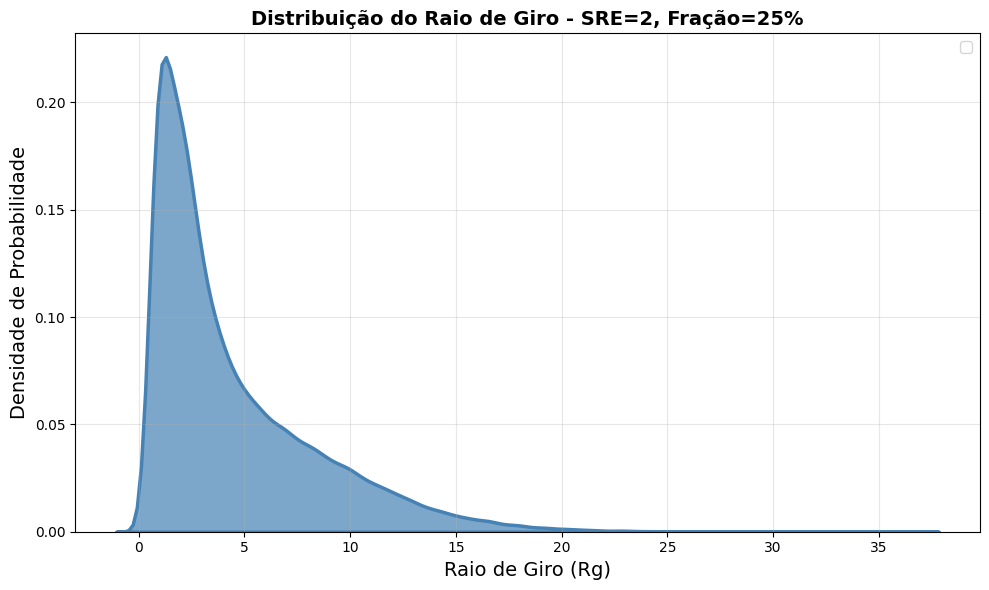

Gráfico salvo em: /media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data_processed/gyration_radius/frac_25/SRE_2/kde_distribuicao_Rg.png


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ============================================
# CONFIGURAÇÕES
# ============================================
output_base = "/media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data_processed/gyration_radius"

# Escolha o SRE e fração que quer analisar
sre_escolhido = 2
frac_escolhida = 25

# Caminho para os dados
data_path = Path(output_base) / f"frac_{frac_escolhida}" / f"SRE_{sre_escolhido}" / "all_particles.csv"

# ============================================
# CARREGAR DADOS
# ============================================
df = pd.read_csv(data_path)

print(f"SRE={sre_escolhido}, Fração={frac_escolhida}%")
print(f"Total de partículas: {len(df):,}")
print(f"Média do Rg: {df['Rg'].mean():.4f}")
print(f"Mediana do Rg: {df['Rg'].median():.4f}")
print()

# ============================================
# GRÁFICO KDE (Densidade de Probabilidade)
# ============================================
plt.figure(figsize=(10, 6))

# Plotar KDE
sns.kdeplot(df['Rg'], fill=True, color='steelblue', linewidth=2.5, alpha=0.7)

# Configurações do gráfico
plt.xlabel('Raio de Giro (Rg)', fontsize=14)
plt.ylabel('Densidade de Probabilidade', fontsize=14)
plt.title(f'Distribuição do Raio de Giro - SRE={sre_escolhido}, Fração={frac_escolhida}%', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Salvar o gráfico
output_plot = Path(output_base) / f"frac_{frac_escolhida}" / f"SRE_{sre_escolhido}" / 'kde_distribuicao_Rg.png'
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()

print(f"Gráfico salvo em: {output_plot}")

#### SR = 16

SRE=2, Fração=25%
Total de partículas: 163,800
Média do Rg: 4.4896
Mediana do Rg: 3.0523
Desvio padrão: 3.9059



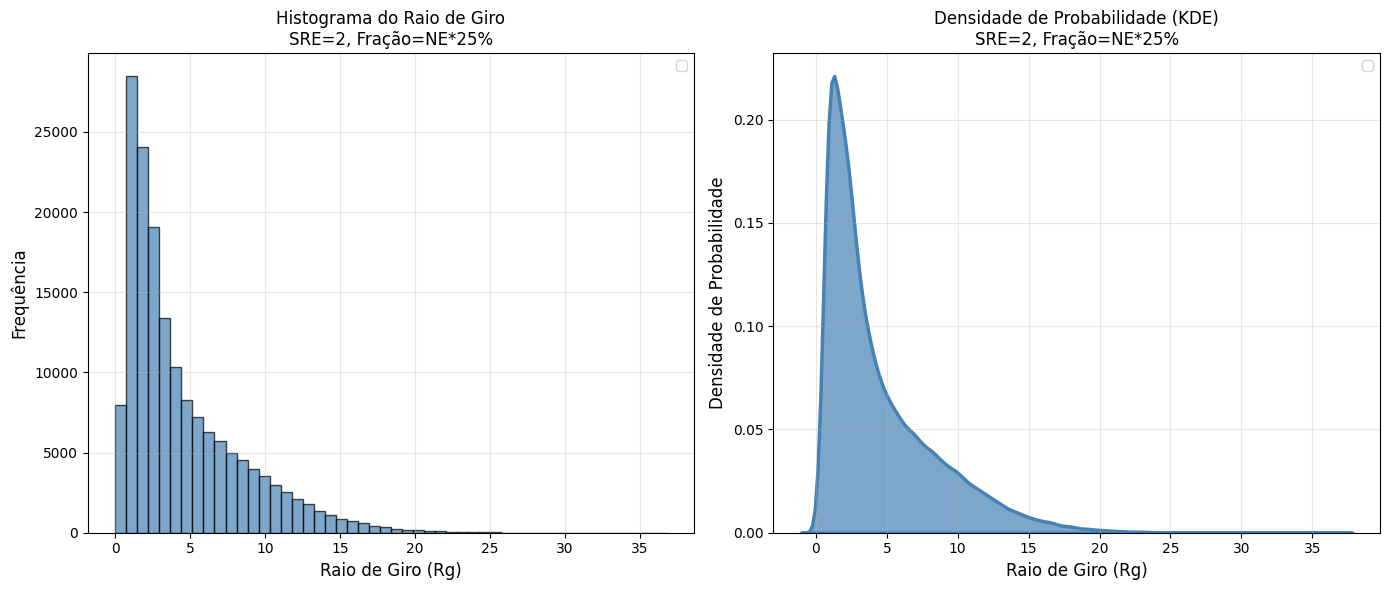

Gráfico salvo em: /media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data_processed/gyration_radius/frac_25/SRE_2/histograma_kde_Rg.png


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ============================================
# CONFIGURAÇÕES
# ============================================
output_base = "/media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data_processed/gyration_radius"

# Escolha o SRE e fração que quer analisar
sre_escolhido = 2
frac_escolhida = 25

# Caminho para os dados
data_path = Path(output_base) / f"frac_{frac_escolhida}" / f"SRE_{sre_escolhido}" / "all_particles.csv"

# ============================================
# CARREGAR DADOS
# ============================================
df = pd.read_csv(data_path)

print(f"SRE={sre_escolhido}, Fração={frac_escolhida}%")
print(f"Total de partículas: {len(df):,}")
print(f"Média do Rg: {df['Rg'].mean():.4f}")
print(f"Mediana do Rg: {df['Rg'].median():.4f}")
print(f"Desvio padrão: {df['Rg'].std():.4f}")
print()

# ============================================
# GRÁFICOS: HISTOGRAMA + KDE
# ============================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ========== GRÁFICO 1: HISTOGRAMA ==========
ax1.hist(df['Rg'], bins=50, edgecolor='black', color='steelblue', alpha=0.7, density=False)
ax1.set_xlabel('Raio de Giro (Rg)', fontsize=12)
ax1.set_ylabel('Frequência', fontsize=12)
ax1.set_title(f'Histograma do Raio de Giro\nSRE={sre_escolhido}, Fração=NE*{frac_escolhida}%', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# ========== GRÁFICO 2: KDE (Densidade) ==========
sns.kdeplot(df['Rg'], fill=True, color='steelblue', linewidth=2.5, alpha=0.7, ax=ax2)

ax2.set_xlabel('Raio de Giro (Rg)', fontsize=12)
ax2.set_ylabel('Densidade de Probabilidade', fontsize=12)
ax2.set_title(f'Densidade de Probabilidade (KDE)\nSRE={sre_escolhido}, Fração=NE*{frac_escolhida}%', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(Path(output_base) / f"frac_{frac_escolhida}" / f"SRE_{sre_escolhido}" / 'histograma_kde_Rg.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print(f"Gráfico salvo em: {Path(output_base) / f'frac_{frac_escolhida}' / f'SRE_{sre_escolhido}' / 'histograma_kde_Rg.png'}")

### NC = 0.50NE

SRE=2, Fração=50%
Total de partículas: 327,600
Média do Rg: 11.2661
Mediana do Rg: 11.1398
Desvio padrão: 5.4986



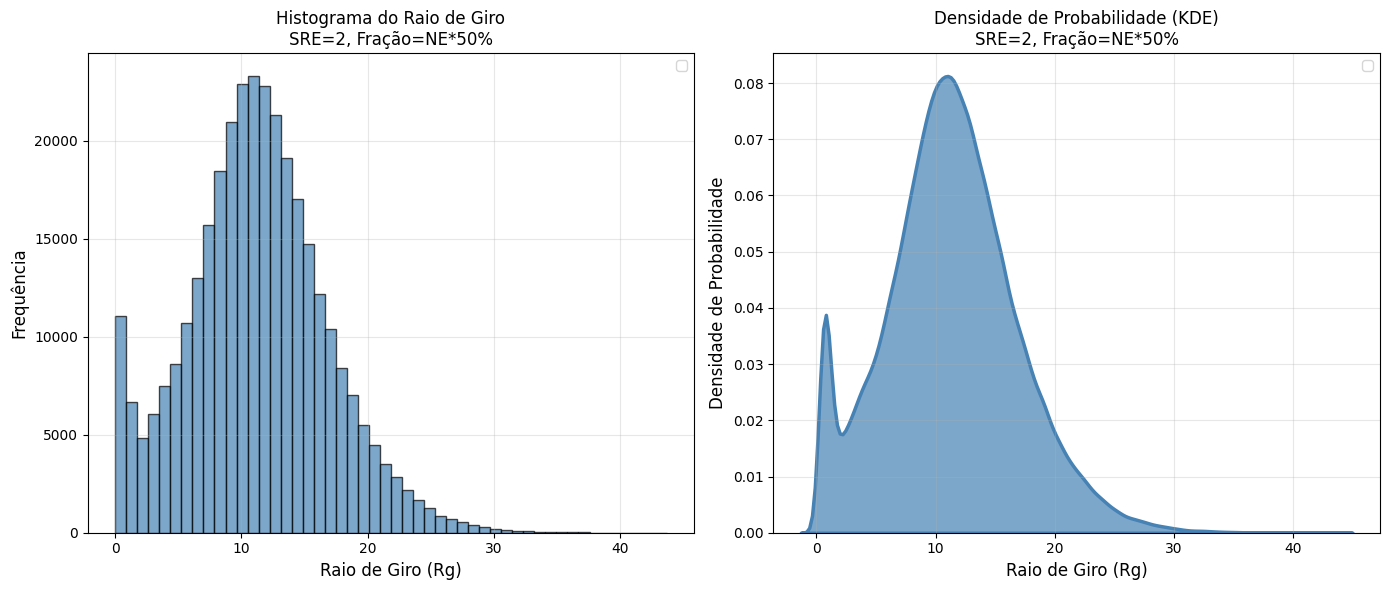

Gráfico salvo em: /media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data_processed/gyration_radius/frac_50/SRE_2/histograma_kde_Rg.png
SRE=16, Fração=50%
Total de partículas: 327,600
Média do Rg: 11.2477
Mediana do Rg: 11.1265



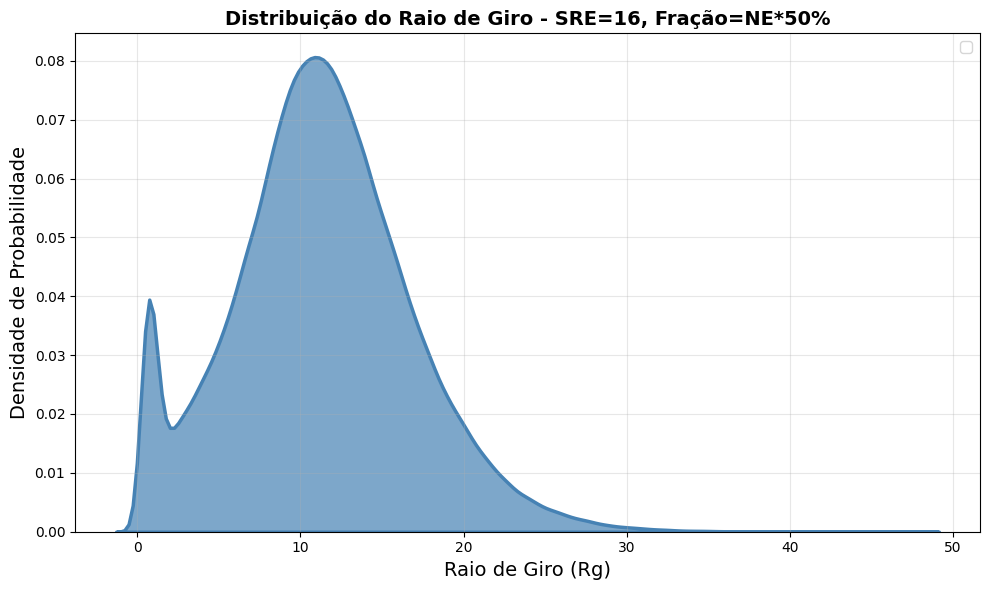

Gráfico salvo em: /media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data_processed/gyration_radius/frac_50/SRE_16/kde_distribuicao_Rg.png


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ============================================
# CONFIGURAÇÕESimport pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ============================================
# CONFIGURAÇÕES
# ============================================
output_base = "/media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data_processed/gyration_radius"

# Escolha o SRE e fração que quer analisar
sre_escolhido = 2
frac_escolhida = 50

# Caminho para os dados
data_path = Path(output_base) / f"frac_{frac_escolhida}" / f"SRE_{sre_escolhido}" / "all_particles.csv"

# ============================================
# CARREGAR DADOS
# ============================================
df = pd.read_csv(data_path)

print(f"SRE={sre_escolhido}, Fração={frac_escolhida}%")
print(f"Total de partículas: {len(df):,}")
print(f"Média do Rg: {df['Rg'].mean():.4f}")
print(f"Mediana do Rg: {df['Rg'].median():.4f}")
print(f"Desvio padrão: {df['Rg'].std():.4f}")
print()

# ============================================
# GRÁFICOS: HISTOGRAMA + KDE
# ============================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ========== GRÁFICO 1: HISTOGRAMA ==========
ax1.hist(df['Rg'], bins=50, edgecolor='black', color='steelblue', alpha=0.7, density=False)
ax1.set_xlabel('Raio de Giro (Rg)', fontsize=12)
ax1.set_ylabel('Frequência', fontsize=12)
ax1.set_title(f'Histograma do Raio de Giro\nSRE={sre_escolhido}, Fração=NE*{frac_escolhida}%', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# ========== GRÁFICO 2: KDE (Densidade) ==========
sns.kdeplot(df['Rg'], fill=True, color='steelblue', linewidth=2.5, alpha=0.7, ax=ax2)

ax2.set_xlabel('Raio de Giro (Rg)', fontsize=12)
ax2.set_ylabel('Densidade de Probabilidade', fontsize=12)
ax2.set_title(f'Densidade de Probabilidade (KDE)\nSRE={sre_escolhido}, Fração=NE*{frac_escolhida}%', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(Path(output_base) / f"frac_{frac_escolhida}" / f"SRE_{sre_escolhido}" / 'histograma_kde_Rg.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print(f"Gráfico salvo em: {Path(output_base) / f'frac_{frac_escolhida}' / f'SRE_{sre_escolhido}' / 'histograma_kde_Rg.png'}")
# ============================================
output_base = "/media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data_processed/gyration_radius"

# Escolha o SRE e fração que quer analisar
sre_escolhido = 16
frac_escolhida = 50

# Caminho para os dados
data_path = Path(output_base) / f"frac_{frac_escolhida}" / f"SRE_{sre_escolhido}" / "all_particles.csv"

# ============================================
# CARREGAR DADOS
# ============================================
df = pd.read_csv(data_path)

print(f"SRE={sre_escolhido}, Fração={frac_escolhida}%")
print(f"Total de partículas: {len(df):,}")
print(f"Média do Rg: {df['Rg'].mean():.4f}")
print(f"Mediana do Rg: {df['Rg'].median():.4f}")
print()

# ============================================
# GRÁFICO KDE (Densidade de Probabilidade)
# ============================================
plt.figure(figsize=(10, 6))

# Plotar KDE
sns.kdeplot(df['Rg'], fill=True, color='steelblue', linewidth=2.5, alpha=0.7)

# Configurações do gráfico
plt.xlabel('Raio de Giro (Rg)', fontsize=14)
plt.ylabel('Densidade de Probabilidade', fontsize=14)
plt.title(f'Distribuição do Raio de Giro - SRE={sre_escolhido}, Fração=NE*{frac_escolhida}%', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Salvar o gráfico
output_plot = Path(output_base) / f"frac_{frac_escolhida}" / f"SRE_{sre_escolhido}" / 'kde_distribuicao_Rg.png'
plt.savefig(output_plot, dpi=300, bbox_inches='tight')
plt.show()

print(f"Gráfico salvo em: {output_plot}")

SRE=2, Fração=100%
Total de partículas: 655,300
Média do Rg: 12.6356
Mediana do Rg: 12.0804
Desvio padrão: 4.0563



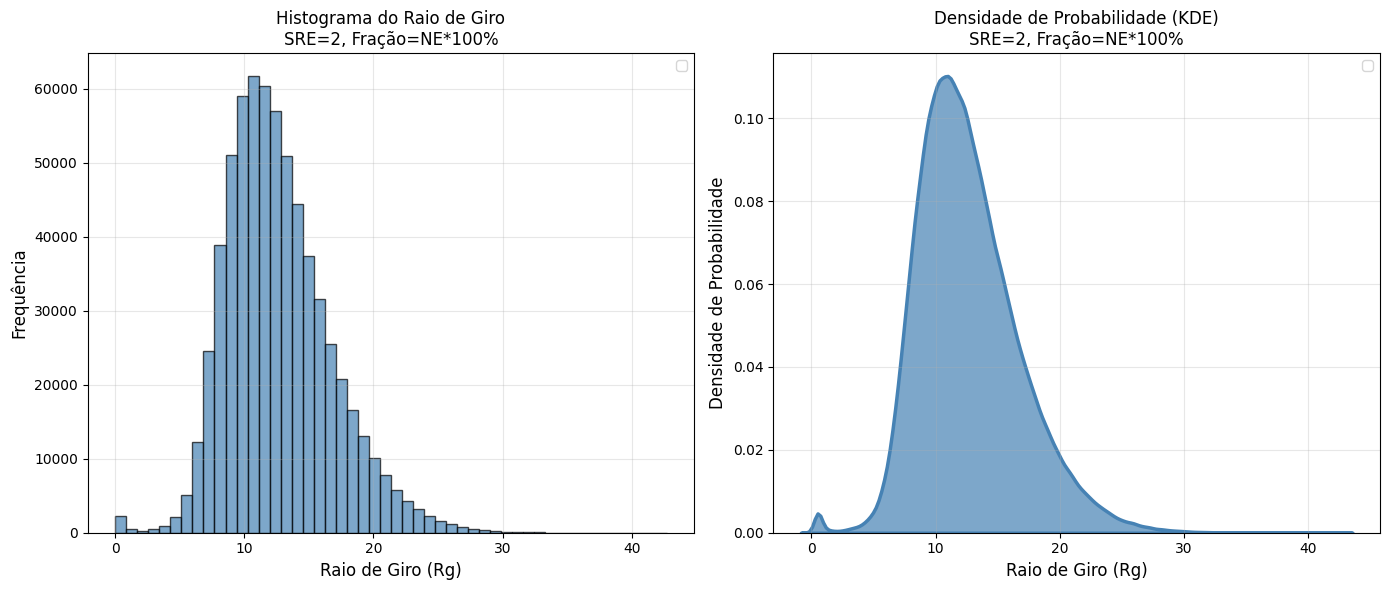

Gráfico salvo em: /media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data_processed/gyration_radius/frac_100/SRE_2/histograma_kde_Rg.png


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ============================================
# CONFIGURAÇÕES
# ============================================
output_base = "/media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data_processed/gyration_radius"

# Escolha o SRE e fração que quer analisar
sre_escolhido = 2
frac_escolhida = 100

# Caminho para os dados
data_path = Path(output_base) / f"frac_{frac_escolhida}" / f"SRE_{sre_escolhido}" / "all_particles.csv"

# ============================================
# CARREGAR DADOS
# ============================================
df = pd.read_csv(data_path)

print(f"SRE={sre_escolhido}, Fração={frac_escolhida}%")
print(f"Total de partículas: {len(df):,}")
print(f"Média do Rg: {df['Rg'].mean():.4f}")
print(f"Mediana do Rg: {df['Rg'].median():.4f}")
print(f"Desvio padrão: {df['Rg'].std():.4f}")
print()

# ============================================
# GRÁFICOS: HISTOGRAMA + KDE
# ============================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ========== GRÁFICO 1: HISTOGRAMA ==========
ax1.hist(df['Rg'], bins=50, edgecolor='black', color='steelblue', alpha=0.7, density=False)
ax1.set_xlabel('Raio de Giro (Rg)', fontsize=12)
ax1.set_ylabel('Frequência', fontsize=12)
ax1.set_title(f'Histograma do Raio de Giro\nSRE={sre_escolhido}, Fração=NE*{frac_escolhida}%', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# ========== GRÁFICO 2: KDE (Densidade) ==========
sns.kdeplot(df['Rg'], fill=True, color='steelblue', linewidth=2.5, alpha=0.7, ax=ax2)

ax2.set_xlabel('Raio de Giro (Rg)', fontsize=12)
ax2.set_ylabel('Densidade de Probabilidade', fontsize=12)
ax2.set_title(f'Densidade de Probabilidade (KDE)\nSRE={sre_escolhido}, Fração=NE*{frac_escolhida}%', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(Path(output_base) / f"frac_{frac_escolhida}" / f"SRE_{sre_escolhido}" / 'histograma_kde_Rg.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print(f"Gráfico salvo em: {Path(output_base) / f'frac_{frac_escolhida}' / f'SRE_{sre_escolhido}' / 'histograma_kde_Rg.png'}")

# Teste Fit poison

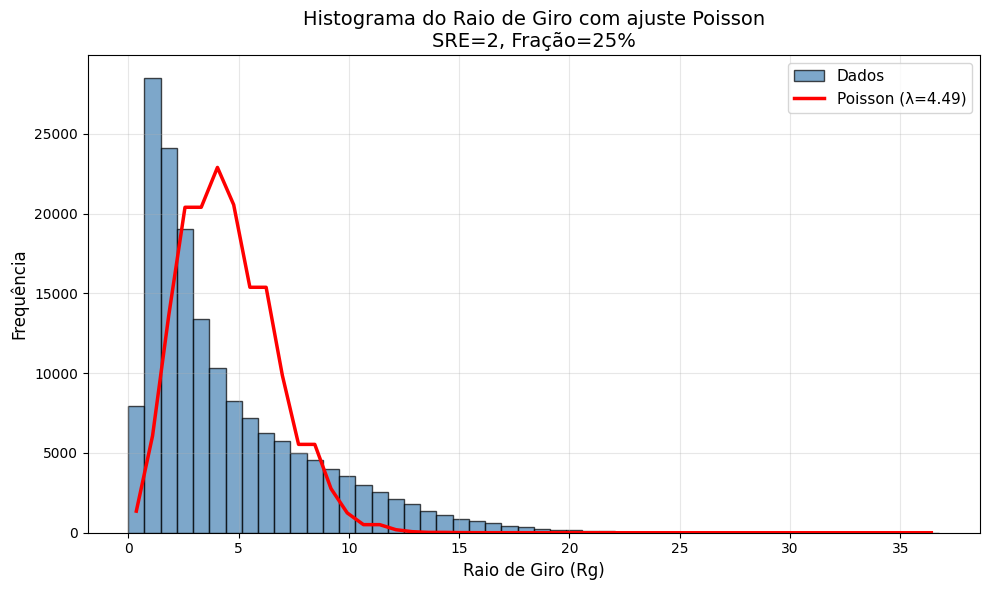

λ (Poisson): 4.4896
Média dos dados: 4.4896


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

# Configurações
output_base = "/media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data_processed/gyration_radius"
sre = 2
frac = 25

# Carregar dados
df = pd.read_csv(Path(output_base) / f"frac_{frac}" / f"SRE_{sre}" / "all_particles.csv")
rg_values = df['Rg'].values

# Criar histograma
n_bins = 50
counts, bin_edges = np.histogram(rg_values, bins=n_bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Ajustar Poisson (multiplicar para ter inteiros)
fator = 1
bin_centers_int = np.round(bin_centers * fator).astype(int)
lambda_poisson = np.mean(rg_values * fator)
poisson_counts = stats.poisson.pmf(bin_centers_int, lambda_poisson) * len(rg_values) * (bin_edges[1] - bin_edges[0]) * fator

# Plot
plt.figure(figsize=(10, 6))
plt.hist(rg_values, bins=n_bins, alpha=0.7, color='steelblue', edgecolor='black', label='Dados')
plt.plot(bin_centers, poisson_counts, 'r-', linewidth=2.5, label=f'Poisson (λ={lambda_poisson/fator:.2f})')
plt.xlabel('Raio de Giro (Rg)', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.title(f'Histograma do Raio de Giro com ajuste Poisson\nSRE={sre}, Fração={frac}%', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"λ (Poisson): {lambda_poisson/fator:.4f}")
print(f"Média dos dados: {np.mean(rg_values):.4f}")

SRE=16, Fração=25%
Total de partículas: 163,800
Média: 4.5267
Mediana: 3.0725
Desvio: 3.9412



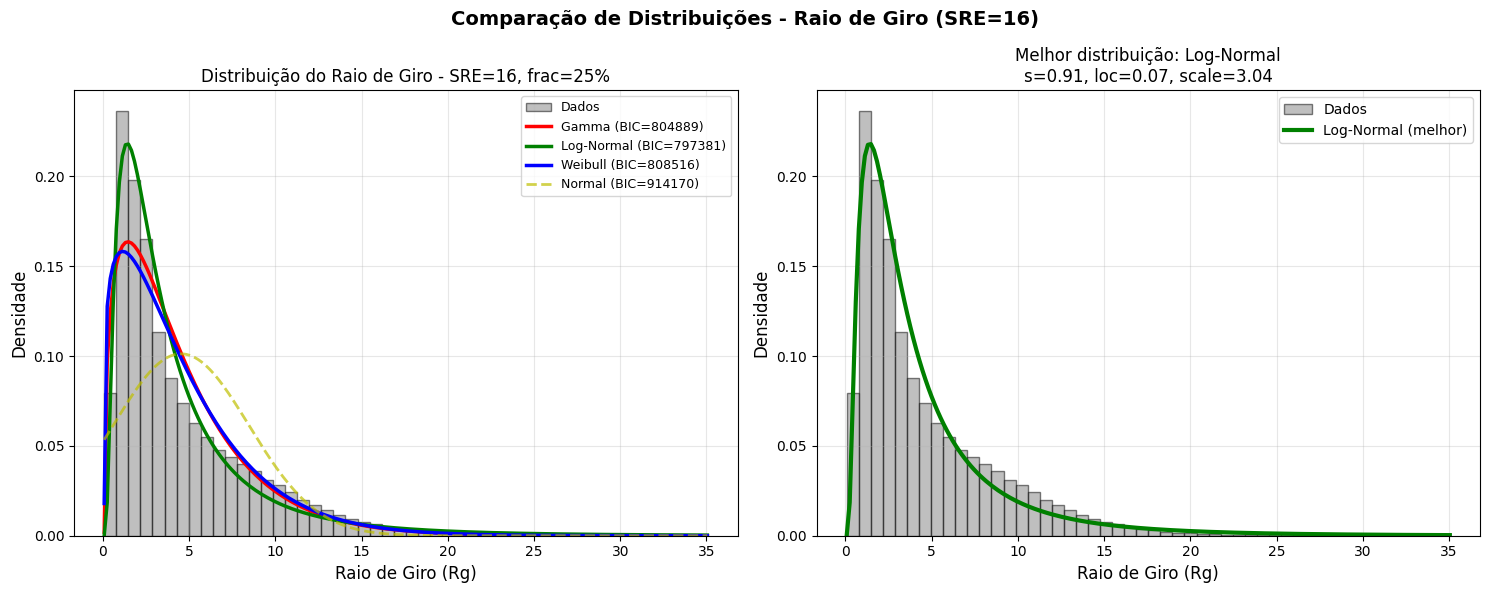

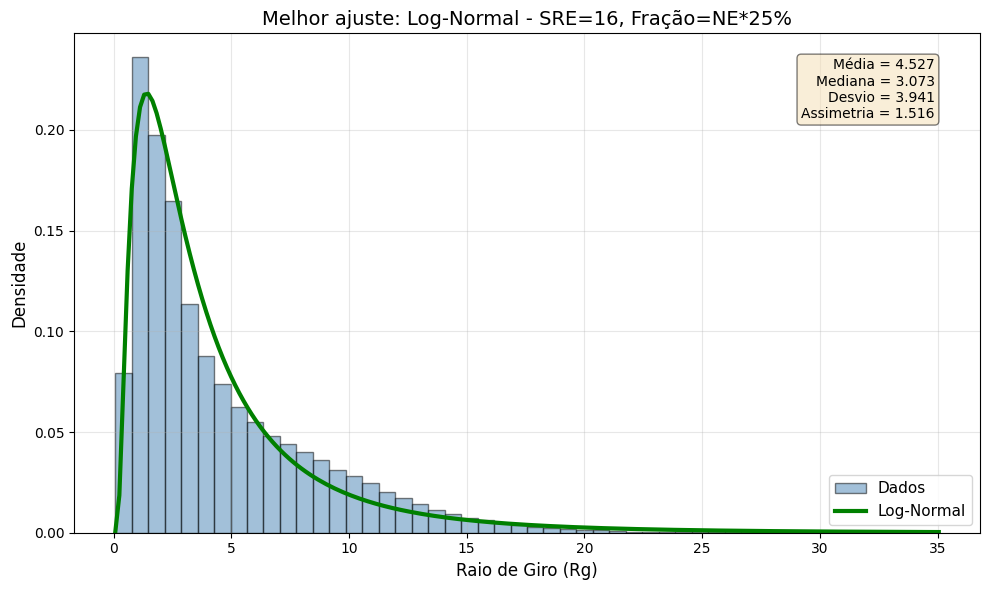

COMPARAÇÃO DOS AJUSTES (BIC - menor é melhor)
Log-Normal  : BIC = 797381.05
Gamma       : BIC = 804889.32
Weibull     : BIC = 808515.73
Normal      : BIC = 914170.26

✅ Melhor distribuição: Log-Normal

TESTE DE KOLMOGOROV-SMIRNOV
KS estatística: 0.0405
p-valor: 5.8409e-234
⚠️ A distribuição não se ajusta perfeitamente (p < 0.05)


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

# ============================================
# CONFIGURAÇÕES
# ============================================
output_base = "/media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data_processed/gyration_radius"
sre = 16
frac = 25

# Carregar dados
df = pd.read_csv(Path(output_base) / f"frac_{frac}" / f"SRE_{sre}" / "all_particles.csv")
rg_values = df['Rg'].values

print(f"SRE={sre}, Fração={frac}%")
print(f"Total de partículas: {len(rg_values):,}")
print(f"Média: {rg_values.mean():.4f}")
print(f"Mediana: {np.median(rg_values):.4f}")
print(f"Desvio: {rg_values.std():.4f}")
print()

# ============================================
# AJUSTE DE DISTRIBUIÇÕES
# ============================================
x = np.linspace(rg_values.min(), rg_values.max(), 200)

# 1. Gamma
gamma_params = stats.gamma.fit(rg_values)
gamma_pdf = stats.gamma.pdf(x, *gamma_params)

# 2. Log-Normal
lognorm_params = stats.lognorm.fit(rg_values)
lognorm_pdf = stats.lognorm.pdf(x, *lognorm_params)

# 3. Weibull
weibull_params = stats.weibull_min.fit(rg_values)
weibull_pdf = stats.weibull_min.pdf(x, *weibull_params)

# 4. Normal (para comparação)
norm_params = stats.norm.fit(rg_values)
norm_pdf = stats.norm.pdf(x, *norm_params)

# ============================================
# CALCULAR BIC (para comparar os fits)
# ============================================
def calculate_bic(data, dist, params):
    """Calcula o BIC para um dado ajuste"""
    log_likelihood = np.sum(dist.logpdf(data, *params))
    n_params = len(params)
    bic = -2 * log_likelihood + n_params * np.log(len(data))
    return bic

bic_values = {}
bic_values['Gamma'] = calculate_bic(rg_values, stats.gamma, gamma_params)
bic_values['Log-Normal'] = calculate_bic(rg_values, stats.lognorm, lognorm_params)
bic_values['Weibull'] = calculate_bic(rg_values, stats.weibull_min, weibull_params)
bic_values['Normal'] = calculate_bic(rg_values, stats.norm, norm_params)

# Melhor distribuição (menor BIC)
best_dist = min(bic_values, key=bic_values.get)

# ============================================
# GRÁFICO 1: HISTOGRAMA + FITS
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Histograma com fits
ax1 = axes[0]
ax1.hist(rg_values, bins=50, density=True, alpha=0.5, color='gray', edgecolor='black', label='Dados')
ax1.plot(x, gamma_pdf, 'r-', linewidth=2.5, label=f'Gamma (BIC={bic_values["Gamma"]:.0f})')
ax1.plot(x, lognorm_pdf, 'g-', linewidth=2.5, label=f'Log-Normal (BIC={bic_values["Log-Normal"]:.0f})')
ax1.plot(x, weibull_pdf, 'b-', linewidth=2.5, label=f'Weibull (BIC={bic_values["Weibull"]:.0f})')
ax1.plot(x, norm_pdf, 'y--', linewidth=2, alpha=0.7, label=f'Normal (BIC={bic_values["Normal"]:.0f})')
ax1.set_xlabel('Raio de Giro (Rg)', fontsize=12)
ax1.set_ylabel('Densidade', fontsize=12)
ax1.set_title(f'Distribuição do Raio de Giro - SRE={sre}, frac={frac}%', fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Gráfico 2: Apenas a melhor distribuição
ax2 = axes[1]
ax2.hist(rg_values, bins=50, density=True, alpha=0.5, color='gray', edgecolor='black', label='Dados')

if best_dist == 'Gamma':
    ax2.plot(x, gamma_pdf, 'r-', linewidth=3, label=f'Gamma (melhor)')
    params_text = f'k={gamma_params[0]:.2f}, θ={gamma_params[2]:.2f}'
elif best_dist == 'Log-Normal':
    ax2.plot(x, lognorm_pdf, 'g-', linewidth=3, label=f'Log-Normal (melhor)')
    params_text = f's={lognorm_params[0]:.2f}, loc={lognorm_params[1]:.2f}, scale={lognorm_params[2]:.2f}'
elif best_dist == 'Weibull':
    ax2.plot(x, weibull_pdf, 'b-', linewidth=3, label=f'Weibull (melhor)')
    params_text = f'c={weibull_params[0]:.2f}, loc={weibull_params[1]:.2f}, scale={weibull_params[2]:.2f}'
else:
    ax2.plot(x, norm_pdf, 'y-', linewidth=3, label=f'Normal (melhor)')
    params_text = f'μ={norm_params[0]:.2f}, σ={norm_params[1]:.2f}'

ax2.set_xlabel('Raio de Giro (Rg)', fontsize=12)
ax2.set_ylabel('Densidade', fontsize=12)
ax2.set_title(f'Melhor distribuição: {best_dist}\n{params_text}', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle(f'Comparação de Distribuições - Raio de Giro (SRE={sre})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(Path(output_base) / f"frac_{frac}" / f"SRE_{sre}" / 'fit_distribuicoes.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# GRÁFICO 2: APENAS A MELHOR DISTRIBUIÇÃO (MAIS DETALHADO)
# ============================================
fig, ax = plt.subplots(figsize=(10, 6))

# Histograma
ax.hist(rg_values, bins=50, density=True, alpha=0.5, color='steelblue', edgecolor='black', label='Dados')

# Melhor fit
if best_dist == 'Gamma':
    ax.plot(x, gamma_pdf, 'r-', linewidth=3, label=f'Gamma')
    # Adicionar intervalo de confiança (opcional)
    ci_low, ci_high = np.percentile(rg_values, [2.5, 97.5])
    ax.axvline(ci_low, color='gray', linestyle=':', alpha=0.7)
    ax.axvline(ci_high, color='gray', linestyle=':', alpha=0.7)
elif best_dist == 'Log-Normal':
    ax.plot(x, lognorm_pdf, 'g-', linewidth=3, label=f'Log-Normal')
elif best_dist == 'Weibull':
    ax.plot(x, weibull_pdf, 'b-', linewidth=3, label=f'Weibull')
else:
    ax.plot(x, norm_pdf, 'y-', linewidth=3, label=f'Normal')

# Estatísticas no gráfico
stats_text = f'Média = {rg_values.mean():.3f}\n'
stats_text += f'Mediana = {np.median(rg_values):.3f}\n'
stats_text += f'Desvio = {rg_values.std():.3f}\n'
stats_text += f'Assimetria = {stats.skew(rg_values):.3f}'

ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, 
        fontsize=10, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('Raio de Giro (Rg)', fontsize=12)
ax.set_ylabel('Densidade', fontsize=12)
ax.set_title(f'Melhor ajuste: {best_dist} - SRE={sre}, Fração=NE*{frac}%', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(Path(output_base) / f"frac_{frac}" / f"SRE_{sre}" / f'melhor_fit_{best_dist}.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# RESULTADOS
# ============================================
print("="*60)
print("COMPARAÇÃO DOS AJUSTES (BIC - menor é melhor)")
print("="*60)
for dist, bic in sorted(bic_values.items(), key=lambda x: x[1]):
    print(f"{dist:12s}: BIC = {bic:.2f}")
print(f"\n✅ Melhor distribuição: {best_dist}")
print("="*60)

# ============================================
# TESTE DE KOLMOGOROV-SMIRNOV
# ============================================
print("\n" + "="*60)
print("TESTE DE KOLMOGOROV-SMIRNOV")
print("="*60)

if best_dist == 'Gamma':
    ks_stat, ks_p = stats.kstest(rg_values, 'gamma', args=gamma_params)
elif best_dist == 'Log-Normal':
    ks_stat, ks_p = stats.kstest(rg_values, 'lognorm', args=lognorm_params)
elif best_dist == 'Weibull':
    ks_stat, ks_p = stats.kstest(rg_values, 'weibull_min', args=weibull_params)
else:
    ks_stat, ks_p = stats.kstest(rg_values, 'norm', args=norm_params)

print(f"KS estatística: {ks_stat:.4f}")
print(f"p-valor: {ks_p:.4e}")
if ks_p > 0.05:
    print("✅ A distribuição se ajusta bem aos dados (p > 0.05)")
else:
    print("⚠️ A distribuição não se ajusta perfeitamente (p < 0.05)")
print("="*60)

SRE=2, Fração=50%
Total de partículas: 327,600
Média: 11.2661
Mediana: 11.1398
Desvio: 5.4986



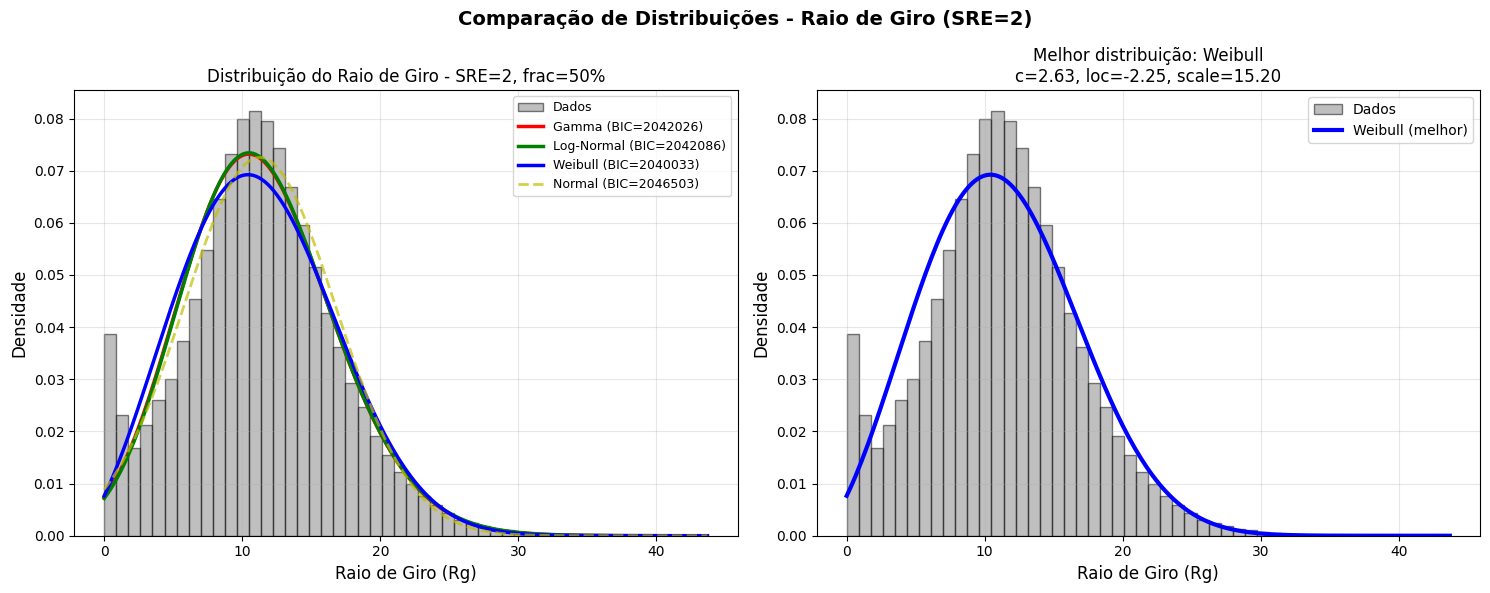

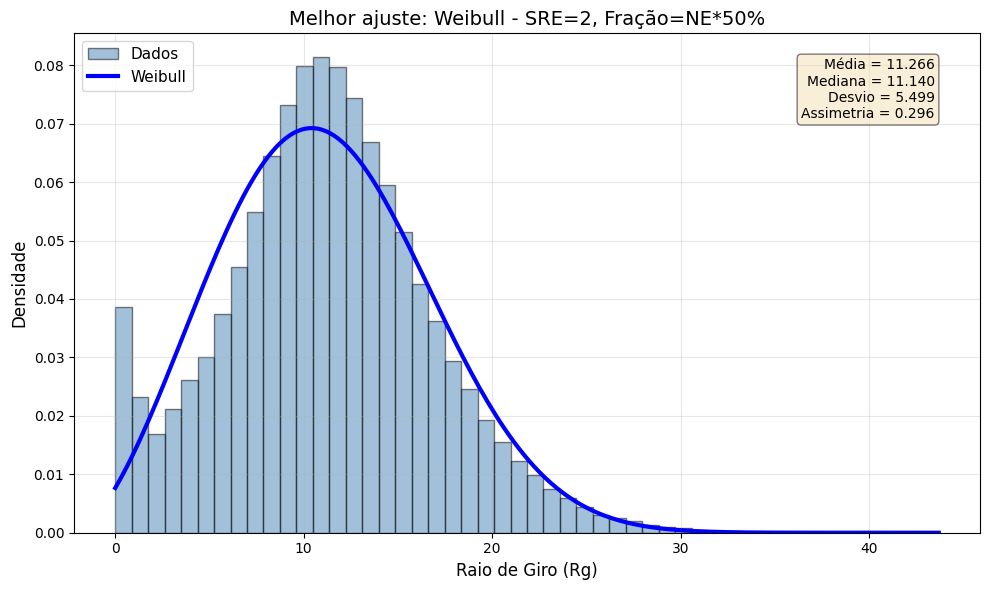

COMPARAÇÃO DOS AJUSTES (BIC - menor é melhor)
Weibull     : BIC = 2040033.44
Gamma       : BIC = 2042025.56
Log-Normal  : BIC = 2042085.97
Normal      : BIC = 2046502.55

✅ Melhor distribuição: Weibull

TESTE DE KOLMOGOROV-SMIRNOV
KS estatística: 0.0347
p-valor: 0.0000e+00
⚠️ A distribuição não se ajusta perfeitamente (p < 0.05)


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

# ============================================
# CONFIGURAÇÕES
# ============================================
output_base = "/media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data_processed/gyration_radius"
sre = 2
frac = 50

# Carregar dados
df = pd.read_csv(Path(output_base) / f"frac_{frac}" / f"SRE_{sre}" / "all_particles.csv")
rg_values = df['Rg'].values

print(f"SRE={sre}, Fração={frac}%")
print(f"Total de partículas: {len(rg_values):,}")
print(f"Média: {rg_values.mean():.4f}")
print(f"Mediana: {np.median(rg_values):.4f}")
print(f"Desvio: {rg_values.std():.4f}")
print()

# ============================================
# AJUSTE DE DISTRIBUIÇÕES
# ============================================
x = np.linspace(rg_values.min(), rg_values.max(), 200)

# 1. Gamma
gamma_params = stats.gamma.fit(rg_values)
gamma_pdf = stats.gamma.pdf(x, *gamma_params)

# 2. Log-Normal
lognorm_params = stats.lognorm.fit(rg_values)
lognorm_pdf = stats.lognorm.pdf(x, *lognorm_params)

# 3. Weibull
weibull_params = stats.weibull_min.fit(rg_values)
weibull_pdf = stats.weibull_min.pdf(x, *weibull_params)

# 4. Normal (para comparação)
norm_params = stats.norm.fit(rg_values)
norm_pdf = stats.norm.pdf(x, *norm_params)

# ============================================
# CALCULAR BIC (para comparar os fits)
# ============================================
def calculate_bic(data, dist, params):
    """Calcula o BIC para um dado ajuste"""
    log_likelihood = np.sum(dist.logpdf(data, *params))
    n_params = len(params)
    bic = -2 * log_likelihood + n_params * np.log(len(data))
    return bic

bic_values = {}
bic_values['Gamma'] = calculate_bic(rg_values, stats.gamma, gamma_params)
bic_values['Log-Normal'] = calculate_bic(rg_values, stats.lognorm, lognorm_params)
bic_values['Weibull'] = calculate_bic(rg_values, stats.weibull_min, weibull_params)
bic_values['Normal'] = calculate_bic(rg_values, stats.norm, norm_params)

# Melhor distribuição (menor BIC)
best_dist = min(bic_values, key=bic_values.get)

# ============================================
# GRÁFICO 1: HISTOGRAMA + FITS
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Histograma com fits
ax1 = axes[0]
ax1.hist(rg_values, bins=50, density=True, alpha=0.5, color='gray', edgecolor='black', label='Dados')
ax1.plot(x, gamma_pdf, 'r-', linewidth=2.5, label=f'Gamma (BIC={bic_values["Gamma"]:.0f})')
ax1.plot(x, lognorm_pdf, 'g-', linewidth=2.5, label=f'Log-Normal (BIC={bic_values["Log-Normal"]:.0f})')
ax1.plot(x, weibull_pdf, 'b-', linewidth=2.5, label=f'Weibull (BIC={bic_values["Weibull"]:.0f})')
ax1.plot(x, norm_pdf, 'y--', linewidth=2, alpha=0.7, label=f'Normal (BIC={bic_values["Normal"]:.0f})')
ax1.set_xlabel('Raio de Giro (Rg)', fontsize=12)
ax1.set_ylabel('Densidade', fontsize=12)
ax1.set_title(f'Distribuição do Raio de Giro - SRE={sre}, frac={frac}%', fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Gráfico 2: Apenas a melhor distribuição
ax2 = axes[1]
ax2.hist(rg_values, bins=50, density=True, alpha=0.5, color='gray', edgecolor='black', label='Dados')

if best_dist == 'Gamma':
    ax2.plot(x, gamma_pdf, 'r-', linewidth=3, label=f'Gamma (melhor)')
    params_text = f'k={gamma_params[0]:.2f}, θ={gamma_params[2]:.2f}'
elif best_dist == 'Log-Normal':
    ax2.plot(x, lognorm_pdf, 'g-', linewidth=3, label=f'Log-Normal (melhor)')
    params_text = f's={lognorm_params[0]:.2f}, loc={lognorm_params[1]:.2f}, scale={lognorm_params[2]:.2f}'
elif best_dist == 'Weibull':
    ax2.plot(x, weibull_pdf, 'b-', linewidth=3, label=f'Weibull (melhor)')
    params_text = f'c={weibull_params[0]:.2f}, loc={weibull_params[1]:.2f}, scale={weibull_params[2]:.2f}'
else:
    ax2.plot(x, norm_pdf, 'y-', linewidth=3, label=f'Normal (melhor)')
    params_text = f'μ={norm_params[0]:.2f}, σ={norm_params[1]:.2f}'

ax2.set_xlabel('Raio de Giro (Rg)', fontsize=12)
ax2.set_ylabel('Densidade', fontsize=12)
ax2.set_title(f'Melhor distribuição: {best_dist}\n{params_text}', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle(f'Comparação de Distribuições - Raio de Giro (SRE={sre})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(Path(output_base) / f"frac_{frac}" / f"SRE_{sre}" / 'fit_distribuicoes.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# GRÁFICO 2: APENAS A MELHOR DISTRIBUIÇÃO (MAIS DETALHADO)
# ============================================
fig, ax = plt.subplots(figsize=(10, 6))

# Histograma
ax.hist(rg_values, bins=50, density=True, alpha=0.5, color='steelblue', edgecolor='black', label='Dados')

# Melhor fit
if best_dist == 'Gamma':
    ax.plot(x, gamma_pdf, 'r-', linewidth=3, label=f'Gamma')
    # Adicionar intervalo de confiança (opcional)
    ci_low, ci_high = np.percentile(rg_values, [2.5, 97.5])
    ax.axvline(ci_low, color='gray', linestyle=':', alpha=0.7)
    ax.axvline(ci_high, color='gray', linestyle=':', alpha=0.7)
elif best_dist == 'Log-Normal':
    ax.plot(x, lognorm_pdf, 'g-', linewidth=3, label=f'Log-Normal')
elif best_dist == 'Weibull':
    ax.plot(x, weibull_pdf, 'b-', linewidth=3, label=f'Weibull')
else:
    ax.plot(x, norm_pdf, 'y-', linewidth=3, label=f'Normal')

# Estatísticas no gráfico
stats_text = f'Média = {rg_values.mean():.3f}\n'
stats_text += f'Mediana = {np.median(rg_values):.3f}\n'
stats_text += f'Desvio = {rg_values.std():.3f}\n'
stats_text += f'Assimetria = {stats.skew(rg_values):.3f}'

ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, 
        fontsize=10, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('Raio de Giro (Rg)', fontsize=12)
ax.set_ylabel('Densidade', fontsize=12)
ax.set_title(f'Melhor ajuste: {best_dist} - SRE={sre}, Fração=NE*{frac}%', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(Path(output_base) / f"frac_{frac}" / f"SRE_{sre}" / f'melhor_fit_{best_dist}.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# RESULTADOS
# ============================================
print("="*60)
print("COMPARAÇÃO DOS AJUSTES (BIC - menor é melhor)")
print("="*60)
for dist, bic in sorted(bic_values.items(), key=lambda x: x[1]):
    print(f"{dist:12s}: BIC = {bic:.2f}")
print(f"\n✅ Melhor distribuição: {best_dist}")
print("="*60)

# ============================================
# TESTE DE KOLMOGOROV-SMIRNOV
# ============================================
print("\n" + "="*60)
print("TESTE DE KOLMOGOROV-SMIRNOV")
print("="*60)

if best_dist == 'Gamma':
    ks_stat, ks_p = stats.kstest(rg_values, 'gamma', args=gamma_params)
elif best_dist == 'Log-Normal':
    ks_stat, ks_p = stats.kstest(rg_values, 'lognorm', args=lognorm_params)
elif best_dist == 'Weibull':
    ks_stat, ks_p = stats.kstest(rg_values, 'weibull_min', args=weibull_params)
else:
    ks_stat, ks_p = stats.kstest(rg_values, 'norm', args=norm_params)

print(f"KS estatística: {ks_stat:.4f}")
print(f"p-valor: {ks_p:.4e}")
if ks_p > 0.05:
    print("✅ A distribuição se ajusta bem aos dados (p > 0.05)")
else:
    print("⚠️ A distribuição não se ajusta perfeitamente (p < 0.05)")
print("="*60)

SRE=2, Fração=100%
Total de partículas: 655,300
Média: 12.6356
Mediana: 12.0804
Desvio: 4.0563



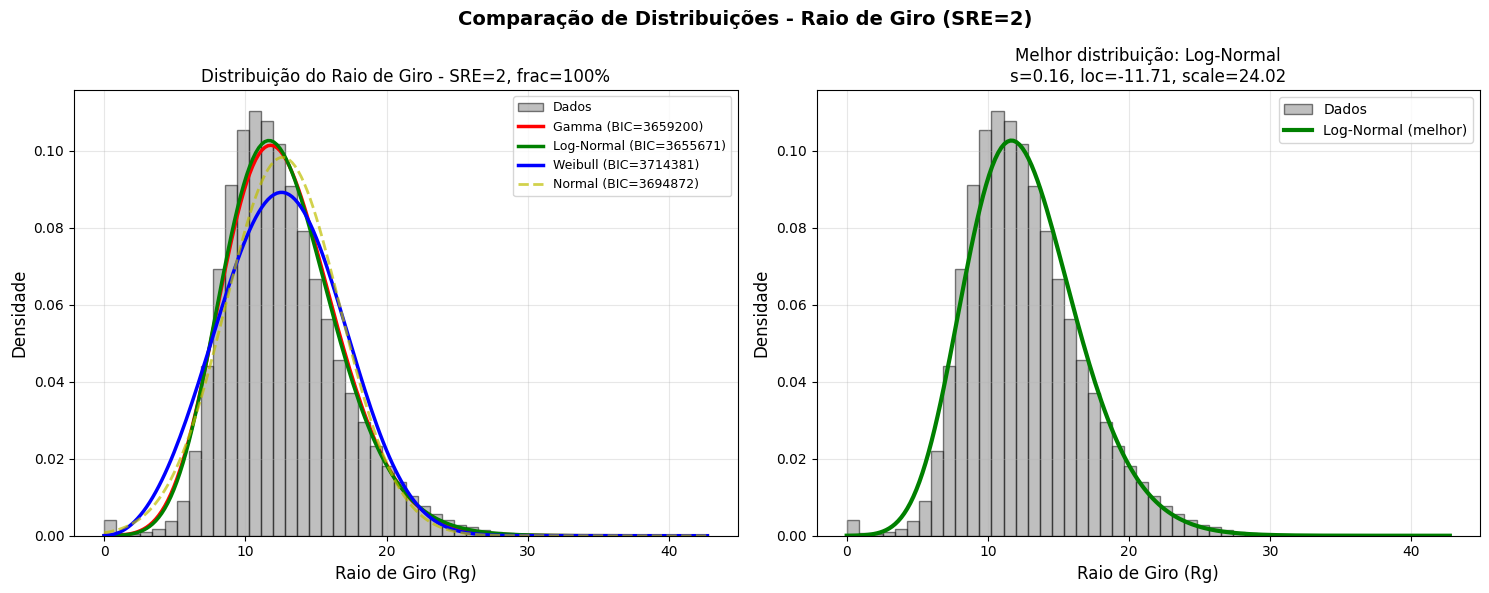

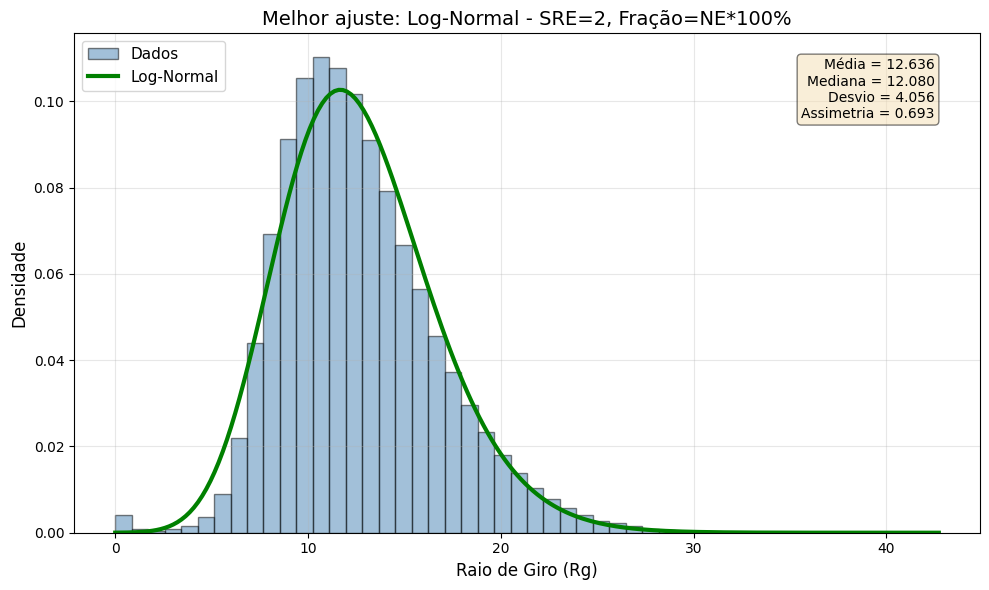

COMPARAÇÃO DOS AJUSTES (BIC - menor é melhor)
Log-Normal  : BIC = 3655671.46
Gamma       : BIC = 3659200.39
Normal      : BIC = 3694872.00
Weibull     : BIC = 3714381.09

✅ Melhor distribuição: Log-Normal

TESTE DE KOLMOGOROV-SMIRNOV
KS estatística: 0.0243
p-valor: 0.0000e+00
⚠️ A distribuição não se ajusta perfeitamente (p < 0.05)


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

# ============================================
# CONFIGURAÇÕES
# ============================================
output_base = "/media/camafeu/data/rossatto/Chase-escape_with_temporary_obstacles_data/data_processed/gyration_radius"
sre = 2
frac = 100

# Carregar dados
df = pd.read_csv(Path(output_base) / f"frac_{frac}" / f"SRE_{sre}" / "all_particles.csv")
rg_values = df['Rg'].values

print(f"SRE={sre}, Fração={frac}%")
print(f"Total de partículas: {len(rg_values):,}")
print(f"Média: {rg_values.mean():.4f}")
print(f"Mediana: {np.median(rg_values):.4f}")
print(f"Desvio: {rg_values.std():.4f}")
print()

# ============================================
# AJUSTE DE DISTRIBUIÇÕES
# ============================================
x = np.linspace(rg_values.min(), rg_values.max(), 200)

# 1. Gamma
gamma_params = stats.gamma.fit(rg_values)
gamma_pdf = stats.gamma.pdf(x, *gamma_params)

# 2. Log-Normal
lognorm_params = stats.lognorm.fit(rg_values)
lognorm_pdf = stats.lognorm.pdf(x, *lognorm_params)

# 3. Weibull
weibull_params = stats.weibull_min.fit(rg_values)
weibull_pdf = stats.weibull_min.pdf(x, *weibull_params)

# 4. Normal (para comparação)
norm_params = stats.norm.fit(rg_values)
norm_pdf = stats.norm.pdf(x, *norm_params)

# ============================================
# CALCULAR BIC (para comparar os fits)
# ============================================
def calculate_bic(data, dist, params):
    """Calcula o BIC para um dado ajuste"""
    log_likelihood = np.sum(dist.logpdf(data, *params))
    n_params = len(params)
    bic = -2 * log_likelihood + n_params * np.log(len(data))
    return bic

bic_values = {}
bic_values['Gamma'] = calculate_bic(rg_values, stats.gamma, gamma_params)
bic_values['Log-Normal'] = calculate_bic(rg_values, stats.lognorm, lognorm_params)
bic_values['Weibull'] = calculate_bic(rg_values, stats.weibull_min, weibull_params)
bic_values['Normal'] = calculate_bic(rg_values, stats.norm, norm_params)

# Melhor distribuição (menor BIC)
best_dist = min(bic_values, key=bic_values.get)

# ============================================
# GRÁFICO 1: HISTOGRAMA + FITS
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Histograma com fits
ax1 = axes[0]
ax1.hist(rg_values, bins=50, density=True, alpha=0.5, color='gray', edgecolor='black', label='Dados')
ax1.plot(x, gamma_pdf, 'r-', linewidth=2.5, label=f'Gamma (BIC={bic_values["Gamma"]:.0f})')
ax1.plot(x, lognorm_pdf, 'g-', linewidth=2.5, label=f'Log-Normal (BIC={bic_values["Log-Normal"]:.0f})')
ax1.plot(x, weibull_pdf, 'b-', linewidth=2.5, label=f'Weibull (BIC={bic_values["Weibull"]:.0f})')
ax1.plot(x, norm_pdf, 'y--', linewidth=2, alpha=0.7, label=f'Normal (BIC={bic_values["Normal"]:.0f})')
ax1.set_xlabel('Raio de Giro (Rg)', fontsize=12)
ax1.set_ylabel('Densidade', fontsize=12)
ax1.set_title(f'Distribuição do Raio de Giro - SRE={sre}, frac={frac}%', fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Gráfico 2: Apenas a melhor distribuição
ax2 = axes[1]
ax2.hist(rg_values, bins=50, density=True, alpha=0.5, color='gray', edgecolor='black', label='Dados')

if best_dist == 'Gamma':
    ax2.plot(x, gamma_pdf, 'r-', linewidth=3, label=f'Gamma (melhor)')
    params_text = f'k={gamma_params[0]:.2f}, θ={gamma_params[2]:.2f}'
elif best_dist == 'Log-Normal':
    ax2.plot(x, lognorm_pdf, 'g-', linewidth=3, label=f'Log-Normal (melhor)')
    params_text = f's={lognorm_params[0]:.2f}, loc={lognorm_params[1]:.2f}, scale={lognorm_params[2]:.2f}'
elif best_dist == 'Weibull':
    ax2.plot(x, weibull_pdf, 'b-', linewidth=3, label=f'Weibull (melhor)')
    params_text = f'c={weibull_params[0]:.2f}, loc={weibull_params[1]:.2f}, scale={weibull_params[2]:.2f}'
else:
    ax2.plot(x, norm_pdf, 'y-', linewidth=3, label=f'Normal (melhor)')
    params_text = f'μ={norm_params[0]:.2f}, σ={norm_params[1]:.2f}'

ax2.set_xlabel('Raio de Giro (Rg)', fontsize=12)
ax2.set_ylabel('Densidade', fontsize=12)
ax2.set_title(f'Melhor distribuição: {best_dist}\n{params_text}', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.suptitle(f'Comparação de Distribuições - Raio de Giro (SRE={sre})', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(Path(output_base) / f"frac_{frac}" / f"SRE_{sre}" / 'fit_distribuicoes.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# GRÁFICO 2: APENAS A MELHOR DISTRIBUIÇÃO (MAIS DETALHADO)
# ============================================
fig, ax = plt.subplots(figsize=(10, 6))

# Histograma
ax.hist(rg_values, bins=50, density=True, alpha=0.5, color='steelblue', edgecolor='black', label='Dados')

# Melhor fit
if best_dist == 'Gamma':
    ax.plot(x, gamma_pdf, 'r-', linewidth=3, label=f'Gamma')
    # Adicionar intervalo de confiança (opcional)
    ci_low, ci_high = np.percentile(rg_values, [2.5, 97.5])
    ax.axvline(ci_low, color='gray', linestyle=':', alpha=0.7)
    ax.axvline(ci_high, color='gray', linestyle=':', alpha=0.7)
elif best_dist == 'Log-Normal':
    ax.plot(x, lognorm_pdf, 'g-', linewidth=3, label=f'Log-Normal')
elif best_dist == 'Weibull':
    ax.plot(x, weibull_pdf, 'b-', linewidth=3, label=f'Weibull')
else:
    ax.plot(x, norm_pdf, 'y-', linewidth=3, label=f'Normal')

# Estatísticas no gráfico
stats_text = f'Média = {rg_values.mean():.3f}\n'
stats_text += f'Mediana = {np.median(rg_values):.3f}\n'
stats_text += f'Desvio = {rg_values.std():.3f}\n'
stats_text += f'Assimetria = {stats.skew(rg_values):.3f}'

ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, 
        fontsize=10, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('Raio de Giro (Rg)', fontsize=12)
ax.set_ylabel('Densidade', fontsize=12)
ax.set_title(f'Melhor ajuste: {best_dist} - SRE={sre}, Fração=NE*{frac}%', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(Path(output_base) / f"frac_{frac}" / f"SRE_{sre}" / f'melhor_fit_{best_dist}.png', dpi=300, bbox_inches='tight')
plt.show()

# ============================================
# RESULTADOS
# ============================================
print("="*60)
print("COMPARAÇÃO DOS AJUSTES (BIC - menor é melhor)")
print("="*60)
for dist, bic in sorted(bic_values.items(), key=lambda x: x[1]):
    print(f"{dist:12s}: BIC = {bic:.2f}")
print(f"\n✅ Melhor distribuição: {best_dist}")
print("="*60)

# ============================================
# TESTE DE KOLMOGOROV-SMIRNOV
# ============================================
print("\n" + "="*60)
print("TESTE DE KOLMOGOROV-SMIRNOV")
print("="*60)

if best_dist == 'Gamma':
    ks_stat, ks_p = stats.kstest(rg_values, 'gamma', args=gamma_params)
elif best_dist == 'Log-Normal':
    ks_stat, ks_p = stats.kstest(rg_values, 'lognorm', args=lognorm_params)
elif best_dist == 'Weibull':
    ks_stat, ks_p = stats.kstest(rg_values, 'weibull_min', args=weibull_params)
else:
    ks_stat, ks_p = stats.kstest(rg_values, 'norm', args=norm_params)

print(f"KS estatística: {ks_stat:.4f}")
print(f"p-valor: {ks_p:.4e}")
if ks_p > 0.05:
    print("✅ A distribuição se ajusta bem aos dados (p > 0.05)")
else:
    print("⚠️ A distribuição não se ajusta perfeitamente (p < 0.05)")
print("="*60)